# DATATHON 2026 - Phân tích khám phá dữ liệu cho tăng trưởng lợi nhuận

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns

REQUIRED_DATA_FILE = "products.csv"

# Keep dataset paths portable for the team/GitHub.
# Set DATA_DIR in your environment if your local dataset lives elsewhere.
DATA_DIR_CANDIDATES = []
if os.environ.get("DATA_DIR"):
    DATA_DIR_CANDIDATES.append(Path(os.environ["DATA_DIR"]))

DATA_DIR_CANDIDATES.extend(
    [
        Path("."),  
        Path("datathon-2026-round-1"),
        Path("datathon-2026-F.E.N.S") / "datathon-2026-round-1",
        Path("data"),
        Path("datasets"),
        Path("/kaggle/input/datathon-2026-round-1"),
    ]
)

checked_paths = []
for candidate in DATA_DIR_CANDIDATES:
    candidate = candidate.expanduser()
    checked_paths.append(str(candidate))
    if (candidate / REQUIRED_DATA_FILE).exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Khong tim thay dataset. Hay dat bien moi truong DATA_DIR hoac cap nhat "
        "DATA_DIR_CANDIDATES toi thu muc chua cac file CSV nhu products.csv, "
        "customers.csv, orders.csv.\n\n"
        f"Da kiem tra: {checked_paths}"
    )

print(f"Using dataset from: {DATA_DIR}")


In [339]:
TABLE_FILES = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

DATE_COLUMNS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}


def load_tables(data_dir, table_files, date_columns):
    tables = {}
    for table_name, file_name in table_files.items():
        tables[table_name] = pd.read_csv(
            data_dir / file_name,
            parse_dates=date_columns.get(table_name),
        )
    return tables


tables = load_tables(DATA_DIR, TABLE_FILES, DATE_COLUMNS)

products = tables["products"]
customers = tables["customers"]
promotions = tables["promotions"]
geography = tables["geography"]
orders = tables["orders"]
order_items = tables["order_items"]
payments = tables["payments"]
shipments = tables["shipments"]
returns = tables["returns"]
reviews = tables["reviews"]
sales = tables["sales"]
sample_sub = tables["sample_submission"]
inventory = tables["inventory"]
web_traffic = tables["web_traffic"]

print("=== DATASET OVERVIEW ===")
for table_name, table_df in tables.items():
    print(f"{table_name:20s} shape = {table_df.shape}")


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\2041488861.py:34: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  tables[table_name] = pd.read_csv(


=== DATASET OVERVIEW ===
products             shape = (2412, 8)
customers            shape = (121930, 7)
promotions           shape = (50, 10)
geography            shape = (39948, 4)
orders               shape = (646945, 8)
order_items          shape = (714669, 7)
payments             shape = (646945, 4)
shipments            shape = (566067, 4)
returns              shape = (39939, 7)
reviews              shape = (113551, 7)
sales                shape = (3833, 3)
sample_submission    shape = (548, 3)
inventory            shape = (60247, 17)
web_traffic          shape = (3652, 7)


In [340]:
PALETTE = {
    "black": "#0B132A",
    "dark_gray": "#19325F",
    "green": "#1677B3",
    "lime_green": "#619AC3",
    "white": "#FFFFFF",
    "light_gray": "#F3F8FB",
    "mid_gray": "#8FB2C9",
    "risk_red": "#1E3B7A",
    "warning": "#5698C3",
    "info_blue": "#2486B9",
    "base_bar": "#93B5CF",
}

BLUE_SHADES = [
    "#D4E5EE",  # moon white
    "#C3D7DF",
    "#AED0EE",
    "#93B5CF",
    "#619AC3",
    "#2486B9",
    "#1677B3",
    "#1E50A2",
    "#1E3B7A",
    "#003D74",
    "#080E4A",
]

MONO_SEQUENCE = [
    "#1677B3",
    "#619AC3",
    "#1E50A2",
    "#93B5CF",
    "#2486B9",
    "#BACCD9",
    "#003D74",
]
MONO_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "traditional_blue_high_contrast",
    [
        (0.00, "#F7FBFD"),
        (0.10, "#D4E5EE"),
        (0.24, "#AED0EE"),
        (0.42, "#619AC3"),
        (0.60, "#1677B3"),
        (0.78, "#1E50A2"),
        (1.00, "#080E4A"),
    ],
    N=256,
)
BAR_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "traditional_blue_bar_gradient",
    ["#AED0EE", "#619AC3", "#1677B3", "#1E50A2", "#003D74"],
    N=256,
)


def gradient_palette(values, reverse: bool = False, gamma: float = 0.65):
    series = pd.Series(values, dtype="float64")
    finite = series.replace([np.inf, -np.inf], np.nan).dropna()
    if finite.empty or np.isclose(finite.max(), finite.min()):
        colors = [PALETTE["green"]] * len(series)
    else:
        norm = mcolors.PowerNorm(gamma=gamma, vmin=finite.min(), vmax=finite.max())
        colors = [mcolors.to_hex(BAR_CMAP(norm(v))) if pd.notna(v) else PALETTE["mid_gray"] for v in series]
    return list(reversed(colors)) if reverse else colors


sns.set_theme(style="whitegrid", palette=MONO_SEQUENCE)
plt.rcParams.update(
    {
        "figure.facecolor": PALETTE["white"],
        "axes.facecolor": PALETTE["light_gray"],
        "axes.edgecolor": PALETTE["mid_gray"],
        "axes.labelcolor": PALETTE["black"],
        "axes.grid": True,
        "grid.color": PALETTE["mid_gray"],
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
        "text.color": PALETTE["black"],
        "xtick.color": PALETTE["dark_gray"],
        "ytick.color": PALETTE["dark_gray"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)


def clean_axis(ax, xlabel: str = "", ylabel: str = "", title: str = "") -> None:
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE["black"], pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, color=PALETTE["dark_gray"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, color=PALETTE["dark_gray"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_bar_labels(ax, fmt="{:.1f}", unit: str = "", pct: bool = False, y_padding: float | None = None):
    heights = [patch.get_height() for patch in ax.patches if not np.isnan(patch.get_height())]
    if not heights:
        return
    offset = y_padding if y_padding is not None else max(heights) * 0.015
    for patch in ax.patches:
        value = patch.get_height()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        label += unit
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def add_hbar_labels(ax, fmt="{:.1f}", pct: bool = False):
    for patch in ax.patches:
        value = patch.get_width()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        ax.annotate(
            label,
            xy=(value, patch.get_y() + patch.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def count_frame(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.fillna("Không xác định").astype(str).value_counts()
    return counts.rename_axis(label).reset_index(name="count")


def format_currency(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_number(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_pct(value):
    return "N/A" if pd.isna(value) else f"{value:.2%}"


def format_period(value):
    return "N/A" if pd.isna(value) else pd.to_datetime(value).strftime("%Y-%m")


def format_hundred_millions(value):
    return "N/A" if pd.isna(value) else f"{value / 1e8:,.1f}"


def axis_tram_trieu(x, pos):
    return f"{x / 1e8:,.0f}"


def axis_phan_tram(x, pos):
    return f"{x:.0f}%"

## Tổng quan nhanh về dữ liệu


#### Danh mục sản phẩm phân bố như thế nào?


In [341]:
def plot_count_chart(
    df,
    column,
    title,
    xlabel,
    top_n=None,
    color_key="green",
    rotation=0,
    horizontal=False,
    figsize=None,
):
    plot_data = count_frame(df[column], column)
    if top_n is not None:
        plot_data = plot_data.head(top_n)

    bar_colors = gradient_palette(plot_data["count"])

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (10, 5.6))
        sns.barplot(
            data=plot_data,
            y=column,
            x="count",
            palette=bar_colors,
            ax=ax,
        )
        clean_axis(ax, xlabel="So luong", ylabel=xlabel, title=title)
        add_hbar_labels(ax, fmt="{:.0f}")
    else:
        fig, ax = plt.subplots(figsize=figsize or (9, 4.8))
        sns.barplot(
            data=plot_data,
            x=column,
            y="count",
            palette=bar_colors,
            ax=ax,
        )
        clean_axis(ax, xlabel=xlabel, ylabel="S? l??ng", title=title)
        ax.tick_params(axis="x", rotation=rotation)
        add_bar_labels(ax, fmt="{:.0f}")

    plt.tight_layout()
    plt.show()


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


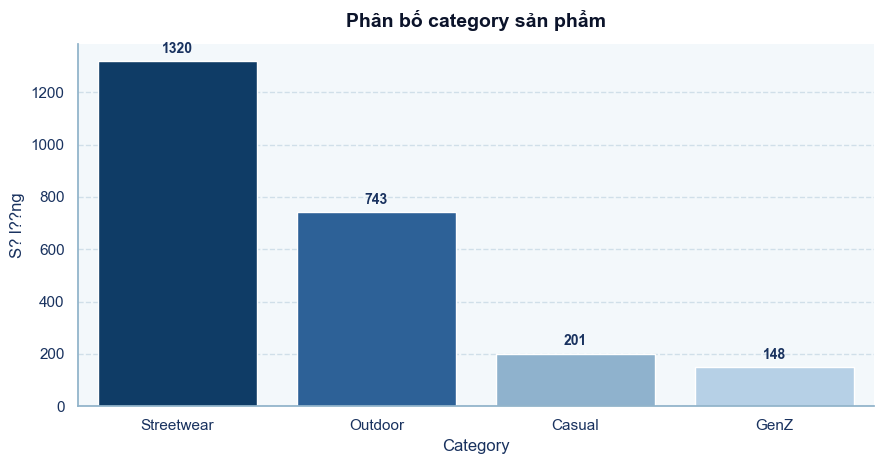

In [342]:
plot_count_chart(
    products,
    "category",
    "Phân bố category sản phẩm",
    "Category",
    color_key="info_blue",
)


#### Segment sản phẩm phân bố như thế nào?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


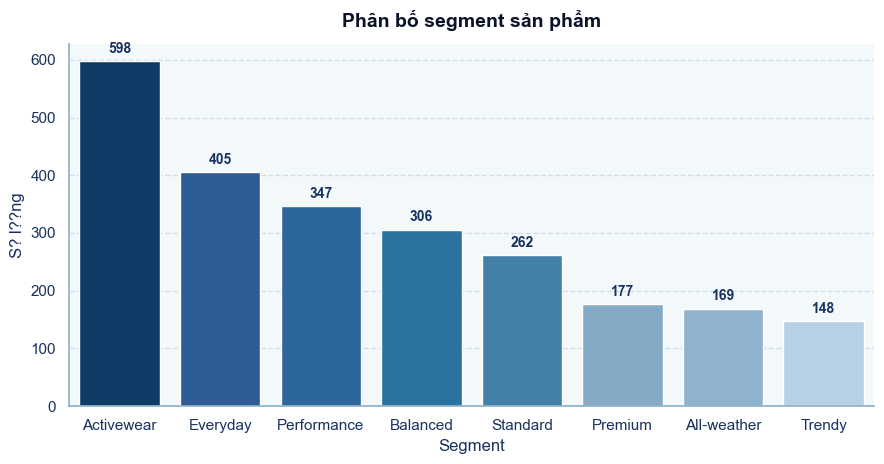

In [343]:
plot_count_chart(
    products,
    "segment",
    "Phân bố segment sản phẩm",
    "Segment",
    color_key="info_blue",
)


#### Khách hàng đến từ những thành phố nào?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


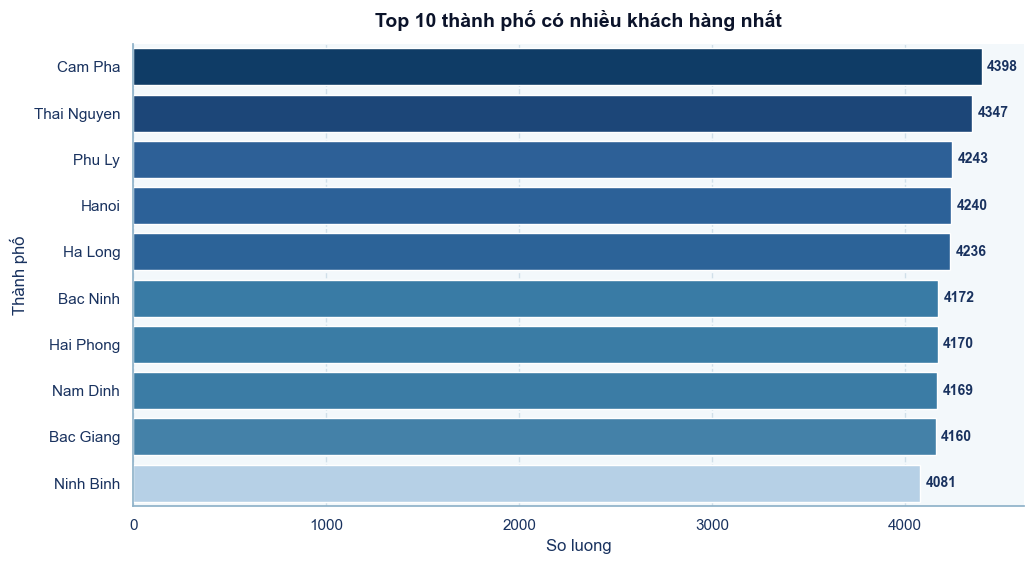

In [344]:
plot_count_chart(
    customers,
    "city",
    "Top 10 thành phố có nhiều khách hàng nhất",
    "Thành phố",
    top_n=10,
    color_key="info_blue",
    horizontal=True,
    figsize=(10.5, 5.8),
)


#### Giới tính của khách hàng phân bố ra sao?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


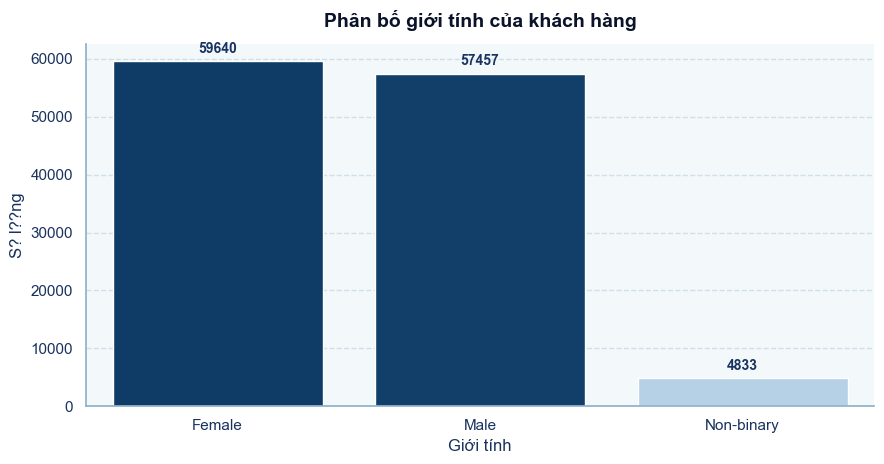

In [345]:
plot_count_chart(
    customers,
    "gender",
    "Phân bố giới tính của khách hàng",
    "Giới tính",
    color_key="warning",
)


#### Nhóm tuổi nào phổ biến hơn?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


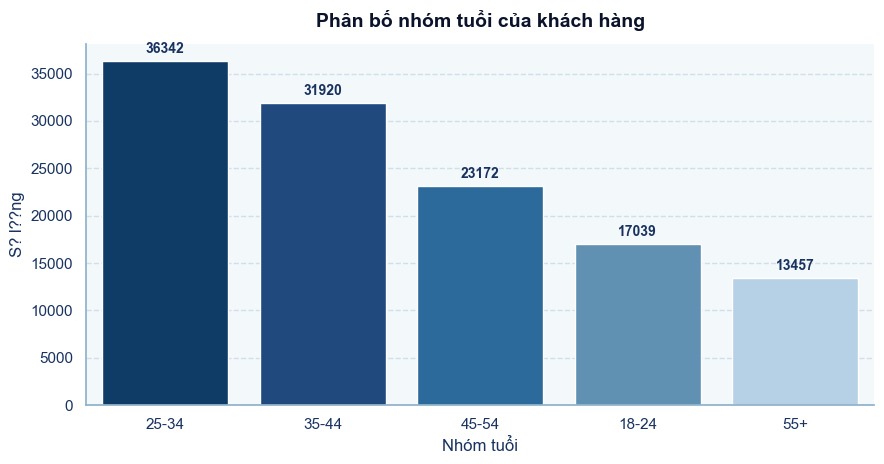

In [346]:
plot_count_chart(
    customers,
    "age_group",
    "Phân bố nhóm tuổi của khách hàng",
    "Nhóm tuổi",
    color_key="base_bar",
)


#### Trạng thái đơn hàng nào xuất hiện nhiều?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


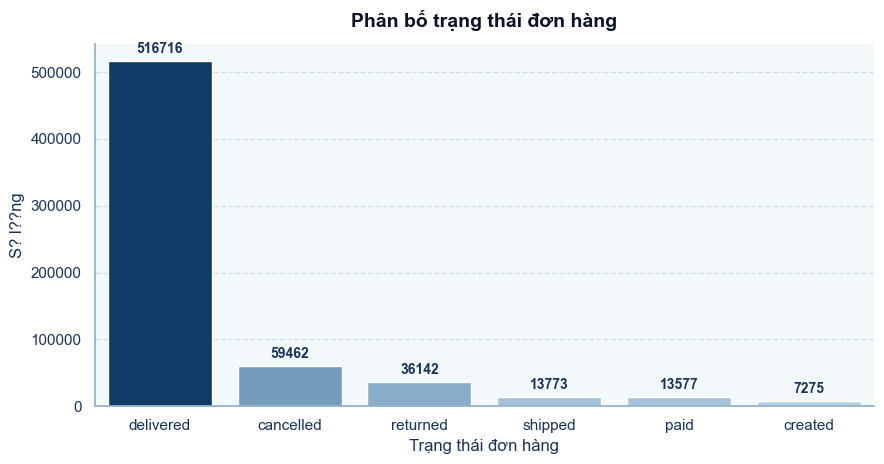

In [347]:
plot_count_chart(
    orders,
    "order_status",
    "Phân bố trạng thái đơn hàng",
    "Trạng thái đơn hàng",
    color_key="risk_red",
)


#### Phương thức thanh toán nào được ghi nhận?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


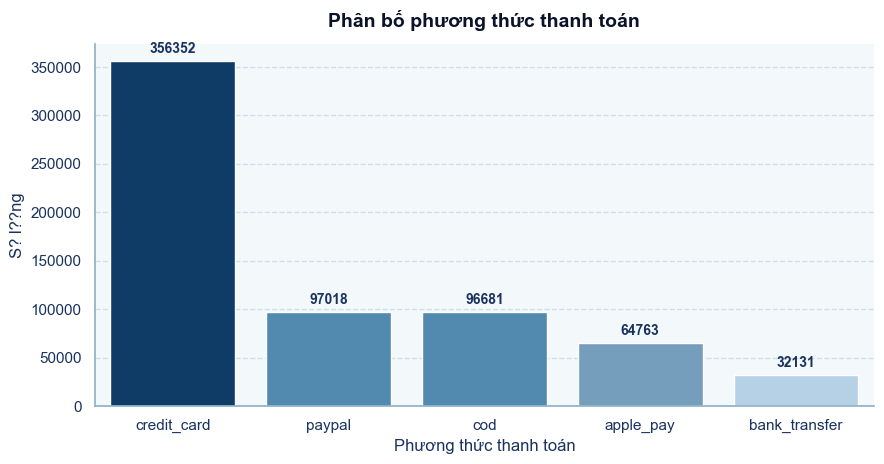

In [348]:
plot_count_chart(
    orders,
    "payment_method",
    "Phân bố phương thức thanh toán",
    "Phương thức thanh toán",
    color_key="lime_green",
)


#### Nguồn đơn hàng đến từ đâu?


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


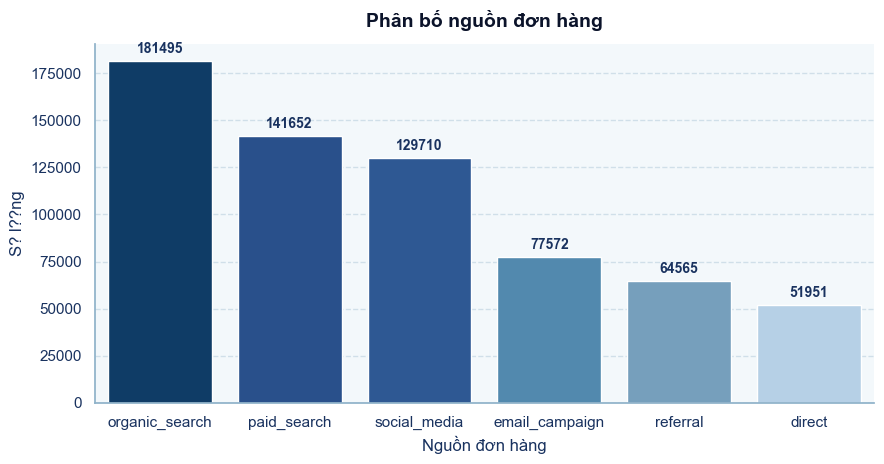

In [349]:
plot_count_chart(
    orders,
    "order_source",
    "Phân bố nguồn đơn hàng",
    "Nguồn đơn hàng",
    color_key="dark_gray",
)


#### Promotion mix nhìn nhanh ra sao?


,business_meaning,null_count,null_rate
applicable_category,Null = áp dụng tất cả,40,0.8
promo_channel,Không có null,0,0.0


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


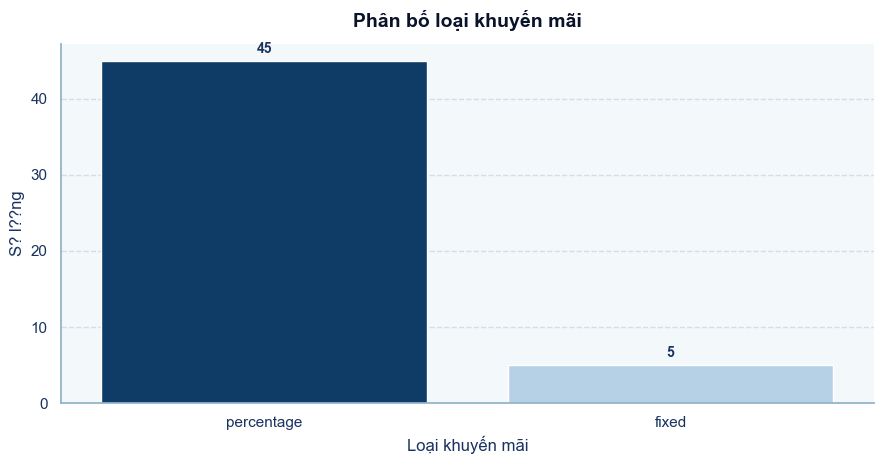

C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


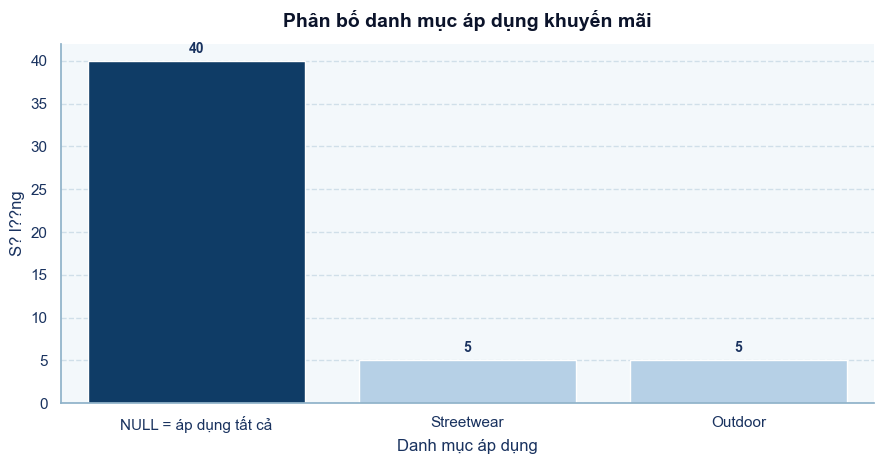

C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1274119107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


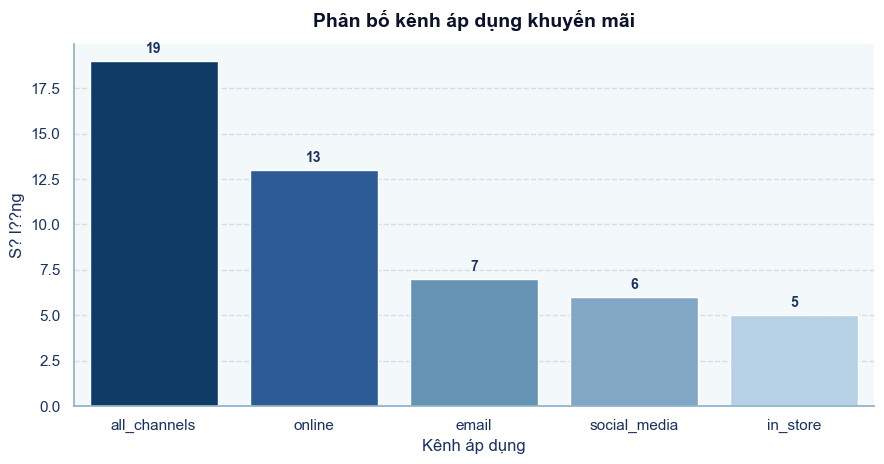

In [350]:
promotion_null_check = pd.DataFrame({
    "business_meaning": ["Null = áp dụng tất cả", "Không có null"],
    "null_count": promotions[["applicable_category", "promo_channel"]].isna().sum().values,
    "null_rate": promotions[["applicable_category", "promo_channel"]].isna().mean().values,
}, index=["applicable_category", "promo_channel"])
display(promotion_null_check)

promotions_glance = promotions.assign(
    applicable_category_display=promotions["applicable_category"].where(
        promotions["applicable_category"].notna(),
        "NULL = áp dụng tất cả"
    )
)

plot_count_chart(
    promotions_glance,
    "promo_type",
    "Phân bố loại khuyến mãi",
    "Loại khuyến mãi",
    color_key="warning",
)

plot_count_chart(
    promotions_glance,
    "applicable_category_display",
    "Phân bố danh mục áp dụng khuyến mãi",
    "Danh mục áp dụng",
    color_key="info_blue",
)

plot_count_chart(
    promotions,
    "promo_channel",
    "Phân bố kênh áp dụng khuyến mãi",
    "Kênh áp dụng",
    color_key="base_bar",
)


### Nhận xét nhanh về dữ liệu

- **Sản phẩm** nghiêng mạnh về Streetwear có thể là mặt hàng chủ lực của doanh nghiệp. 
- **Khách hàng** phân tán rộng theo thành phố, không có "thị trường trọng điểm", nhưng cũng đồng nghĩa tăng trưởng không bị kẹt tại một chỗ cố định.
- **Order status, payment method, order source** đều đa dạng, cần tách rõ đơn hoàn tất, và hành vi thanh toán từ sớm để tránh làm lệch KPI.
- **Bảng promotions** có null mang ý nghĩa nghiệp vụ (null = áp dụng cho tất cả).

## Data Validation

1. **Scope đơn hàng:** Do order_status có nhiều trạng thái, vậy trạng thái nào đủ tin cậy để đưa vào phân tích doanh thu chính.
2. **Inventory:** Bảng snapshot tháng có đủ nhất quán để hỗ trợ phân tích vận hành và mùa vụ không?
3. **Promotions:** Logic discount attribution có đủ đáng tin để phục vụ phân tích biên và hành vi khách hàng ở các lớp tiếp theo không?

### 1. Kiểm tra scope đơn hàng cho phân tích doanh thu chính

- Trong dữ liệu e-commerce, order_status không phải lúc nào cũng phản ánh đầy đủ vòng đời thực tế của đơn hàng.

Nguyên tắc kiểm tra:

- Payment record cho thấy đơn đã đi qua bước thanh toán.
- Shipment record, ship_date, delivery_date cho thấy đơn đã đi vào hoặc hoàn tất fulfillment.
- Return record cho thấy đơn đã phát sinh hậu bán hàng sau khi vòng đời bán hàng xảy ra.


In [351]:
shipment_status = ["shipped", "delivered", "returned"]

orders_check = orders.copy()
shipments_check = shipments.copy()
returns_check = returns.copy()
payments_check = payments.copy()
order_items_check = order_items.copy()

# Shipment evidence at order level
shipment_order_level = (
    shipments_check.groupby("order_id", as_index=False)
    .agg(
        ship_date=("ship_date", "min"),
        delivery_date=("delivery_date", "max"),
        shipping_fee_total=("shipping_fee", "sum"),
    )
)

shipment_order_level["has_shipment_record"] = True
shipment_order_level["has_ship_date"] = shipment_order_level["ship_date"].notna()
shipment_order_level["has_delivery_date"] = shipment_order_level["delivery_date"].notna()

# Return evidence at order level
returns_order_level = (
    returns_check.groupby("order_id", as_index=False)
    .agg(
        return_record_count=("return_id", "nunique"),
        refund_amount_total=("refund_amount", "sum"),
        return_quantity_total=("return_quantity", "sum"),
        return_reason_sample=(
            "return_reason",
            lambda s: ", ".join(sorted(s.dropna().astype(str).unique())[:3])
        ),
    )
)

returns_order_level["has_return_record"] = True
returns_order_level["has_refund_amount"] = returns_order_level["refund_amount_total"].fillna(0).gt(0)

# Payment evidence at order level
payment_order_level = (
    payments_check.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        installments=("installments", "max"),
        payment_method=("payment_method", "first"),
    )
)

payment_order_level["has_payment_record"] = True
payment_order_level["has_positive_payment_value"] = payment_order_level["payment_value"].fillna(0).gt(0)

# Order value at order level
order_value_level = (
    order_items_check.assign(
        gross_order_value=lambda df: df["quantity"] * df["unit_price"],
        net_order_value=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"],
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_order_value=("gross_order_value", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_order_value=("net_order_value", "sum"),
    )
)

# Combine all evidence
order_evidence = (
    orders_check[
        [
            "order_id",
            "order_date",
            "customer_id",
            "order_status",
            "payment_method",
            "order_source",
            "zip",
        ]
    ]
    .merge(order_value_level, on="order_id", how="left")
    .merge(
        payment_order_level[
            [
                "order_id",
                "payment_value",
                "has_payment_record",
                "has_positive_payment_value",
            ]
        ],
        on="order_id",
        how="left",
    )
    .merge(
        shipment_order_level[
            [
                "order_id",
                "ship_date",
                "delivery_date",
                "has_shipment_record",
                "has_ship_date",
                "has_delivery_date",
            ]
        ],
        on="order_id",
        how="left",
    )
    .merge(
        returns_order_level[
            [
                "order_id",
                "return_record_count",
                "refund_amount_total",
                "return_quantity_total",
                "return_reason_sample",
                "has_return_record",
                "has_refund_amount",
            ]
        ],
        on="order_id",
        how="left",
    )
)

# Fill numeric columns
for col in [
    "gross_order_value",
    "discount_amount",
    "net_order_value",
    "payment_value",
    "refund_amount_total",
    "return_quantity_total",
]:
    order_evidence[col] = order_evidence[col].fillna(0)

# Fill boolean columns
for col in [
    "has_payment_record",
    "has_positive_payment_value",
    "has_shipment_record",
    "has_ship_date",
    "has_delivery_date",
    "has_return_record",
    "has_refund_amount",
]:
    order_evidence[col] = order_evidence[col].fillna(False)

order_evidence["return_record_count"] = order_evidence["return_record_count"].fillna(0).astype(int)

In [352]:
order_status_evidence_summary = (
    order_evidence
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_net_order_value=("net_order_value", "sum"),
        orders_with_payment_record=("has_payment_record", "sum"),
        orders_with_positive_payment=("has_positive_payment_value", "sum"),
        orders_with_shipment_record=("has_shipment_record", "sum"),
        orders_with_ship_date=("has_ship_date", "sum"),
        orders_with_delivery_date=("has_delivery_date", "sum"),
        orders_with_return_record=("has_return_record", "sum"),
    )
)

for col in [
    "orders_with_payment_record",
    "orders_with_positive_payment",
    "orders_with_shipment_record",
    "orders_with_ship_date",
    "orders_with_delivery_date",
    "orders_with_return_record",
]:
    rate_col = col.replace("orders_with_", "") + "_rate"
    order_status_evidence_summary[rate_col] = (
        order_status_evidence_summary[col]
        / order_status_evidence_summary["total_orders"].replace(0, np.nan)
    )

display(
    order_status_evidence_summary.assign(
        total_orders=lambda df: df["total_orders"].map(format_number),
        total_net_order_value=lambda df: df["total_net_order_value"].map(format_currency),
        payment_record_rate=lambda df: df["payment_record_rate"].map(format_pct),
        positive_payment_rate=lambda df: df["positive_payment_rate"].map(format_pct),
        shipment_record_rate=lambda df: df["shipment_record_rate"].map(format_pct),
        ship_date_rate=lambda df: df["ship_date_rate"].map(format_pct),
        delivery_date_rate=lambda df: df["delivery_date_rate"].map(format_pct),
        return_record_rate=lambda df: df["return_record_rate"].map(format_pct),
    )
)

,order_status,total_orders,total_net_order_value,orders_with_payment_record,orders_with_positive_payment,orders_with_shipment_record,orders_with_ship_date,orders_with_delivery_date,orders_with_return_record,payment_record_rate,positive_payment_rate,shipment_record_rate,ship_date_rate,delivery_date_rate,return_record_rate
0,cancelled,"59,462","1,447,013,637",59462,59462,0,0,0,0,100.00%,100.00%,0.00%,0.00%,0.00%,0.00%
1,created,"7,275","181,835,019",7275,7275,0,0,0,0,100.00%,100.00%,0.00%,0.00%,0.00%,0.00%
2,delivered,"516,716","12,518,175,957",516716,516716,516192,516192,516192,0,100.00%,100.00%,99.90%,99.90%,99.90%,0.00%
3,paid,"13,577","330,627,096",13577,13577,0,0,0,0,100.00%,100.00%,0.00%,0.00%,0.00%,0.00%
4,returned,"36,142","865,938,716",36142,36142,36113,36113,36113,36062,100.00%,100.00%,99.92%,99.92%,99.92%,99.78%
5,shipped,"13,773","337,278,840",13773,13773,13762,13762,13762,0,100.00%,100.00%,99.92%,99.92%,99.92%,0.00%


**Nhận xét chính**

- Kết quả cho thấy các trạng thái không nên được đọc theo cùng một nghĩa:

    - delivered và returned có bằng chứng fulfillment rất mạnh vì gần như toàn bộ đơn đều có shipment record và delivery evidence.
    - shipped tuy chưa được cập nhật thành delivered trong bảng orders, nhưng phần lớn đã có delivery_date trong bảng shipments. Đây là dấu hiệu rõ của status lag từ hệ thống đơn hàng so với hệ thống logistics.
    - created, paid và cancelled có payment evidence nhưng không có shipment hoặc delivery evidence. Vì vậy, các nhóm này không đủ cơ sở để đưa vào để tính revenue chính.
    - Riêng cancelled, payment record chỉ cho thấy đơn đã từng đi qua bước thanh toán, nhưng chưa đủ để kết luận khách đã được hoàn tiền hay chưa vì trường refund trong bộ dữ liệu hiện tại chỉ xuất hiện ở returns.csv.


In [353]:
cancelled_orders_audit = order_evidence.loc[
    order_evidence["order_status"].eq("cancelled")
].copy()

cancelled_refund_summary = pd.DataFrame(
    {
        "Chỉ số": [
            "Số đơn cancelled",
            "Tổng payment_value của nhóm cancelled",
            "Số đơn cancelled xuất hiện trong returns.csv",
        ],
        "Giá trị": [
            format_number(cancelled_orders_audit["order_id"].nunique()),
            format_currency(cancelled_orders_audit["payment_value"].sum()),
            format_number(cancelled_orders_audit["has_return_record"].sum()),
        ],
    }
)

display(cancelled_refund_summary)


,Chỉ số,Giá trị
0,Số đơn cancelled,"59,462"
1,Tổng payment_value của nhóm cancelled,"1,447,013,637"
2,Số đơn cancelled xuất hiện trong returns.csv,0


**Kết luận về refund của nhóm cancelled**

- Trong 59,462 đơn cancelled, không có đơn nào xuất hiện trong returns.csv và không có refund_amount nào được ghi nhận trong dữ liệu đang dùng cho notebook này.
- Điều đó có nghĩa là trong extract hiện tại, không có bằng chứng quan sát được cho thấy cancelled đã được refund.
- Tuy nhiên, đây chưa phải bằng chứng để kết luận doanh nghiệp không hoàn tiền cho cancelled, vì refund do hủy đơn có thể được ghi nhận ở hệ thống khác và không đi qua returns.csv.
- Vì vậy, cancelled = đơn đã đi qua bước thanh toán nhưng trạng thái hoàn tiền chưa quan sát được trong bộ dữ liệu hiện có; nhóm này nên được giữ như lost demand và loại khỏi revenue chính.


**Kết luận về order scope**

Kết quả kiểm tra cho thấy `payment record` không đủ để xác định đơn nào nên được tính vào doanh thu chính, vì tất cả trạng thái đều có payment record. Do đó, notebook không dùng payment làm tiêu chí chính, mà dựa vào fulfillment evidence và mục tiêu phân tích.

Vì phân tích tài chính và phân tích hành vi khách hàng có mục tiêu khác nhau, notebook sử dụng hai scope riêng:

**1. Financial scope**

Dùng cho các phân tích revenue, refund, COGS, gross profit và gross margin.

Scope này gồm:

- `delivered`: đơn đã giao thành công.
- `returned`: đơn đã đi qua vòng đời bán hàng nhưng phát sinh hoàn trả, nên cần được đưa vào để đo refund và chất lượng doanh thu.
- `shipped` có `delivery_date`: đơn vẫn ghi là shipped trong `orders`, nhưng logistics đã ghi nhận ngày giao hàng, nên được xem là status lag.

**2. Customer behavior scope**

Dùng cho RFM, cohort, repeat purchase, retention, customer value và promotion effectiveness.

Scope này gồm:

- `delivered`
- `shipped` có `delivery_date`

Nhóm `returned` không được đưa vào customer behavior scope chính vì đây là hành vi mua đã phát sinh vấn đề hậu mua hàng, có thể làm lệch monetary value và repeat purchase nếu mục tiêu là đo hành vi mua thành công.

Các nhóm `created`, `paid` và `cancelled` bị loại khỏi cả hai scope chính vì có payment nhưng chưa có shipment/delivery evidence. Riêng `cancelled` được giữ để phân tích lost demand, còn `paid` và `created` được giữ để phân tích pending demand hoặc pipeline leakage.

In [354]:
valid_order_ids = order_evidence.loc[
    order_evidence["order_status"].eq("delivered")
    | (
        order_evidence["order_status"].eq("shipped")
        & order_evidence["has_delivery_date"]
    ),
    "order_id"
].unique()

valid_orders = orders.loc[
    orders["order_id"].isin(valid_order_ids)
].copy()

valid_order_items = order_items.loc[
    order_items["order_id"].isin(valid_order_ids)
].copy()

print("Valid orders:", format_number(valid_orders["order_id"].nunique()))
print("Valid order items:", format_number(len(valid_order_items)))

Valid orders: 530,478
Valid order items: 585,969


In [355]:
valid_scope_summary = (
    order_evidence
    .assign(in_valid_scope=lambda df: df["order_id"].isin(valid_order_ids))
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        valid_orders=("in_valid_scope", "sum"),
        total_net_order_value=("net_order_value", "sum"),
        valid_net_order_value=(
            "net_order_value",
            lambda s: s[order_evidence.loc[s.index, "order_id"].isin(valid_order_ids)].sum()
        ),
    )
)

valid_scope_summary["valid_order_rate"] = (
    valid_scope_summary["valid_orders"]
    / valid_scope_summary["total_orders"]
)

valid_scope_summary["valid_value_rate"] = (
    valid_scope_summary["valid_net_order_value"]
    / valid_scope_summary["total_net_order_value"]
)

display(
    valid_scope_summary.assign(
        total_orders=lambda df: df["total_orders"].map(format_number),
        valid_orders=lambda df: df["valid_orders"].map(format_number),
        total_net_order_value=lambda df: df["total_net_order_value"].map(format_currency),
        valid_net_order_value=lambda df: df["valid_net_order_value"].map(format_currency),
        valid_order_rate=lambda df: df["valid_order_rate"].map(format_pct),
        valid_value_rate=lambda df: df["valid_value_rate"].map(format_pct),
    )
)

,order_status,total_orders,valid_orders,total_net_order_value,valid_net_order_value,valid_order_rate,valid_value_rate
0,cancelled,"59,462",0,"1,447,013,637",0,0.00%,0.00%
1,created,"7,275",0,"181,835,019",0,0.00%,0.00%
2,delivered,"516,716","516,716","12,518,175,957","12,518,175,957",100.00%,100.00%
3,paid,"13,577",0,"330,627,096",0,0.00%,0.00%
4,returned,"36,142",0,"865,938,716",0,0.00%,0.00%
5,shipped,"13,773","13,762","337,278,840","337,135,227",99.92%,99.96%


### 2. Kiểm tra chất lượng bảng inventory

`inventory.csv` là bảng snapshot tồn kho theo tháng, nên phần này không kiểm tra ở cấp từng đơn hàng mà kiểm tra tính nhất quán ở cấp `product_id - month`.

Mục tiêu là xác định bảng inventory có đủ tin cậy để dùng cho phân tích vận hành và mùa vụ hay không.

Ba nhóm kiểm tra chính:

1. **Grain check:** mỗi `product_id` trong mỗi tháng có đúng một dòng snapshot không.
2. **Range check:** các chỉ số như `stock_on_hand`, `units_received`, `units_sold`, `stockout_days`, `fill_rate`, `days_of_supply` có nằm trong khoảng hợp lý không.
3. **Balance check:** với các SKU có snapshot ở hai tháng liền kề, kiểm tra công thức:
   `stock_on_hand tháng này = stock_on_hand tháng trước + units_received - units_sold`.

Nếu ba nhóm kiểm tra này không phát hiện lỗi nghiêm trọng, bảng inventory có thể được dùng cho phân tích stockout, fill rate, days of supply và mùa vụ ở các phần sau.

In [356]:
inventory_check = inventory.copy()
inventory_check["snapshot_date"] = pd.to_datetime(inventory_check["snapshot_date"])
inventory_check["snapshot_month"] = inventory_check["snapshot_date"].dt.to_period("M")

duplicate_sku_month = (
    inventory_check
    .groupby(["product_id", "snapshot_month"])
    .size()
    .reset_index(name="row_count")
    .query("row_count > 1")
)

display(duplicate_sku_month.head())
print("Số SKU-tháng bị trùng:", len(duplicate_sku_month))

,product_id,snapshot_month,row_count


Số SKU-tháng bị trùng: 0


In [357]:
inventory_range_summary = pd.DataFrame({
    "check": [
        "stock_on_hand âm",
        "units_received âm",
        "units_sold âm",
        "stockout_days ngoài 0-31",
        "fill_rate ngoài 0-1",
        "days_of_supply âm",
    ],
    "issue_count": [
        inventory_check["stock_on_hand"].lt(0).sum(),
        inventory_check["units_received"].lt(0).sum(),
        inventory_check["units_sold"].lt(0).sum(),
        (~inventory_check["stockout_days"].between(0, 31)).sum(),
        (~inventory_check["fill_rate"].between(0, 1)).sum(),
        inventory_check["days_of_supply"].lt(0).sum(),
    ]
})

display(inventory_range_summary)

,check,issue_count
0,stock_on_hand âm,0
1,units_received âm,0
2,units_sold âm,0
3,stockout_days ngoài 0-31,0
4,fill_rate ngoài 0-1,0
5,days_of_supply âm,0


In [358]:
inventory_balance = inventory_check.sort_values(["product_id", "snapshot_date"]).copy()

inventory_balance["prev_snapshot_date"] = (
    inventory_balance.groupby("product_id")["snapshot_date"].shift(1)
)

inventory_balance["prev_stock_on_hand"] = (
    inventory_balance.groupby("product_id")["stock_on_hand"].shift(1)
)

inventory_balance["month_gap"] = (
    (inventory_balance["snapshot_date"].dt.year - inventory_balance["prev_snapshot_date"].dt.year) * 12
    + (inventory_balance["snapshot_date"].dt.month - inventory_balance["prev_snapshot_date"].dt.month)
)

inventory_balance["is_consecutive_month"] = inventory_balance["month_gap"].eq(1)

inventory_balance["expected_stock"] = (
    inventory_balance["prev_stock_on_hand"]
    + inventory_balance["units_received"]
    - inventory_balance["units_sold"]
)

inventory_balance["stock_gap"] = (
    inventory_balance["stock_on_hand"] - inventory_balance["expected_stock"]
)

balance_issue = inventory_balance[
    inventory_balance["is_consecutive_month"]
    & inventory_balance["stock_gap"].ne(0)
]

print("Số dòng có snapshot liền tháng:", inventory_balance["is_consecutive_month"].sum())
print("Số dòng lệch balance:", len(balance_issue))

display(balance_issue.head())

Số dòng có snapshot liền tháng: 51524
Số dòng lệch balance: 0


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,segment,year,month,snapshot_month,prev_snapshot_date,prev_stock_on_hand,month_gap,is_consecutive_month,expected_stock,stock_gap


**Nhận xét chính**

- Bảng `inventory` vượt qua cả ba lớp kiểm tra cốt lõi nên có thể xem là đủ sạch để dùng cho phân tích vận hành và mùa vụ ở các phần sau.



### 3. Kiểm tra chất lượng bảng Promotions 

In [359]:
promo_check = (
    order_items
    .merge(
        promotions[["promo_id", "promo_type", "discount_value"]],
        on="promo_id",
        how="left"
    )
)

promo_match_summary = pd.DataFrame({
    "metric": [
        "order_item_rows",
        "rows_with_promo_id",
        "rows_with_promo_id_but_missing_promo_master",
    ],
    "value": [
        len(promo_check),
        promo_check["promo_id"].notna().sum(),
        (promo_check["promo_id"].notna() & promo_check["promo_type"].isna()).sum(),
    ]
})

display(promo_match_summary)

,metric,value
0,order_item_rows,714669
1,rows_with_promo_id,276316
2,rows_with_promo_id_but_missing_promo_master,0


In [360]:
promo_check["gross_line_sales"] = (
    promo_check["quantity"] * promo_check["unit_price"]
)

promo_check["expected_discount_amount"] = np.select(
    [
        promo_check["promo_id"].isna(),
        promo_check["promo_type"].eq("percentage"),
        promo_check["promo_type"].eq("fixed"),
    ],
    [
        0,
        promo_check["gross_line_sales"] * promo_check["discount_value"] / 100,
        promo_check["quantity"] * promo_check["discount_value"],
    ],
    default=np.nan
)

promo_check["discount_gap"] = (
    promo_check["discount_amount"] - promo_check["expected_discount_amount"]
)

promo_check["discount_match"] = np.isclose(
    promo_check["discount_amount"].fillna(0),
    promo_check["expected_discount_amount"].fillna(0),
    atol=0.01
)

discount_check_summary = pd.DataFrame({
    "metric": [
        "discount_match_rows",
        "discount_mismatch_rows",
        "discount_mismatch_rate",
    ],
    "value": [
        promo_check["discount_match"].sum(),
        (~promo_check["discount_match"]).sum(),
        (~promo_check["discount_match"]).mean(),
    ]
})

display(discount_check_summary)

display(
    promo_check.loc[
        ~promo_check["discount_match"],
        [
            "order_id",
            "product_id",
            "promo_id",
            "quantity",
            "unit_price",
            "promo_type",
            "discount_value",
            "discount_amount",
            "expected_discount_amount",
            "discount_gap",
        ],
    ].head(10)
)

,metric,value
0,discount_match_rows,714463.000000
1,discount_mismatch_rows,206.000000
2,discount_mismatch_rate,0.000288


,order_id,product_id,promo_id,quantity,unit_price,promo_type,discount_value,discount_amount,expected_discount_amount,discount_gap
280515,320123,2331,PROMO-0013,5,6671.13,percentage,10.0,3385.57,3335.565,50.005
280517,320125,622,PROMO-0013,5,9089.66,percentage,10.0,4594.83,4544.830,50.000
280518,320126,565,PROMO-0013,3,9753.99,percentage,10.0,2976.20,2926.197,50.003
280521,320128,609,PROMO-0013,1,9392.64,percentage,10.0,989.26,939.264,49.996
280522,320129,2086,PROMO-0013,8,2724.77,percentage,10.0,2229.82,2179.816,50.004
280525,320133,2387,PROMO-0013,1,5593.58,percentage,10.0,609.36,559.358,50.002
280527,320136,2157,PROMO-0013,7,4931.19,percentage,10.0,3501.83,3451.833,49.997
280528,320137,854,PROMO-0013,2,7611.24,percentage,10.0,1572.25,1522.248,50.002
280529,320138,604,PROMO-0013,1,5601.34,percentage,10.0,610.13,560.134,49.996
280532,320141,409,PROMO-0013,6,10573.87,percentage,10.0,6394.32,6344.322,49.998


**Nhận xét chính**

- Bảng `promotions` đủ sạch để dùng cho phân tích discount ở mức tổng hợp.
- Kiểm tra công thức discount cho thấy `714,463 / 714,669` dòng khớp hoàn toàn; chỉ có `206` dòng lệch, tương đương khoảng `0.03%`.
- Các dòng lệch có pattern rất giống nhau, chủ yếu chênh gần `50`, nên nhiều khả năng là edge case nghiệp vụ hoặc quy tắc làm tròn, không phải lỗi mapping diện rộng.
- Vì vậy, dữ liệu khuyến mãi đủ tin cậy để dùng cho các phân tích biên lợi nhuận, discount dependency và hành vi khách hàng ở các phần sau.


# Tổng quan hướng phân tích

Trong bộ dữ liệu e-commerce này, mục tiêu không chỉ là trả lời những câu hỏi mô tả quen thuộc như “tháng nào doanh thu cao nhất”, “sản phẩm nào bán chạy nhất” hay “khu vực nào có nhiều đơn hàng nhất”. Những câu hỏi đó cần thiết, nhưng chưa đủ để giúp doanh nghiệp ra quyết định.

Hướng phân tích của notebook này đặt khách hàng vào trung tâm, nhưng không nhìn khách hàng chỉ qua doanh thu. Một khách hàng mua nhiều chưa chắc đã tạo giá trị nếu họ chỉ mua khi có khuyến mãi sâu, thường xuyên hoàn trả, hoặc tạo biên lợi nhuận thấp. Ngược lại, một nhóm khách hàng có doanh thu vừa phải nhưng quay lại đều, ít phụ thuộc discount và có biên lợi nhuận tốt có thể là tệp đáng giữ chân hơn.

Vì vậy, notebook tập trung trả lời các câu hỏi có giá trị thực tế hơn cho doanh nghiệp:

- Ai đang thật sự tạo ra giá trị cho doanh nghiệp?
- Nhóm khách hàng nào nhìn có vẻ tốt về doanh thu nhưng thực chất đang làm mỏng biên lợi nhuận?
- Khách hàng quay lại vì họ có nhu cầu thật, hay chủ yếu vì khuyến mãi?
- Doanh nghiệp đang mất cơ hội ở đâu trong chính tệp khách hàng hiện có?
- Nhóm nào nên được giữ chân, nhóm nào nên được kéo lại, và nhóm nào cần được quản lý chi phí phục vụ tốt hơn?

Trước khi đi vào phân tích khách hàng, notebook xây dựng một lớp nền về chất lượng dữ liệu và chất lượng doanh thu. Điều này giúp tránh việc đưa các đơn chưa hoàn tất, bị hủy, hoặc chưa đủ bằng chứng fulfillment vào doanh thu chính. Từ đó, các phân tích về RFM, cohort, customer profitability, discount dependency và promotion effectiveness được đặt trên một baseline nhất quán hơn.

## Cấu trúc phân tích

Notebook được chia thành bốn lớp. Mỗi lớp trả lời một câu hỏi khác nhau, nhưng liên kết với nhau để đi từ bức tranh kinh doanh tổng thể đến đề xuất hành động cụ thể.

| Lớp | Nội dung | Câu hỏi chính | Mục tiêu |
|---|---|---|---|
| **Lớp 1** | Chất lượng doanh thu & áp lực lợi nhuận | Doanh nghiệp đang giữ lại được bao nhiêu giá trị sau discount, COGS và return? | Xác định vấn đề kinh doanh nền: tăng trưởng có thật sự chất lượng hay không |
| **Lớp 2** | Phân khúc & hành vi khách hàng | Ai đang tạo giá trị, ai đang rời bỏ, ai đang phụ thuộc khuyến mãi hoặc tạo áp lực return? | Xác định nhóm khách hàng cần ưu tiên giữ chân, kéo lại hoặc quản lý rủi ro |
| **Lớp 3** | Chiến lược marketing theo phân khúc | Nên làm gì với từng nhóm khách hàng? | Chuyển insight thành hành động: loyalty, win-back, cross-sell, kiểm soát discount, giảm return |
| **Lớp 4** | Đo tác động kinh doanh dự kiến | Nếu triển khai đúng, doanh nghiệp có thể cải thiện gì? | Ước lượng tác động lên gross profit, retention, AOV, repeat purchase và return rate |

### Lớp 1 — Bức tranh kinh doanh hiện tại

- Trước khi nói đến khách hàng, cần hiểu doanh nghiệp đang thực sự giữ lại được bao nhiêu từ mỗi đồng doanh thu tạo ra và phần bị mất đi đang đến từ đâu: chiết khấu, giá vốn, hoàn tiền hay cơ cấu thanh toán nhiều kỳ.

- Mỗi vấn đề tìm được ở đây sẽ dẫn thẳng vào câu hỏi quan trọng hơn ở Lớp 2: nhóm khách hàng nào đang đứng sau những con số đó?



### Đối chiếu nhẹ với sales.csv

`sales.csv` là bảng doanh thu đã được tổng hợp theo ngày và chủ yếu phục vụ bài toán forecasting. Vì bảng này không có `order_id`, không thể truy ngược về từng đơn hàng, nên không được dùng để quyết định order scope hay thay thế transaction-level revenue dựng từ `orders` và `order_items`.

Trong notebook này, `sales.csv` chỉ được dùng như một sanity check ở cấp ngày nhằm kiểm tra xem doanh thu dựng từ transaction data có cùng coverage và xu hướng tổng thể với bảng forecast hay không.

Cần lưu ý rằng hai nguồn có thể không khớp tuyệt đối vì khác logic ghi nhận doanh thu, khác treatment với refund/return, hoặc khác scope order status.

In [361]:
layer1_financial_order_ids = order_evidence.loc[
    order_evidence["order_status"].isin(["delivered", "returned"])
    | (
        order_evidence["order_status"].eq("shipped")
        & order_evidence["has_delivery_date"]
    ),
    "order_id"
].unique()

layer1_financial_order_items = order_items.loc[
    order_items["order_id"].isin(layer1_financial_order_ids)
].copy()

sales_check = sales.copy()

if "Date" in sales_check.columns:
    sales_check = sales_check.rename(columns={"Date": "date"})
elif "sales_date" in sales_check.columns:
    sales_check = sales_check.rename(columns={"sales_date": "date"})

sales_check["date"] = pd.to_datetime(sales_check["date"])

transaction_daily_revenue = (
    layer1_financial_order_items
    .merge(
        orders[["order_id", "order_date"]],
        on="order_id",
        how="left"
    )
    .assign(
        order_date=lambda df: pd.to_datetime(df["order_date"]),
        date=lambda df: df["order_date"].dt.date,
        gross_sales=lambda df: df["quantity"] * df["unit_price"],
        net_sales_before_refund=lambda df: df["gross_sales"] - df["discount_amount"],
    )
    .groupby("date", as_index=False)
    .agg(
        transaction_gross_sales=("gross_sales", "sum"),
        transaction_net_sales_before_refund=("net_sales_before_refund", "sum"),
        transaction_orders=("order_id", "nunique"),
    )
)

transaction_daily_revenue["date"] = pd.to_datetime(transaction_daily_revenue["date"])

sales_revenue_col = "Revenue"

daily_revenue_compare = (
    sales_check[["date", sales_revenue_col]]
    .merge(transaction_daily_revenue, on="date", how="outer")
    .sort_values("date")
)

daily_revenue_compare["revenue_gap"] = (
    daily_revenue_compare["transaction_net_sales_before_refund"]
    - daily_revenue_compare[sales_revenue_col]
)

daily_revenue_compare["revenue_gap_pct"] = (
    daily_revenue_compare["revenue_gap"]
    / daily_revenue_compare[sales_revenue_col].replace(0, np.nan)
)

display(daily_revenue_compare.head())
display(daily_revenue_compare.tail())


,date,Revenue,transaction_gross_sales,transaction_net_sales_before_refund,transaction_orders,revenue_gap,revenue_gap_pct
0,2012-07-04,5123547.94,4893597.50,4893597.50,147,-229950.44,-0.044881
1,2012-07-05,2751773.45,2483699.18,2483699.18,87,-268074.27,-0.097419
2,2012-07-06,3054029.42,2538264.32,2538264.32,79,-515765.10,-0.168880
3,2012-07-07,2667930.94,2159956.36,2159956.36,62,-507974.58,-0.190400
4,2012-07-08,2360851.90,2042755.04,2042755.04,78,-318096.86,-0.134738


,date,Revenue,transaction_gross_sales,transaction_net_sales_before_refund,transaction_orders,revenue_gap,revenue_gap_pct
3828,2022-12-27,2100553.66,1809190.13,1447352.10,92,-653201.56,-0.310966
3829,2022-12-28,3448729.20,2982649.21,2386119.33,129,-1062609.87,-0.308116
3830,2022-12-29,3083944.33,2405885.90,1924708.78,118,-1159235.55,-0.375894
3831,2022-12-30,2884668.76,2497111.42,2008983.30,93,-875685.46,-0.303565
3832,2022-12-31,2383037.48,2151908.25,1815084.41,68,-567953.07,-0.238332


In [362]:
revenue_compare_summary = pd.DataFrame({
    "metric": [
        "sales_date_min",
        "sales_date_max",
        "transaction_date_min",
        "transaction_date_max",
        "sales_total_revenue",
        "transaction_total_net_sales_before_refund",
        "absolute_gap",
        "gap_pct_vs_sales",
        "daily_correlation",
    ],
    "value": [
        daily_revenue_compare.loc[daily_revenue_compare[sales_revenue_col].notna(), "date"].min(),
        daily_revenue_compare.loc[daily_revenue_compare[sales_revenue_col].notna(), "date"].max(),
        daily_revenue_compare.loc[daily_revenue_compare["transaction_net_sales_before_refund"].notna(), "date"].min(),
        daily_revenue_compare.loc[daily_revenue_compare["transaction_net_sales_before_refund"].notna(), "date"].max(),
        daily_revenue_compare[sales_revenue_col].sum(),
        daily_revenue_compare["transaction_net_sales_before_refund"].sum(),
        daily_revenue_compare["revenue_gap"].sum(),
        daily_revenue_compare["revenue_gap"].sum() / daily_revenue_compare[sales_revenue_col].sum(),
        daily_revenue_compare[[sales_revenue_col, "transaction_net_sales_before_refund"]].corr().iloc[0, 1],
    ],
})

display(revenue_compare_summary)

,metric,value
0,sales_date_min,2012-07-04 00:00:00
1,sales_date_max,2022-12-31 00:00:00
2,transaction_date_min,2012-07-04 00:00:00
3,transaction_date_max,2022-12-31 00:00:00
4,sales_total_revenue,16430476585.529999
5,transaction_total_net_sales_before_refund,13721249900.17
6,absolute_gap,-2709226685.36
7,gap_pct_vs_sales,-0.16489
8,daily_correlation,0.990161


**Nhận xét chính**

- Doanh thu dựng từ transaction data và `sales.csv` có cùng coverage thời gian và thường bám xu hướng khá sát nhau ở cấp ngày.
- Tuy nhiên, hai nguồn không nhất thiết khớp về mức tuyệt đối vì khác scope order status và khác cách đọc doanh thu trước hoặc sau refund.
- Vì vậy, `sales.csv` phù hợp để dùng như sanity check về coverage và shape của chuỗi thời gian.
- Còn các phân tích tài chính ở Lớp 1 vẫn nên dùng transaction-level revenue từ `orders`, `order_items`, `returns` và `payments`, vì notebook có thể kiểm soát được grain và logic tính toán.


In [363]:
financial_order_ids = order_evidence.loc[
    order_evidence["order_status"].isin(["delivered", "returned"])
    | (
        order_evidence["order_status"].eq("shipped")
        & order_evidence["has_delivery_date"]
    ),
    "order_id"
].unique()

customer_order_ids = order_evidence.loc[
    order_evidence["order_status"].eq("delivered")
    | (
        order_evidence["order_status"].eq("shipped")
        & order_evidence["has_delivery_date"]
    ),
    "order_id"
].unique()

financial_orders = orders.loc[orders["order_id"].isin(financial_order_ids)].copy()
customer_orders = orders.loc[orders["order_id"].isin(customer_order_ids)].copy()

financial_order_items = order_items.loc[
    order_items["order_id"].isin(financial_order_ids)
].copy()
customer_order_items = order_items.loc[
    order_items["order_id"].isin(customer_order_ids)
].copy()

scope_decision_summary = pd.DataFrame(
    {
        "scope": ["Financial scope", "Customer scope"],
        "included_status": [
            "delivered + returned + shipped with delivery_date",
            "delivered + shipped with delivery_date",
        ],
        "main_use": [
            "Revenue, refund, COGS, gross profit, gross margin",
            "RFM, cohort, repeat purchase, retention, customer value",
        ],
        "order_count": [
            financial_orders["order_id"].nunique(),
            customer_orders["order_id"].nunique(),
        ],
        "order_item_rows": [
            len(financial_order_items),
            len(customer_order_items),
        ],
    }
)

display(
    scope_decision_summary.assign(
        order_count=lambda df: df["order_count"].map(format_number),
        order_item_rows=lambda df: df["order_item_rows"].map(format_number),
    )
)


,scope,included_status,main_use,order_count,order_item_rows
0,Financial scope,delivered + returned + shipped with delivery_date,"Revenue, refund, COGS, gross profit, gross margin","566,620","626,003"
1,Customer scope,delivered + shipped with delivery_date,"RFM, cohort, repeat purchase, retention, custo...","530,478","585,969"


### Fact table

`financial_order_line_fact` là bảng nền của Lớp 1. Mỗi dòng tương ứng với **1 SKU trong 1 đơn hàng**, giúp notebook tính `gross sales`, `discount`, `refund`, `net revenue`, `COGS` và `gross profit` nhất quán trên cùng một grain.


In [364]:
product_cols = [
    "product_id",
    "product_name",
    "category",
    "segment",
    "size",
    "color",
    "price",
    "cogs",
]

refund_order_product = (
    returns.loc[returns["order_id"].isin(financial_order_ids)]
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        refund_amount=("refund_amount", "sum"),
        return_quantity=("return_quantity", "sum"),
        return_record_count=("return_id", "nunique"),
    )
)

financial_order_line_fact = (
    financial_orders[
        [
            "order_id",
            "order_date",
            "customer_id",
            "order_status",
            "payment_method",
            "order_source",
            "zip",
        ]
    ]
    .merge(financial_order_items, on="order_id", how="inner")
    .merge(products[product_cols], on="product_id", how="left")
    .rename(columns={"cogs": "product_unit_cogs"})
    .merge(refund_order_product, on=["order_id", "product_id"], how="left")
    .copy()
)

financial_order_line_fact["order_date"] = pd.to_datetime(financial_order_line_fact["order_date"])
financial_order_line_fact["gross_line_sales"] = (
    financial_order_line_fact["quantity"] * financial_order_line_fact["unit_price"]
)
financial_order_line_fact["line_revenue_before_refund"] = (
    financial_order_line_fact["gross_line_sales"] - financial_order_line_fact["discount_amount"]
)
financial_order_line_fact["line_cogs"] = (
    financial_order_line_fact["quantity"] * financial_order_line_fact["product_unit_cogs"]
)

for col in ["refund_amount", "return_quantity"]:
    financial_order_line_fact[col] = financial_order_line_fact[col].fillna(0)
financial_order_line_fact["return_record_count"] = (
    financial_order_line_fact["return_record_count"].fillna(0).astype(int)
)

revenue_pair_total = financial_order_line_fact.groupby(["order_id", "product_id"])[
    "line_revenue_before_refund"
].transform("sum")
quantity_pair_total = financial_order_line_fact.groupby(["order_id", "product_id"])[
    "quantity"
].transform("sum")

financial_order_line_fact["refund_allocation_share"] = np.where(
    revenue_pair_total.gt(0),
    financial_order_line_fact["line_revenue_before_refund"]
    / revenue_pair_total.replace(0, np.nan),
    financial_order_line_fact["quantity"]
    / quantity_pair_total.replace(0, np.nan),
)
financial_order_line_fact["refund_allocation_share"] = (
    financial_order_line_fact["refund_allocation_share"].fillna(0)
)
financial_order_line_fact["allocated_refund_amount"] = (
    financial_order_line_fact["refund_amount"]
    * financial_order_line_fact["refund_allocation_share"]
)
financial_order_line_fact["line_revenue"] = (
    financial_order_line_fact["line_revenue_before_refund"]
    - financial_order_line_fact["allocated_refund_amount"]
)
financial_order_line_fact["line_gross_profit"] = (
    financial_order_line_fact["line_revenue"] - financial_order_line_fact["line_cogs"]
)
financial_order_line_fact["discount_rate"] = (
    financial_order_line_fact["discount_amount"]
    / financial_order_line_fact["gross_line_sales"].replace(0, np.nan)
)
financial_order_line_fact["line_gross_margin"] = (
    financial_order_line_fact["line_gross_profit"]
    / financial_order_line_fact["line_revenue"].replace(0, np.nan)
)
financial_order_line_fact["year"] = financial_order_line_fact["order_date"].dt.year
financial_order_line_fact["month"] = financial_order_line_fact["order_date"].dt.month
financial_order_line_fact["month_name"] = financial_order_line_fact["order_date"].dt.strftime("%b")
financial_order_line_fact["year_month"] = (
    financial_order_line_fact["order_date"].dt.to_period("M").dt.to_timestamp()
)

print("Financial order line rows:", format_number(len(financial_order_line_fact)))
print("Financial orders:", format_number(financial_order_line_fact["order_id"].nunique()))
print(
    "Returned orders in financial scope:",
    format_number(financial_orders.loc[financial_orders["order_status"].eq("returned"), "order_id"].nunique()),
)


Financial order line rows: 626,003
Financial orders: 566,620
Returned orders in financial scope: 36,142


### Aggregate tables

Từ `financial_order_line_fact`, notebook tổng hợp lên các bảng tháng, năm và cơ cấu thanh toán. Các bảng này là đầu vào trực tiếp cho KPI snapshot và chart của Lớp 1.


In [365]:
def aggregate_business(frame: pd.DataFrame, group_key: str) -> pd.DataFrame:
    return (
        frame.groupby(group_key, as_index=False)
        .agg(
            gross_sales=("gross_line_sales", "sum"),
            discount_amount=("discount_amount", "sum"),
            refund_amount=("allocated_refund_amount", "sum"),
            net_revenue_before_refund=("line_revenue_before_refund", "sum"),
            net_revenue=("line_revenue", "sum"),
            cogs=("line_cogs", "sum"),
            gross_profit=("line_gross_profit", "sum"),
            order_count=("order_id", pd.Series.nunique),
            customer_count=("customer_id", pd.Series.nunique),
            total_quantity=("quantity", "sum"),
        )
    )


def add_business_ratios(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["gross_margin"] = df["gross_profit"] / df["net_revenue"].replace(0, np.nan)
    df["discount_rate"] = df["discount_amount"] / df["gross_sales"].replace(0, np.nan)
    df["aov"] = df["net_revenue"] / df["order_count"].replace(0, np.nan)
    df["units_per_order"] = df["total_quantity"] / df["order_count"].replace(0, np.nan)
    return df

monthly_business = aggregate_business(financial_order_line_fact, "year_month")
monthly_business = add_business_ratios(monthly_business)
monthly_business = monthly_business.sort_values("year_month").reset_index(drop=True)
monthly_business["year"] = monthly_business["year_month"].dt.year
monthly_business["month"] = monthly_business["year_month"].dt.month
monthly_business["month_name"] = monthly_business["year_month"].dt.strftime("%b")
monthly_business["month_label"] = "T" + monthly_business["month"].astype(str)

yearly_business = aggregate_business(financial_order_line_fact, "year")
yearly_business = add_business_ratios(yearly_business)
yearly_business = yearly_business.sort_values("year").reset_index(drop=True)

calendar_month_profile = (
    monthly_business.groupby(["month", "month_name"], as_index=False)
    .agg(
        avg_net_revenue=("net_revenue", "mean"),
        avg_gross_margin=("gross_margin", "mean"),
    )
    .sort_values("month")
)
calendar_month_profile["month_label"] = "T" + calendar_month_profile["month"].astype(str)

display(monthly_business.head())
display(yearly_business.head())


,year_month,gross_sales,discount_amount,refund_amount,net_revenue_before_refund,net_revenue,cogs,gross_profit,order_count,customer_count,total_quantity,gross_margin,discount_rate,aov,units_per_order,year,month,month_name,month_label
0,2012-07-01,1.147431e+08,0.0,4105279.15,1.147431e+08,1.106378e+08,9.013303e+07,2.050478e+07,4654,4334,23170,0.185332,0.0,23772.627699,4.978513,2012,7,Jul,T7
1,2012-08-01,1.388305e+08,0.0,4713719.02,1.388305e+08,1.341167e+08,1.095032e+08,2.461354e+07,5602,5124,28129,0.183523,0.0,23940.867230,5.021242,2012,8,Aug,T8
2,2012-09-01,1.128056e+08,0.0,4613057.22,1.128056e+08,1.081926e+08,8.957651e+07,1.861607e+07,4620,4281,23181,0.172064,0.0,23418.308805,5.017532,2012,9,Sep,T9
3,2012-10-01,9.648928e+07,0.0,3766147.77,9.648928e+07,9.272313e+07,7.706940e+07,1.565373e+07,3791,3468,19531,0.168822,0.0,24458.752414,5.151939,2012,10,Oct,T10
4,2012-11-01,8.465747e+07,0.0,3146739.39,8.465747e+07,8.151073e+07,6.714969e+07,1.436103e+07,3592,3276,18875,0.176186,0.0,22692.295952,5.254733,2012,11,Nov,T11


,year,gross_sales,discount_amount,refund_amount,net_revenue_before_refund,net_revenue,cogs,gross_profit,order_count,customer_count,total_quantity,gross_margin,discount_rate,aov,units_per_order
0,2012,6.481367e+08,0.00,23609396.67,6.481367e+08,6.245273e+08,5.134560e+08,1.110714e+08,28146,20061,145967,0.177849,0.000000,22188.849100,5.186066
1,2013,1.453666e+09,76435800.49,51996488.43,1.377231e+09,1.325234e+09,1.284476e+09,4.075795e+07,67390,36625,344148,0.030755,0.052581,19665.145371,5.106811
2,2014,1.644729e+09,76171684.57,58245013.52,1.568557e+09,1.510312e+09,1.383366e+09,1.269461e+08,70844,37585,360449,0.084053,0.046313,21318.847288,5.087926
3,2015,1.659341e+09,86012322.67,60567497.04,1.573328e+09,1.512761e+09,1.461587e+09,5.117408e+07,72456,37985,364627,0.033828,0.051835,20878.339687,5.032392
4,2016,1.853588e+09,81517898.74,66336938.53,1.772070e+09,1.705733e+09,1.568716e+09,1.370176e+08,72390,38177,360772,0.080328,0.043978,23563.104570,4.983727


In [366]:
financial_payment_order_level = payment_order_level.loc[
    payment_order_level["order_id"].isin(financial_order_ids)
].copy()
financial_payment_order_level["installments"] = (
    financial_payment_order_level["installments"].fillna(1).clip(lower=1).astype(int)
)

order_payment_eda = financial_orders.merge(
    financial_payment_order_level[["order_id", "payment_value", "installments", "payment_method"]],
    on="order_id",
    how="left",
    suffixes=("", "_payment"),
).copy()
order_payment_eda["payment_value"] = order_payment_eda["payment_value"].fillna(0)
order_payment_eda["installments"] = (
    order_payment_eda["installments"].fillna(1).clip(lower=1).astype(int)
)
order_payment_eda["is_multi_installment"] = order_payment_eda["installments"].gt(1)
order_payment_eda["estimated_first_period_collection"] = (
    order_payment_eda["payment_value"] / order_payment_eda["installments"]
)
order_payment_eda["estimated_deferred_exposure"] = (
    order_payment_eda["payment_value"]
    * (order_payment_eda["installments"] - 1)
    / order_payment_eda["installments"]
)

installment_mix = (
    order_payment_eda.groupby("installments", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        order_count=("order_id", pd.Series.nunique),
        estimated_first_period_collection=("estimated_first_period_collection", "sum"),
        estimated_deferred_exposure=("estimated_deferred_exposure", "sum"),
    )
    .sort_values("installments")
)
installment_mix["payment_value_share"] = (
    installment_mix["payment_value"] / installment_mix["payment_value"].sum()
)
installment_mix["deferred_exposure_ratio"] = (
    installment_mix["estimated_deferred_exposure"]
    / installment_mix["payment_value"].replace(0, np.nan)
)
installment_mix["installment_label"] = installment_mix["installments"].astype(str) + " kỳ"

total_refund_amount = financial_order_line_fact["allocated_refund_amount"].sum()
total_net_revenue_before_refund = financial_order_line_fact["line_revenue_before_refund"].sum()
total_net_revenue = financial_order_line_fact["line_revenue"].sum()
total_cogs = financial_order_line_fact["line_cogs"].sum()
total_gross_profit = financial_order_line_fact["line_gross_profit"].sum()
total_payment_value = order_payment_eda["payment_value"].sum()
multi_installment_payment_share = (
    order_payment_eda.loc[order_payment_eda["is_multi_installment"], "payment_value"].sum()
    / total_payment_value
    if total_payment_value else np.nan
)
overall_deferred_exposure_ratio = (
    order_payment_eda["estimated_deferred_exposure"].sum() / total_payment_value
    if total_payment_value else np.nan
)

analysis_start = financial_orders["order_date"].min()
analysis_end = financial_orders["order_date"].max()
analysis_years = yearly_business["year"].nunique()
analysis_order_count = financial_orders["order_id"].nunique()


### KPI snapshot

Đọc bức tranh tài chính tổng thể trước khi sang chart chi tiết.


In [367]:
financial_kpi_snapshot = pd.DataFrame(
    {
        "Chỉ số": [
            "Doanh thu thuần sau hoàn tiền (trăm triệu VND)",
            "Lợi nhuận gộp thực giữ lại (trăm triệu VND)",
            "Biên lợi nhuận gộp thực",
            "Tỷ lệ chiết khấu trên doanh thu gộp",
            "Tỷ lệ hoàn tiền trên doanh thu sau chiết khấu",
            "Tỷ trọng giá trị thanh toán trả góp nhiều kỳ",
        ],
        "Giá trị": [
            format_hundred_millions(total_net_revenue),
            format_hundred_millions(total_gross_profit),
            format_pct(total_gross_profit / total_net_revenue if total_net_revenue else np.nan),
            format_pct(
                financial_order_line_fact["discount_amount"].sum()
                / financial_order_line_fact["gross_line_sales"].sum()
            ),
            format_pct(
                total_refund_amount / total_net_revenue_before_refund
                if total_net_revenue_before_refund else np.nan
            ),
            format_pct(multi_installment_payment_share),
        ],
    }
)

print("Khoảng thời gian financial scope:", analysis_start.strftime("%Y-%m-%d"), "->", analysis_end.strftime("%Y-%m-%d"))
print("Số năm dữ liệu trong financial scope:", analysis_years)
print("Số đơn trong financial scope:", format_number(analysis_order_count))
print("Tỷ lệ estimated deferred exposure (proxy):", format_pct(overall_deferred_exposure_ratio))
display(financial_kpi_snapshot)


Khoảng thời gian financial scope: 2012-07-04 -> 2022-12-31
Số năm dữ liệu trong financial scope: 11
Số đơn trong financial scope: 566,620
Tỷ lệ estimated deferred exposure (proxy): 45.25%


,Chỉ số,Giá trị
0,Doanh thu thuần sau hoàn tiền (trăm triệu VND),132.1
1,Lợi nhuận gộp thực giữ lại (trăm triệu VND),8.2
2,Biên lợi nhuận gộp thực,6.20%
3,Tỷ lệ chiết khấu trên doanh thu gộp,4.57%
4,Tỷ lệ hoàn tiền trên doanh thu sau chiết khấu,3.72%
5,Tỷ trọng giá trị thanh toán trả góp nhiều kỳ,60.36%


**Insight nhanh từ financial scope**

- Financial scope ghi nhận **566,620 đơn** trong giai đoạn 2012-07-04 đến 2022-12-31. Sau hoàn tiền, doanh thu thuần còn lại đạt **132.1 trăm triệu VND**, nhưng lợi nhuận gộp chỉ còn **8.2 trăm triệu VND**, tương ứng biên lợi nhuận **6.20%**.

- Điểm đáng chú ý là doanh nghiệp không thiếu doanh thu, nhưng phần giá trị giữ lại sau discount, refund và COGS khá mỏng. Với biên lợi nhuận chỉ 6.20%, các yếu tố như chiết khấu **4.57%** và hoàn tiền **3.72%** cần được theo dõi kỹ vì có thể nhanh chóng bào mòn lợi nhuận.

- Ngoài ra, **60.36% giá trị thanh toán đến từ trả góp nhiều kỳ**, tạo ra deferred exposure khoảng **45.25%**. Điều này cho thấy trả góp có thể hỗ trợ doanh thu, nhưng cũng làm tăng áp lực theo dõi dòng tiền.

Các biểu đồ tiếp theo sẽ đi sâu vào việc doanh thu bị hao hụt ở đâu, biên lợi nhuận biến động thế nào và yếu tố nào đang kéo chất lượng lợi nhuận xuống.

### Biểu đồ xu hướng và mùa vụ


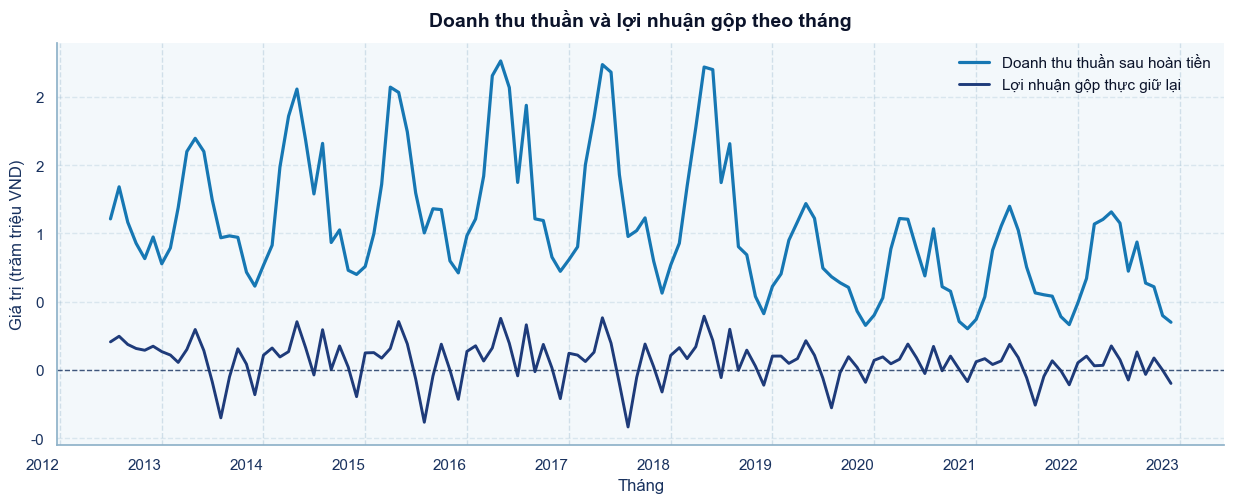

In [368]:
fig, ax = plt.subplots(figsize=(12.5, 5.2))

sns.lineplot(
    data=monthly_business,
    x="year_month",
    y="net_revenue",
    ax=ax,
    color=PALETTE["green"],
    linewidth=2.3,
    label="Doanh thu thuần sau hoàn tiền",
)
sns.lineplot(
    data=monthly_business,
    x="year_month",
    y="gross_profit",
    ax=ax,
    color=PALETTE["risk_red"],
    linewidth=2.1,
    label="Lợi nhuận gộp thực giữ lại",
)
ax.axhline(0, color=PALETTE["dark_gray"], linewidth=1, linestyle="--", alpha=0.8)
clean_axis(
    ax,
    xlabel="Tháng",
    ylabel="Giá trị (trăm triệu VND)",
    title="Doanh thu thuần và lợi nhuận gộp theo tháng",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Insight - doanh thu có mùa vụ, nhưng lợi nhuận giữ lại không ổn định**

- Biểu đồ cho thấy doanh nghiệp vẫn tạo được doanh thu đều qua các năm, nhưng lợi nhuận gộp thấp hơn rất nhiều và biến động mạnh hơn so với top-line. 
- Nói cách khác, vấn đề chính không nằm ở việc có bán được hàng hay không, mà nằm ở việc doanh nghiệp giữ lại được bao nhiêu sau discount, refund và COGS.

- Doanh thu cũng không đi theo một đường tăng trưởng tuyến tính, mà có các nhịp lên xuống rõ theo thời gian. 

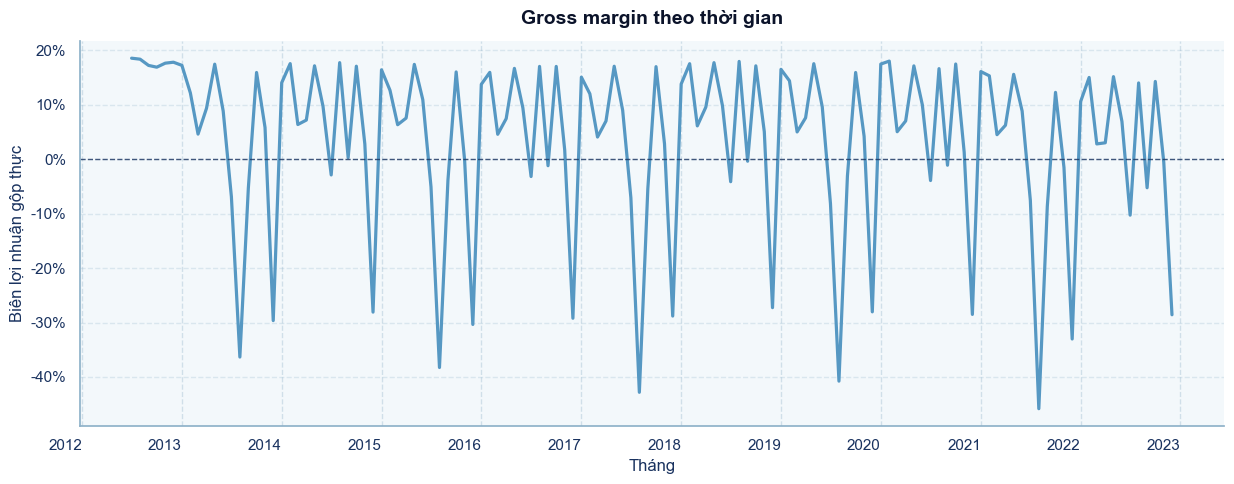

In [369]:
fig, ax = plt.subplots(figsize=(12.5, 5.0))

sns.lineplot(
    data=monthly_business,
    x="year_month",
    y="gross_margin",
    ax=ax,
    color=PALETTE["warning"],
    linewidth=2.3,
)
ax.axhline(0, color=PALETTE["dark_gray"], linewidth=1, linestyle="--", alpha=0.8)
clean_axis(
    ax,
    xlabel="Tháng",
    ylabel="Biên lợi nhuận gộp thực",
    title="Gross margin theo thời gian",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(ha="right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


**Insight - gross margin cho thấy rủi ro chất lượng doanh thu**

- Gross margin dao động rất mạnh và nhiều tháng rơi xuống âm. Điều này cho thấy doanh nghiệp có những giai đoạn vẫn tạo được doanh thu, nhưng doanh thu đó không đủ để bù COGS và các khoản hao hụt như discount hoặc refund.

- Vì vậy, nếu chỉ nhìn revenue trend, rất dễ bỏ sót những tháng bán được hàng nhưng chất lượng lợi nhuận yếu. Bước tiếp theo cần tách riêng các **negative-margin months** để xem margin âm đến từ category nào và có liên quan đến promo hay không.

### Deep-dive negative-margin months

Mục tiêu là xác định tháng nào có biên lợi nhuận âm và xem nhóm category nào đang kéo phần profit xuống mạnh nhất.


In [370]:
negative_margin_months = monthly_business.loc[
    monthly_business["gross_margin"] < 0,
    ["year_month", "net_revenue", "cogs", "gross_profit", "gross_margin"]
].copy()

negative_margin_months = negative_margin_months.sort_values("year_month").reset_index(drop=True)
negative_margin_months["month_label"] = negative_margin_months["year_month"].map(format_period)

negative_month_set = set(negative_margin_months["year_month"])

deep_dive_finance = financial_order_line_fact.copy()
deep_dive_finance["order_month"] = deep_dive_finance["year_month"]
deep_dive_finance["has_any_promo"] = (
    deep_dive_finance["promo_id"].notna() | deep_dive_finance["promo_id_2"].notna()
)
deep_dive_finance["negative_margin_month"] = deep_dive_finance["order_month"].isin(negative_month_set)

negative_month_profile = (
    deep_dive_finance.groupby("negative_margin_month", as_index=False)
    .agg(
        net_revenue=("line_revenue", "sum"),
        gross_profit=("line_gross_profit", "sum"),
        orders=("order_id", pd.Series.nunique),
        promo_item_share=("has_any_promo", "mean"),
    )
)
negative_month_profile["gross_margin"] = (
    negative_month_profile["gross_profit"] / negative_month_profile["net_revenue"].replace(0, np.nan)
)

display(
    negative_margin_months.assign(
        year_month=lambda df: df["year_month"].map(format_period),
        net_revenue=lambda df: df["net_revenue"].map(format_hundred_millions),
        cogs=lambda df: df["cogs"].map(format_hundred_millions),
        gross_profit=lambda df: df["gross_profit"].map(format_hundred_millions),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
    )
)

display(
    negative_month_profile.assign(
        negative_margin_month=lambda df: df["negative_margin_month"].map({True: "Negative-margin months", False: "Normal months"}),
        net_revenue=lambda df: df["net_revenue"].map(format_hundred_millions),
        gross_profit=lambda df: df["gross_profit"].map(format_hundred_millions),
        orders=lambda df: df["orders"].map(format_number),
        promo_item_share=lambda df: df["promo_item_share"].map(format_pct),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
    )
)


,year_month,net_revenue,cogs,gross_profit,gross_margin,month_label
0,2013-07,1.2,1.3,-0.1,-6.92%,2013-07
1,2013-08,1.0,1.3,-0.4,-36.34%,2013-08
2,2013-09,1.0,1.0,-0.1,-5.29%,2013-09
3,2013-12,0.6,0.8,-0.2,-29.65%,2013-12
4,2014-07,1.3,1.3,-0.0,-2.90%,2014-07
5,2014-12,0.7,0.9,-0.2,-28.09%,2014-12
6,2015-07,1.3,1.4,-0.1,-5.09%,2015-07
7,2015-08,1.0,1.4,-0.4,-38.26%,2015-08
8,2015-09,1.2,1.2,-0.0,-3.85%,2015-09
9,2015-11,0.8,0.8,-0.0,-0.21%,2015-11


,negative_margin_month,net_revenue,gross_profit,orders,promo_item_share,gross_margin
0,Normal months,102.8,12.2,"410,139",23.67%,11.91%
1,Negative-margin months,29.4,-4.1,"156,481",77.47%,-13.82%


**Insight - negative-margin months không phải vấn đề nhỏ**

- Các negative-margin months vẫn tạo ra **29.4 trăm triệu VND net revenue** và **156,481 đơn**, nhưng gross profit lại âm **4.1 trăm triệu VND**, tương ứng gross margin **-13.82%**. 
- Điều này cho thấy các tháng này không phải outlier nhỏ, mà là những giai đoạn doanh nghiệp bán được hàng nhưng càng bán càng làm giảm lợi nhuận gộp.

- Điểm đáng chú ý là promo item share trong negative-margin months lên tới **77.47%**, cao hơn rất nhiều so với **23.67%** ở tháng bình thường. 
- Đây là tín hiệu mạnh cho thấy promotion có thể là một trong những yếu tố lớn làm bào mòn margin.

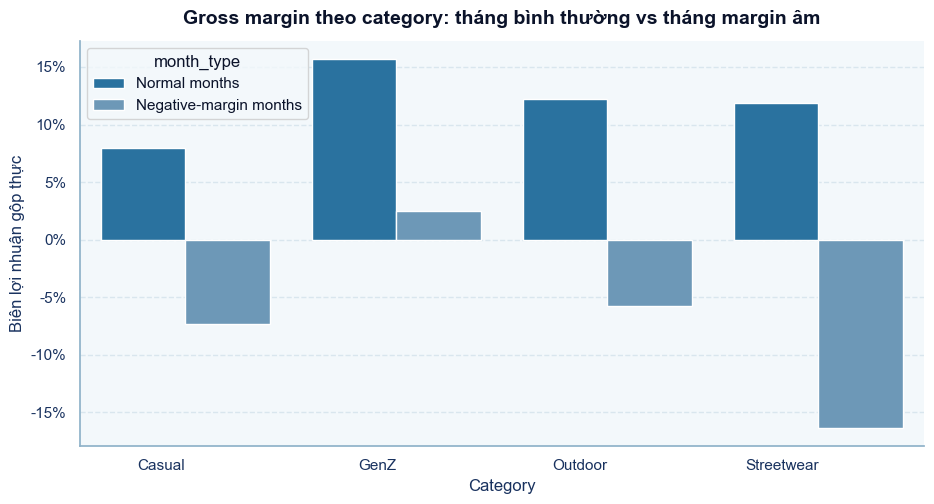

,negative_margin_month,category,net_revenue,gross_profit,promo_item_share,gross_margin
4,Negative-margin months,Casual,0.9,-0.1,65.27%,-7.32%
5,Negative-margin months,GenZ,0.8,0.0,62.17%,2.51%
6,Negative-margin months,Outdoor,4.8,-0.3,75.14%,-5.71%
7,Negative-margin months,Streetwear,22.9,-3.7,81.72%,-16.32%
0,Normal months,Casual,2.8,0.2,21.96%,7.94%
1,Normal months,GenZ,2.0,0.3,20.10%,15.68%
2,Normal months,Outdoor,15.0,1.8,27.08%,12.22%
3,Normal months,Streetwear,83.0,9.9,21.97%,11.90%


In [371]:
category_negative_profile = (
    deep_dive_finance.groupby(["negative_margin_month", "category"], as_index=False)
    .agg(
        net_revenue=("line_revenue", "sum"),
        gross_profit=("line_gross_profit", "sum"),
        promo_item_share=("has_any_promo", "mean"),
    )
)
category_negative_profile["gross_margin"] = (
    category_negative_profile["gross_profit"] / category_negative_profile["net_revenue"].replace(0, np.nan)
)

plot_df = category_negative_profile.copy()
plot_df["month_type"] = plot_df["negative_margin_month"].map(
    {False: "Normal months", True: "Negative-margin months"}
)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(data=plot_df, x="category", y="gross_margin", hue="month_type", ax=ax)
clean_axis(
    ax,
    xlabel="Category",
    ylabel="Biên lợi nhuận gộp thực",
    title="Gross margin theo category: tháng bình thường vs tháng margin âm",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
plt.xticks(ha="right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    category_negative_profile.assign(
        negative_margin_month=lambda df: df["negative_margin_month"].map({True: "Negative-margin months", False: "Normal months"}),
        net_revenue=lambda df: df["net_revenue"].map(format_hundred_millions),
        gross_profit=lambda df: df["gross_profit"].map(format_hundred_millions),
        promo_item_share=lambda df: df["promo_item_share"].map(format_pct),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
    ).sort_values(["negative_margin_month", "category"])
)


**Insight - Streetwear là category kéo margin âm mạnh nhất**

- So sánh theo category cho thấy margin âm không đến từ toàn bộ danh mục một cách đồng đều, mà tập trung rõ nhất ở **Streetwear**. 
- Trong negative-margin months, Streetwear tạo **22.9 trăm triệu VND net revenue** nhưng gross profit âm **3.7 trăm triệu VND**, gross margin **-16.32%**.

- Đáng chú ý hơn, promo item share của Streetwear trong negative-margin months lên tới **81.72%**, trong khi ở normal months chỉ khoảng **21.97%**. 
- Điều này cho thấy vấn đề có khả năng nằm ở cách Streetwear được bán trong các tháng khuyến mãi cao: doanh thu vẫn lớn, nhưng discount hoặc product mix khiến lợi nhuận bị kéo xuống mạnh.

- Vì vậy, Streetwear cần được ưu tiên audit sâu hơn ở các phần sau: nhóm khách hàng nào mua Streetwear, họ có phụ thuộc promo không, và liệu doanh thu từ nhóm này có thật sự đáng giữ nếu margin âm kéo dài.

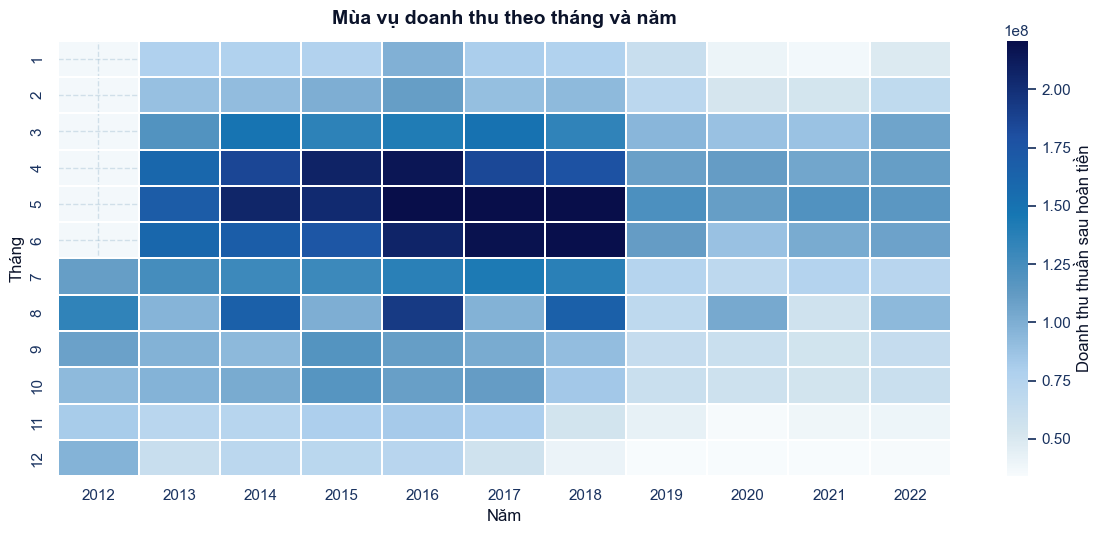

In [372]:
seasonality_pivot = monthly_business.pivot(
    index="month",
    columns="year",
    values="net_revenue",
)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    seasonality_pivot,
    cmap=MONO_CMAP,
    robust=True,
    linewidths=0.35,
    linecolor=PALETTE["white"],
    ax=ax,
    cbar_kws={"label": "Doanh thu thuần sau hoàn tiền"},
)
ax.set_title("Mùa vụ doanh thu theo tháng và năm", pad=12, fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Tháng")
plt.tight_layout()
plt.show()


**Insight - mùa vụ doanh thu tập trung ở giai đoạn tháng 4-6**

- Heatmap cho thấy doanh thu có tính mùa vụ rõ, với vùng cao điểm lặp lại quanh **tháng 4, tháng 5 và tháng 6** qua nhiều năm. 
- Đây là tín hiệu quan trọng cho planning: các tháng này nên là giai đoạn chuẩn bị trọng điểm về tồn kho, fulfillment và campaign.

- Tuy nhiên, mùa vụ cao không đồng nghĩa với lợi nhuận tốt. Do gross margin có nhiều tháng âm, các tháng cao điểm cần được đọc song song với margin để tránh tối ưu nhầm vào volume nhưng làm mỏng lợi nhuận.

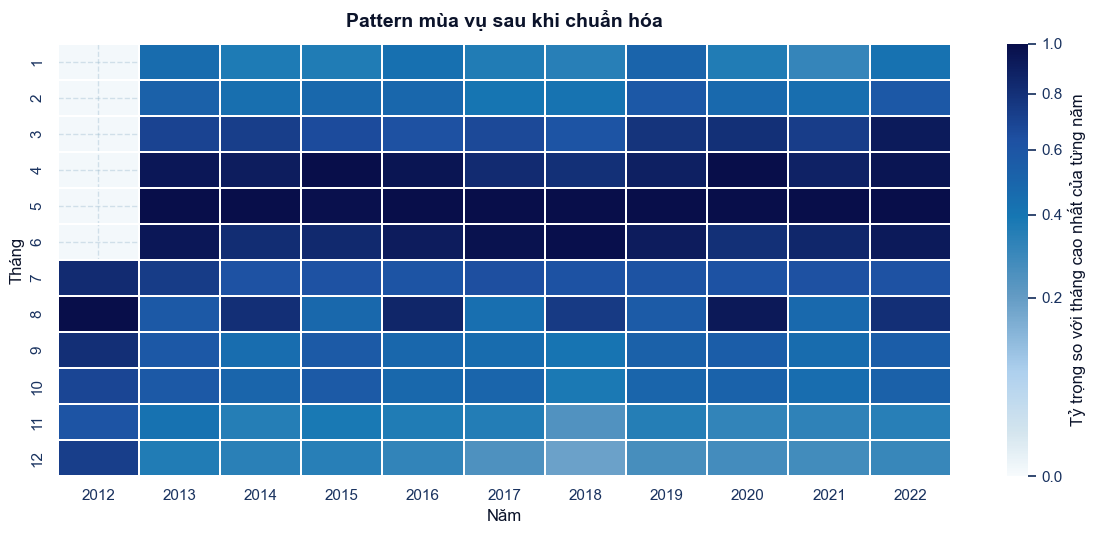

Tần suất tháng nằm trong top 3 theo từng năm:
month
4    10
5    10
6     9
7     1
8     2
9     1
Name: count, dtype: int64

Các tháng mạnh nhất trong năm 2022:


,year,month,net_revenue,rank
118,2022,5,1.2,1.0
117,2022,4,1.1,2.0
119,2022,6,1.1,3.0
116,2022,3,1.1,4.0
121,2022,8,0.9,5.0


In [373]:
seasonality_pivot_norm = seasonality_pivot.div(
    seasonality_pivot.max(axis=0),
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    seasonality_pivot_norm,
    cmap=MONO_CMAP,
    norm=mcolors.PowerNorm(gamma=0.55, vmin=0, vmax=1),
    linewidths=0.35,
    linecolor=PALETTE["white"],
    ax=ax,
    cbar_kws={"label": "Tỷ trọng so với tháng cao nhất của từng năm"},
)
ax.set_title("Pattern mùa vụ sau khi chuẩn hóa", pad=12, fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Tháng")
plt.tight_layout()
plt.show()

monthly_rank = monthly_business[["year", "month", "net_revenue"]].copy()
monthly_rank["rank"] = monthly_rank.groupby("year")["net_revenue"].rank(ascending=False, method="dense")

top_months = monthly_rank.loc[monthly_rank["rank"] <= 3, "month"].value_counts().sort_index()
print("Tần suất tháng nằm trong top 3 theo từng năm:")
print(top_months)

latest_year = int(monthly_rank["year"].max())
print(f"\nCác tháng mạnh nhất trong năm {latest_year}:")
display(
    monthly_rank.loc[monthly_rank["year"] == latest_year]
    .sort_values("rank")
    .head(5)
    .assign(net_revenue=lambda df: df["net_revenue"].map(format_hundred_millions))
)


**Insight - top months xác nhận peak mùa vụ ổn định**

- Bảng top months xác nhận pattern trên heatmap: **tháng 4 và tháng 5 đều nằm trong top 3 doanh thu ở 10 năm**, còn **tháng 6 xuất hiện 9 năm**. 
- Điều này cho thấy giai đoạn tháng 4-6 là peak season ổn định, không phải hiện tượng của một năm riêng lẻ.
- Với năm 2022, top 3 tháng doanh thu vẫn là **tháng 5, tháng 4 và tháng 6**, nên pattern mùa vụ này vẫn còn duy trì ở cuối kỳ dữ liệu. Đây có thể là baseline quan trọng cho forecast, inventory planning và campaign calendar.

**Insight - seasonality sau chuẩn hóa xác nhận đây là pattern thật**

- Sau khi chuẩn hóa theo từng năm, pattern mùa vụ vẫn nổi bật ở các tháng cao điểm. 
- Điều này cho thấy peak season không chỉ đến từ việc một vài năm có quy mô doanh thu lớn hơn, mà là tín hiệu lặp lại trong cấu trúc demand.

- Tuy nhiên, seasonality chỉ cho biết thời điểm demand mạnh, chưa cho biết demand đó có lợi nhuận tốt hay không. Vì vậy, kết luận của Lớp 1 không nên dừng ở “tháng nào bán tốt”, mà cần nối sang câu hỏi sâu hơn: khách hàng, category và promo nào đang đứng sau các tháng có doanh thu cao nhưng margin yếu.

## Tổng kết Lớp 1 - Bức tranh tài chính tổng thể

- Lớp 1 cho thấy doanh nghiệp không thiếu khả năng tạo doanh thu, nhưng vấn đề nằm ở **chất lượng doanh thu và khả năng giữ lại lợi nhuận**. Trong financial scope, doanh nghiệp ghi nhận **566,620 đơn**, doanh thu thuần sau hoàn tiền đạt **132.1 trăm triệu VND**, nhưng lợi nhuận gộp chỉ còn **8.2 trăm triệu VND**, tương ứng gross margin **6.20%**.

- Biên lợi nhuận này khá mỏng, nên các yếu tố như discount, refund và COGS có thể nhanh chóng bào mòn lợi nhuận. Điều này cho thấy tăng doanh thu không tự động đồng nghĩa với tăng trưởng tốt nếu doanh thu đến từ các tháng, category hoặc chương trình có margin yếu.

- Phân tích theo thời gian cho thấy doanh thu có mùa vụ rõ, đặc biệt tập trung ở **tháng 4-6**. Tuy nhiên, gross margin lại dao động mạnh và nhiều tháng rơi xuống âm, cho thấy một số giai đoạn doanh nghiệp bán được hàng nhưng không giữ lại được lợi nhuận.

- Điểm cần chú ý nhất là các **negative-margin months**: nhóm này tạo **29.4 trăm triệu VND net revenue** nhưng làm mất **4.1 trăm triệu VND gross profit**, với promo item share lên tới **77.47%**. Ở cấp category, rủi ro tập trung rõ nhất ở **Streetwear**, nơi gross margin rơi xuống **-16.32%** trong các tháng margin âm và promo item share đạt **81.72%**.

- Vì vậy, Lớp 2 sẽ đi sâu vào câu hỏi: **nhóm khách hàng nào đang tạo doanh thu có chất lượng tốt, và nhóm nào đang làm mỏng lợi nhuận thông qua discount, return hoặc category mix kém hiệu quả?**

### Lớp 2 - Phân khúc và hành vi khách hàng

- Lớp 1 cho thấy vấn đề chính không chỉ nằm ở doanh thu, mà nằm ở chất lượng lợi nhuận: biên lợi nhuận mỏng, nhiều tháng margin âm, promo share cao và rủi ro tập trung rõ ở Streetwear.

- Vì vậy, Lớp 2 này tập trung trả lời:

    - Nhóm khách hàng nào tạo giá trị thật cho doanh nghiệp?
    - Nhóm nào tạo doanh thu cao nhưng lợi nhuận thấp?
    - Nhóm nào phụ thuộc nhiều vào khuyến mãi?
    - Nhóm nào tạo áp lực return/refund?
    - Nhóm giá trị cao có đang còn active hay đã có dấu hiệu rời bỏ?

In [374]:
customer_item_fact = (
    customer_orders[
        ["order_id", "order_date", "customer_id", "payment_method", "order_source"]
    ]
    .merge(customer_order_items, on="order_id", how="inner")
    .merge(
        products[["product_id", "category", "segment", "size", "cogs"]],
        on="product_id",
        how="left",
    )
    .rename(columns={"cogs": "product_unit_cogs"})
    .copy()
)

customer_item_fact["gross_line_sales"] = (
    customer_item_fact["quantity"] * customer_item_fact["unit_price"]
)
customer_item_fact["line_revenue"] = (
    customer_item_fact["gross_line_sales"] - customer_item_fact["discount_amount"]
)
customer_item_fact["line_cogs"] = (
    customer_item_fact["quantity"] * customer_item_fact["product_unit_cogs"]
)
customer_item_fact["line_gross_profit"] = (
    customer_item_fact["line_revenue"] - customer_item_fact["line_cogs"]
)
customer_item_fact["has_any_promo"] = (
    customer_item_fact["promo_id"].notna() | customer_item_fact["promo_id_2"].notna()
)

print("Customer scope orders:", format_number(customer_orders["order_id"].nunique()))
print("Customer item rows:", format_number(len(customer_item_fact)))


Customer scope orders: 530,478
Customer item rows: 585,969


#### 1. Customer Value Segment

Mục tiêu đầu tiên của Lớp 2 là xác định nhóm khách hàng nào thật sự tạo ra doanh thu và lợi nhuận, thay vì chỉ nhìn tổng chi tiêu.

Phần này giữ `customer_orders` làm baseline hành vi mua thành công, sau đó nối thêm `financial_order_line_fact` để đo discount, refund và gross profit ở cấp customer.


In [375]:
customer_order_level_fact = (
    customer_item_fact.groupby(
        ["customer_id", "order_id", "order_date", "payment_method", "order_source"],
        as_index=False,
    )
    .agg(
        total_quantity=("quantity", "sum"),
        gross_sales=("gross_line_sales", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue_success=("line_revenue", "sum"),
        gross_profit_success=("line_gross_profit", "sum"),
        has_any_promo=("has_any_promo", "max"),
        streetwear_revenue_success=(
            "line_revenue",
            lambda s: s[customer_item_fact.loc[s.index, "category"].eq("Streetwear")].sum(),
        ),
    )
)
customer_order_level_fact["promo_order_count_flag"] = (
    customer_order_level_fact["has_any_promo"].astype(int)
)

customer_financial_order_fact = (
    financial_order_line_fact.assign(
        has_any_promo=lambda df: df["promo_id"].notna() | df["promo_id_2"].notna(),
        has_return_line=lambda df: df["allocated_refund_amount"].gt(0) | df["return_quantity"].gt(0),
        streetwear_revenue=lambda df: np.where(df["category"].eq("Streetwear"), df["line_revenue"], 0),
        streetwear_gross_profit=lambda df: np.where(df["category"].eq("Streetwear"), df["line_gross_profit"], 0),
        streetwear_refund=lambda df: np.where(df["category"].eq("Streetwear"), df["allocated_refund_amount"], 0),
    )
    .groupby(["customer_id", "order_id", "order_date"], as_index=False)
    .agg(
        gross_sales=("gross_line_sales", "sum"),
        discount_amount=("discount_amount", "sum"),
        revenue_before_refund=("line_revenue_before_refund", "sum"),
        net_revenue_after_refund=("line_revenue", "sum"),
        gross_profit_after_refund=("line_gross_profit", "sum"),
        refund_amount=("allocated_refund_amount", "sum"),
        has_any_promo=("has_any_promo", "max"),
        has_return_order=("has_return_line", "max"),
        streetwear_revenue=("streetwear_revenue", "sum"),
        streetwear_gross_profit=("streetwear_gross_profit", "sum"),
        streetwear_refund=("streetwear_refund", "sum"),
    )
)
customer_financial_order_fact["promo_order_count_flag"] = (
    customer_financial_order_fact["has_any_promo"].astype(int)
)
customer_financial_order_fact["return_order_count_flag"] = (
    customer_financial_order_fact["has_return_order"].astype(int)
)


In [376]:
analysis_date = customer_orders["order_date"].max() + pd.Timedelta(days=1)

customer_behavior_metrics = (
    customer_order_level_fact.groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        order_count=("order_id", pd.Series.nunique),
        successful_revenue=("net_revenue_success", "sum"),
        successful_gross_profit=("gross_profit_success", "sum"),
        successful_discount=("discount_amount", "sum"),
        promo_order_count=("promo_order_count_flag", "sum"),
        streetwear_revenue_success=("streetwear_revenue_success", "sum"),
    )
)

customer_financial_metrics = (
    customer_financial_order_fact.groupby("customer_id", as_index=False)
    .agg(
        financial_order_count=("order_id", pd.Series.nunique),
        gross_sales=("gross_sales", "sum"),
        discount_amount=("discount_amount", "sum"),
        revenue_before_refund=("revenue_before_refund", "sum"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        refund_amount=("refund_amount", "sum"),
        promo_financial_order_count=("promo_order_count_flag", "sum"),
        return_order_count=("return_order_count_flag", "sum"),
        streetwear_revenue=("streetwear_revenue", "sum"),
        streetwear_gross_profit=("streetwear_gross_profit", "sum"),
        streetwear_refund=("streetwear_refund", "sum"),
    )
)

customer_fact = (
    customer_behavior_metrics
    .merge(customer_financial_metrics, on="customer_id", how="left")
    .merge(
        customers[["customer_id", "city", "gender", "age_group", "acquisition_channel"]],
        on="customer_id",
        how="left",
    )
)

fill_zero_cols = [
    "financial_order_count",
    "gross_sales",
    "discount_amount",
    "revenue_before_refund",
    "net_revenue_after_refund",
    "gross_profit_after_refund",
    "refund_amount",
    "promo_financial_order_count",
    "return_order_count",
    "streetwear_revenue",
    "streetwear_gross_profit",
    "streetwear_refund",
]
for col in fill_zero_cols:
    customer_fact[col] = customer_fact[col].fillna(0)

customer_fact["recency_days"] = (
    analysis_date - customer_fact["last_order_date"]
).dt.days
customer_fact["frequency"] = customer_fact["order_count"]
customer_fact["monetary"] = customer_fact["net_revenue_after_refund"]
customer_fact["gross_margin_after_refund"] = (
    customer_fact["gross_profit_after_refund"]
    / customer_fact["net_revenue_after_refund"].replace(0, np.nan)
)
customer_fact["aov_after_refund"] = (
    customer_fact["net_revenue_after_refund"]
    / customer_fact["order_count"].replace(0, np.nan)
)
customer_fact["discount_rate"] = (
    customer_fact["discount_amount"]
    / customer_fact["gross_sales"].replace(0, np.nan)
)
customer_fact["refund_rate"] = (
    customer_fact["refund_amount"]
    / customer_fact["revenue_before_refund"].replace(0, np.nan)
)
customer_fact["promo_order_share"] = (
    customer_fact["promo_order_count"]
    / customer_fact["order_count"].replace(0, np.nan)
)
customer_fact["return_order_share"] = (
    customer_fact["return_order_count"]
    / customer_fact["financial_order_count"].replace(0, np.nan)
)
customer_fact["streetwear_revenue_share"] = (
    customer_fact["streetwear_revenue"]
    / customer_fact["net_revenue_after_refund"].replace(0, np.nan)
)

print("Customers in Layer 2 baseline:", format_number(customer_fact["customer_id"].nunique()))
display(customer_fact.head())


Customers in Layer 2 baseline: 85,735


,customer_id,first_order_date,last_order_date,order_count,successful_revenue,successful_gross_profit,successful_discount,promo_order_count,streetwear_revenue_success,financial_order_count,...,recency_days,frequency,monetary,gross_margin_after_refund,aov_after_refund,discount_rate,refund_rate,promo_order_share,return_order_share,streetwear_revenue_share
0,1,2012-07-25,2020-02-24,4,98782.44,23273.283353,0.00,0,94549.11,5,...,1042,4,98862.58,0.222231,24715.645,0.000000,0.01395,0.0,0.2,0.956369
1,2,2013-09-20,2022-07-06,2,126255.29,-27479.945405,20532.05,2,126255.29,2,...,179,2,126255.29,-0.217654,63127.645,0.139876,0.00000,1.0,0.0,1.000000
2,3,2012-08-27,2012-11-24,2,12001.55,1530.928823,0.00,0,7169.36,2,...,3690,2,12001.55,0.127561,6000.775,0.000000,0.00000,0.0,0.0,0.597370
3,4,2020-06-28,2020-06-28,1,10939.06,-4511.207478,2401.26,1,10939.06,1,...,917,1,10939.06,-0.412394,10939.060,0.180000,0.00000,1.0,0.0,1.000000
4,5,2012-08-09,2019-03-27,5,64179.86,12736.548571,4895.48,2,43004.02,5,...,1376,5,64179.86,0.198451,12835.972,0.070872,0.00000,0.4,0.0,0.670055


In [377]:
customer_value_order = [
    "High Revenue - High Margin",
    "High Revenue - Low Margin",
    "Low Revenue - High Margin",
    "Low Revenue - Low Margin",
]

revenue_cutoff = customer_fact["net_revenue_after_refund"].median()
margin_cutoff = customer_fact.loc[
    customer_fact["net_revenue_after_refund"].gt(0),
    "gross_margin_after_refund",
].median()

customer_fact["customer_value_segment"] = np.select(
    [
        customer_fact["net_revenue_after_refund"].ge(revenue_cutoff)
        & customer_fact["gross_margin_after_refund"].ge(margin_cutoff),
        customer_fact["net_revenue_after_refund"].ge(revenue_cutoff)
        & customer_fact["gross_margin_after_refund"].lt(margin_cutoff),
        customer_fact["net_revenue_after_refund"].lt(revenue_cutoff)
        & customer_fact["gross_margin_after_refund"].ge(margin_cutoff),
    ],
    customer_value_order[:3],
    default=customer_value_order[3],
)

customer_value_summary = (
    customer_fact.groupby("customer_value_segment", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        order_count=("order_count", "sum"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        gross_margin_after_refund=("gross_profit_after_refund", lambda s: s.sum()),
        refund_amount=("refund_amount", "sum"),
        discount_amount=("discount_amount", "sum"),
        avg_aov_after_refund=("aov_after_refund", "mean"),
        avg_promo_order_share=("promo_order_share", "mean"),
    )
)
customer_value_summary["gross_margin_after_refund"] = (
    customer_value_summary["gross_profit_after_refund"]
    / customer_value_summary["net_revenue_after_refund"].replace(0, np.nan)
)
customer_value_summary["refund_rate"] = (
    customer_value_summary["refund_amount"]
    / customer_value_summary["net_revenue_after_refund"].replace(0, np.nan)
)
customer_value_summary["discount_rate"] = (
    customer_value_summary["discount_amount"]
    / (
        customer_value_summary["net_revenue_after_refund"]
        + customer_value_summary["refund_amount"]
        + customer_value_summary["discount_amount"]
    ).replace(0, np.nan)
)
customer_value_summary["customer_value_segment"] = pd.Categorical(
    customer_value_summary["customer_value_segment"],
    categories=customer_value_order,
    ordered=True,
)
customer_value_summary = customer_value_summary.sort_values("customer_value_segment").reset_index(drop=True)
customer_value_summary["revenue_share"] = (
    customer_value_summary["net_revenue_after_refund"]
    / customer_value_summary["net_revenue_after_refund"].sum()
)
customer_value_summary["profit_share"] = (
    customer_value_summary["gross_profit_after_refund"]
    / customer_value_summary["gross_profit_after_refund"].sum()
)

print("Revenue median cutoff:", format_hundred_millions(revenue_cutoff), "trăm triệu VND")
print("Margin median cutoff:", format_pct(margin_cutoff))

display(
    customer_value_summary.assign(
        customer_count=lambda df: df["customer_count"].map(format_number),
        order_count=lambda df: df["order_count"].map(format_number),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        gross_margin_after_refund=lambda df: df["gross_margin_after_refund"].map(format_pct),
        refund_rate=lambda df: df["refund_rate"].map(format_pct),
        discount_rate=lambda df: df["discount_rate"].map(format_pct),
        revenue_share=lambda df: df["revenue_share"].map(format_pct),
        profit_share=lambda df: df["profit_share"].map(format_pct),
        avg_aov_after_refund=lambda df: df["avg_aov_after_refund"].map(format_hundred_millions),
        avg_promo_order_share=lambda df: df["avg_promo_order_share"].map(format_pct),
    )
)


Revenue median cutoff: 0.0 trăm triệu VND
Margin median cutoff: 7.44%


,customer_value_segment,customer_count,order_count,net_revenue_after_refund,gross_profit_after_refund,gross_margin_after_refund,refund_amount,discount_amount,avg_aov_after_refund,avg_promo_order_share,refund_rate,discount_rate,revenue_share,profit_share
0,High Revenue - High Margin,"21,570","218,876",58.7,8.6,14.61%,9.489315e+07,2.077422e+08,0.0,29.51%,1.62%,3.37%,44.48%,102.34%
1,High Revenue - Low Margin,"21,298","230,288",58.8,-0.8,-1.40%,3.297546e+08,3.629187e+08,0.0,43.70%,5.61%,5.52%,44.54%,-9.80%
2,Low Revenue - High Margin,"21,298","39,814",7.4,1.6,22.19%,4.326786e+06,2.073655e+07,0.0,21.35%,0.59%,2.71%,5.60%,19.57%
3,Low Revenue - Low Margin,"21,569","41,500",7.1,-1.0,-14.28%,5.881879e+07,6.347249e+07,0.0,58.55%,8.28%,7.62%,5.38%,-12.11%


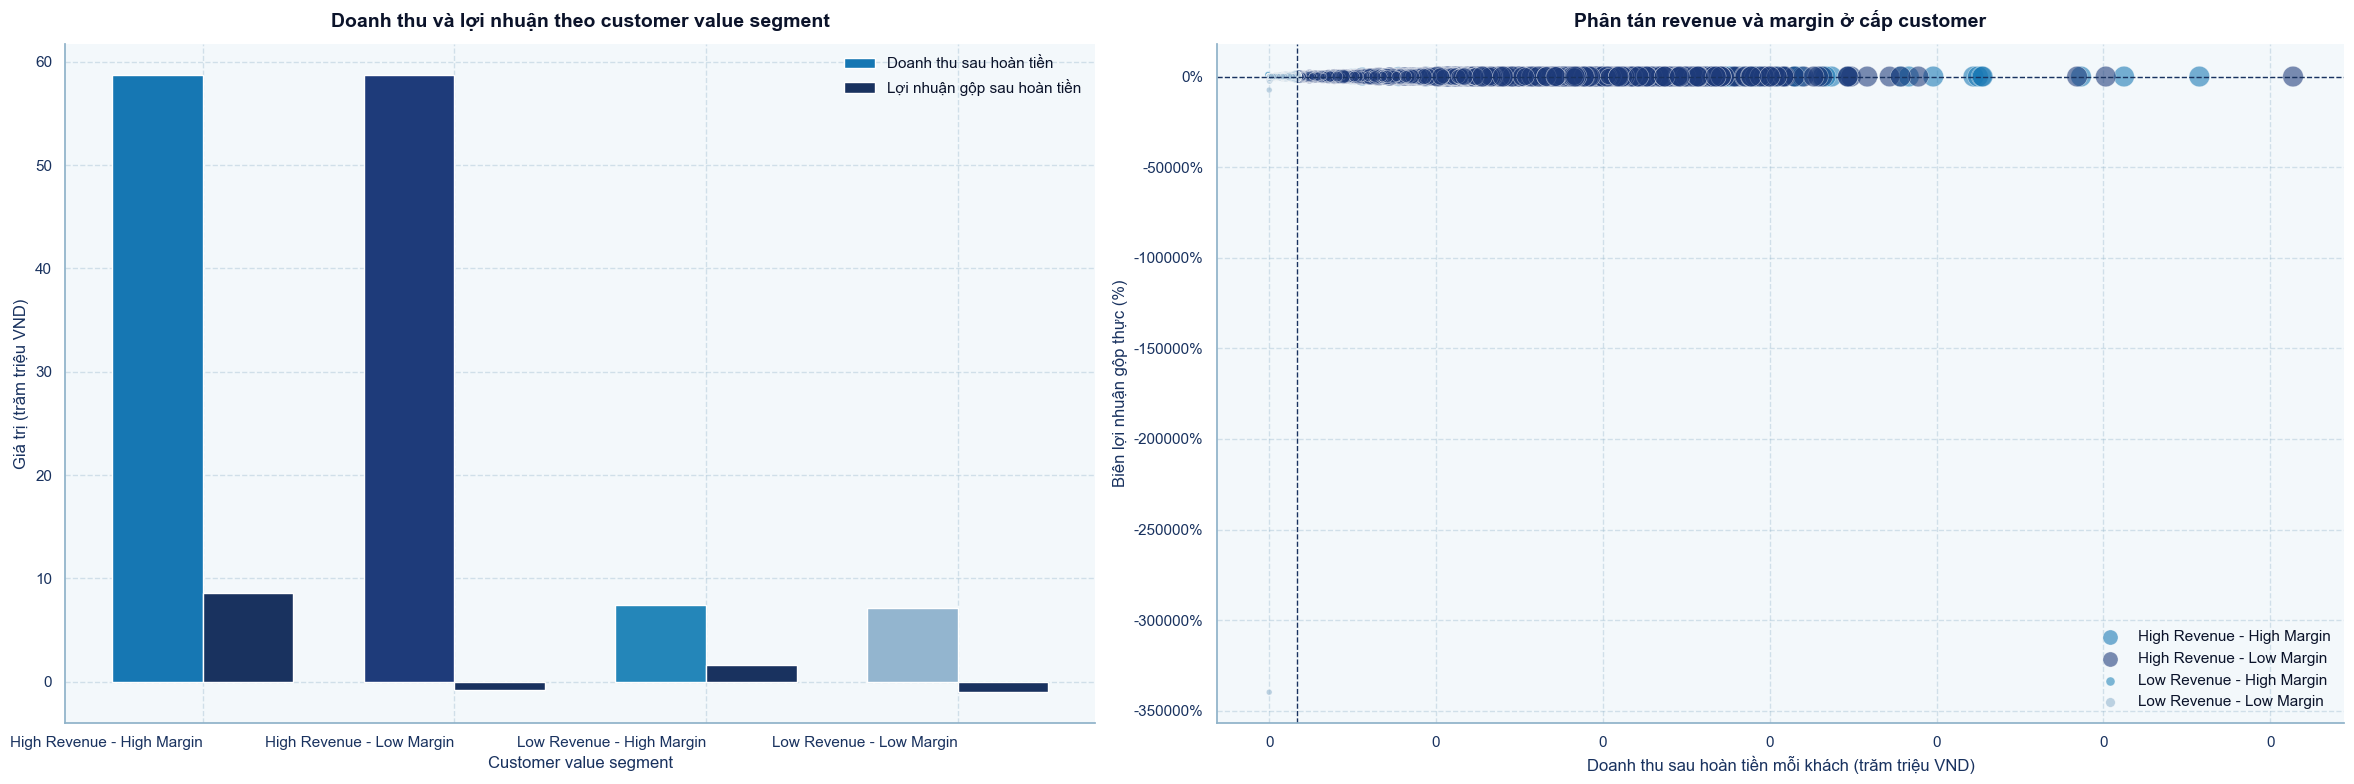

In [378]:
segment_colors = {
    "High Revenue - High Margin": PALETTE["green"],
    "High Revenue - Low Margin": PALETTE["risk_red"],
    "Low Revenue - High Margin": PALETTE["info_blue"],
    "Low Revenue - Low Margin": PALETTE["base_bar"],
}

plot_df = customer_value_summary.copy()
plot_df["customer_value_segment"] = plot_df["customer_value_segment"].astype(str)
value_x = np.arange(len(plot_df))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(24, 8), gridspec_kw={"width_ratios": [1.05, 1.15]})
axes[0].bar(
    value_x - bar_width / 2,
    plot_df["net_revenue_after_refund"],
    width=bar_width,
    color=[segment_colors[s] for s in plot_df["customer_value_segment"]],
    label="Doanh thu sau hoàn tiền",
)
axes[0].bar(
    value_x + bar_width / 2,
    plot_df["gross_profit_after_refund"],
    width=bar_width,
    color=PALETTE["dark_gray"],
    label="Lợi nhuận gộp sau hoàn tiền",
)
clean_axis(
    axes[0],
    xlabel="Customer value segment",
    ylabel="Giá trị (trăm triệu VND)",
    title="Doanh thu và lợi nhuận theo customer value segment",
)
axes[0].set_xticks(value_x)
axes[0].set_xticklabels(plot_df["customer_value_segment"], ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].legend(frameon=False)

for segment in customer_value_order:
    segment_slice = customer_fact.loc[customer_fact["customer_value_segment"].eq(segment)]
    axes[1].scatter(
        segment_slice["net_revenue_after_refund"],
        segment_slice["gross_margin_after_refund"] * 100,
        s=np.clip(segment_slice["order_count"] * 6, 18, 220),
        alpha=0.58,
        color=segment_colors[segment],
        edgecolor=PALETTE["white"],
        linewidth=0.4,
        label=segment,
    )
axes[1].axvline(revenue_cutoff, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)
axes[1].axhline(margin_cutoff * 100, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)
clean_axis(
    axes[1],
    xlabel="Doanh thu sau hoàn tiền mỗi khách (trăm triệu VND)",
    ylabel="Biên lợi nhuận gộp thực (%)",
    title="Phân tán revenue và margin ở cấp customer",
)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_phan_tram))
axes[1].legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()


**Insight - doanh thu cao chưa chắc là khách hàng tốt**

- Hai nhóm `High Revenue` tạo doanh thu gần tương đương nhau, nhưng chất lượng lợi nhuận hoàn toàn khác nhau.

- Nhóm `High Revenue - High Margin` tạo **58.7 trăm triệu VND doanh thu sau hoàn tiền** và **8.6 trăm triệu VND gross profit**, với margin **14.61%**. Đây là nhóm khách hàng quan trọng nhất vì họ vừa mua nhiều, vừa giúp doanh nghiệp giữ lại lợi nhuận thật.

- Ngược lại, nhóm `High Revenue - Low Margin` tạo doanh thu gần như tương đương, **58.8 trăm triệu VND**, nhưng gross profit lại âm **0.8 trăm triệu VND**, margin **-1.40%**. Đây chính là bằng chứng ở cấp customer cho vấn đề đã thấy ở Lớp 1: doanh thu lớn vẫn có thể làm mỏng lợi nhuận nếu đi kèm discount, refund hoặc category mix kém hiệu quả.

Vì vậy, Lớp 3 không nên ưu tiên khách hàng chỉ dựa trên doanh thu. Nhóm cần giữ chân trước là `High Revenue - High Margin`; còn `High Revenue - Low Margin` cần được quản lý lại về khuyến mãi, return và product mix trước khi tiếp tục đầu tư giữ chân.

#### 2. Discount Dependency

Sau khi xác định nhóm khách tạo giá trị thật, bước tiếp theo là kiểm tra mức độ phụ thuộc vào discount. 

In [379]:
promo_share_cutoffs = customer_fact["promo_order_share"].quantile([0.33, 0.66]).fillna(0)
discount_rate_cutoffs = customer_fact["discount_rate"].quantile([0.33, 0.66]).fillna(0)

customer_fact["discount_dependency_segment"] = np.select(
    [
        (customer_fact["promo_order_share"] >= promo_share_cutoffs.loc[0.66])
        | (customer_fact["discount_rate"] >= discount_rate_cutoffs.loc[0.66]),
        (customer_fact["promo_order_share"] >= promo_share_cutoffs.loc[0.33])
        | (customer_fact["discount_rate"] >= discount_rate_cutoffs.loc[0.33]),
    ],
    ["High discount dependency", "Medium discount dependency"],
    default="Low discount dependency",
)

discount_dependency_order = [
    "High discount dependency",
    "Medium discount dependency",
    "Low discount dependency",
]

discount_dependency_summary = (
    customer_fact.groupby("discount_dependency_segment", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        order_count=("order_count", "sum"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        refund_amount=("refund_amount", "sum"),
        avg_discount_rate=("discount_rate", "mean"),
        avg_promo_order_share=("promo_order_share", "mean"),
    )
)
discount_dependency_summary["gross_margin"] = (
    discount_dependency_summary["gross_profit_after_refund"]
    / discount_dependency_summary["net_revenue_after_refund"].replace(0, np.nan)
)
discount_dependency_summary["refund_rate"] = (
    discount_dependency_summary["refund_amount"]
    / discount_dependency_summary["net_revenue_after_refund"].replace(0, np.nan)
)
discount_dependency_summary["discount_dependency_segment"] = pd.Categorical(
    discount_dependency_summary["discount_dependency_segment"],
    categories=discount_dependency_order,
    ordered=True,
)
discount_dependency_summary = discount_dependency_summary.sort_values("discount_dependency_segment").reset_index(drop=True)

display(
    discount_dependency_summary.assign(
        customer_count=lambda df: df["customer_count"].map(format_number),
        order_count=lambda df: df["order_count"].map(format_number),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        avg_discount_rate=lambda df: df["avg_discount_rate"].map(format_pct),
        avg_promo_order_share=lambda df: df["avg_promo_order_share"].map(format_pct),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
        refund_rate=lambda df: df["refund_rate"].map(format_pct),
    )
)


,discount_dependency_segment,customer_count,order_count,net_revenue_after_refund,gross_profit_after_refund,refund_amount,avg_discount_rate,avg_promo_order_share,gross_margin,refund_rate
0,High discount dependency,"38,169","208,468",48.0,-0.2,1.975373e+08,9.11%,66.15%,-0.49%,4.12%
1,Medium discount dependency,"23,293","266,406",68.6,6.0,2.501655e+08,3.16%,31.18%,8.76%,3.65%
2,Low discount dependency,"24,273","55,604",15.4,2.6,4.009050e+07,0.06%,1.38%,16.94%,2.61%


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1551947134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1551947134.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


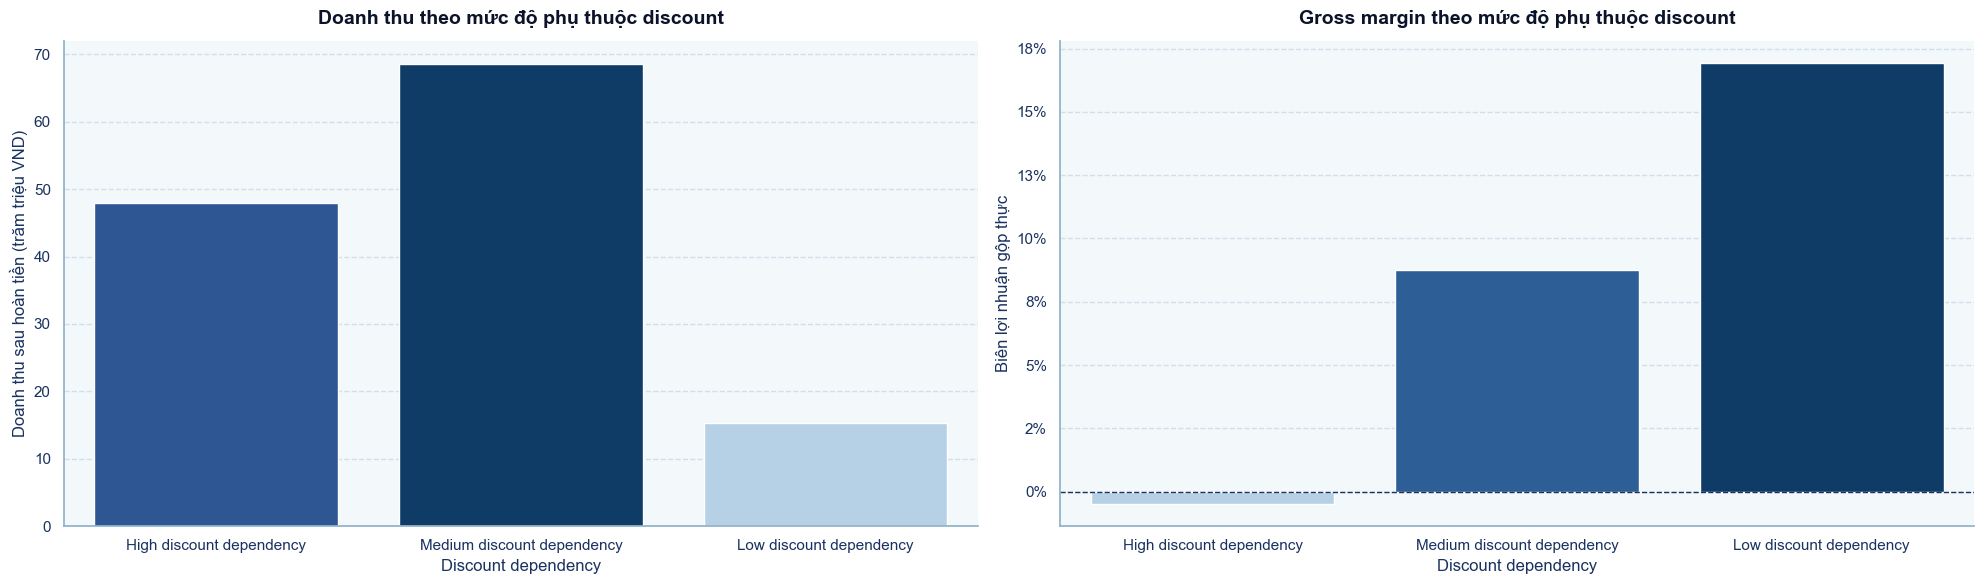

In [380]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
plot_df = discount_dependency_summary.copy()
plot_df["discount_dependency_segment"] = plot_df["discount_dependency_segment"].astype(str)

sns.barplot(
    data=plot_df,
    x="discount_dependency_segment",
    y="net_revenue_after_refund",
    palette=gradient_palette(plot_df["net_revenue_after_refund"]),
    ax=axes[0],
)
clean_axis(
    axes[0],
    xlabel="Discount dependency",
    ylabel="Doanh thu sau hoàn tiền (trăm triệu VND)",
    title="Doanh thu theo mức độ phụ thuộc discount",
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].tick_params(axis="x")

sns.barplot(
    data=plot_df,
    x="discount_dependency_segment",
    y="gross_margin",
    palette=gradient_palette(plot_df["gross_margin"]),
    ax=axes[1],
)
clean_axis(
    axes[1],
    xlabel="Discount dependency",
    ylabel="Biên lợi nhuận gộp thực",
    title="Gross margin theo mức độ phụ thuộc discount",
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
axes[1].tick_params(axis="x")
axes[1].axhline(0, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


**Insight - discount đang tạo doanh thu nhưng không luôn tạo lợi nhuận**

- Nhóm `High discount dependency` tạo **48.0 trăm triệu VND doanh thu**, nhưng gross profit gần như không còn, ở mức **-0.2 trăm triệu VND**, với margin **-0.49%**. 
- Nhóm này có promo order share rất cao, **66.15%**, và discount rate trung bình **9.11%**.

- Trong khi đó, nhóm `Low discount dependency` chỉ tạo **15.4 trăm triệu VND doanh thu**, nhưng vẫn giữ được **2.6 trăm triệu VND gross profit**, với margin **16.94%**. 
- Điều này cho thấy nhóm ít phụ thuộc discount có quy mô nhỏ hơn nhưng chất lượng lợi nhuận tốt hơn nhiều.

- Nhóm đáng chú ý nhất về mặt scale là `Medium discount dependency`: tạo **68.6 trăm triệu VND doanh thu** và **6.0 trăm triệu VND gross profit**, margin **8.76%**. 
- Đây có thể là vùng cân bằng tốt hơn giữa tăng trưởng và lợi nhuận.

**Kết luận chính**: Discount không nên được dùng đại trà để kéo doanh thu. Với nhóm discount-heavy, doanh nghiệp cần kiểm soát mức ưu đãi hoặc chuyển sang ưu đãi có điều kiện như bundle, threshold spend, loyalty point thay vì giảm giá trực tiếp.

#### 3. Return Risk

Sau discount, nhánh cần kiểm tra tiếp là return/refund. Đây là phần nối trực tiếp từ insight `Streetwear kéo margin âm` ở Lớp 1.


In [381]:
positive_refund_rates = customer_fact.loc[
    customer_fact["refund_rate"].gt(0),
    "refund_rate",
]
if len(positive_refund_rates) > 0:
    high_refund_cutoff = positive_refund_rates.quantile(0.66)
else:
    high_refund_cutoff = 0

customer_fact["return_risk_segment"] = np.select(
    [
        customer_fact["refund_rate"].ge(high_refund_cutoff) & customer_fact["refund_amount"].gt(0),
        customer_fact["refund_amount"].gt(0),
    ],
    ["High return risk", "Medium return risk"],
    default="Low return risk",
)

return_risk_order = ["High return risk", "Medium return risk", "Low return risk"]
return_risk_summary = (
    customer_fact.groupby("return_risk_segment", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        order_count=("order_count", "sum"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        refund_amount=("refund_amount", "sum"),
        avg_return_order_share=("return_order_share", "mean"),
        avg_streetwear_revenue_share=("streetwear_revenue_share", "mean"),
    )
)
return_risk_summary["gross_margin"] = (
    return_risk_summary["gross_profit_after_refund"]
    / return_risk_summary["net_revenue_after_refund"].replace(0, np.nan)
)
return_risk_summary["refund_rate"] = (
    return_risk_summary["refund_amount"]
    / return_risk_summary["net_revenue_after_refund"].replace(0, np.nan)
)
return_risk_summary["return_risk_segment"] = pd.Categorical(
    return_risk_summary["return_risk_segment"],
    categories=return_risk_order,
    ordered=True,
)
return_risk_summary = return_risk_summary.sort_values("return_risk_segment").reset_index(drop=True)

display(
    return_risk_summary.assign(
        customer_count=lambda df: df["customer_count"].map(format_number),
        order_count=lambda df: df["order_count"].map(format_number),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        refund_amount=lambda df: df["refund_amount"].map(format_hundred_millions),
        avg_return_order_share=lambda df: df["avg_return_order_share"].map(format_pct),
        avg_streetwear_revenue_share=lambda df: df["avg_streetwear_revenue_share"].map(format_pct),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
        refund_rate=lambda df: df["refund_rate"].map(format_pct),
    )
)

high_return_risk_customers = customer_fact.loc[
    customer_fact["return_risk_segment"].eq("High return risk"),
    "customer_id",
]

high_return_risk_lines = financial_order_line_fact.loc[
    financial_order_line_fact["customer_id"].isin(high_return_risk_customers)
].copy()

high_return_category_summary = (
    high_return_risk_lines.groupby("category", as_index=False)
    .agg(
        net_revenue=("line_revenue", "sum"),
        gross_profit=("line_gross_profit", "sum"),
        refund_amount=("allocated_refund_amount", "sum"),
    )
    .sort_values("refund_amount", ascending=False)
)
high_return_category_summary["refund_rate"] = (
    high_return_category_summary["refund_amount"]
    / high_return_category_summary["net_revenue"].replace(0, np.nan)
)

high_return_size_summary = (
    high_return_risk_lines.groupby("size", as_index=False)
    .agg(refund_amount=("allocated_refund_amount", "sum"))
    .sort_values("refund_amount", ascending=False)
)


,return_risk_segment,customer_count,order_count,net_revenue_after_refund,gross_profit_after_refund,refund_amount,avg_return_order_share,avg_streetwear_revenue_share,gross_margin,refund_rate
0,High return risk,"7,969","50,819",12.4,-1.2,2.7,26.68%,72.45%,-10.00%,21.67%
1,Medium return risk,"15,469","219,699",56.7,3.6,2.2,12.41%,78.23%,6.33%,3.88%
2,Low return risk,"62,297","259,960",62.9,6.0,0.0,0.00%,69.12%,9.58%,0.00%


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\2550157429.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reust\AppData\Local\Temp\ipykernel_65204\2550157429.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


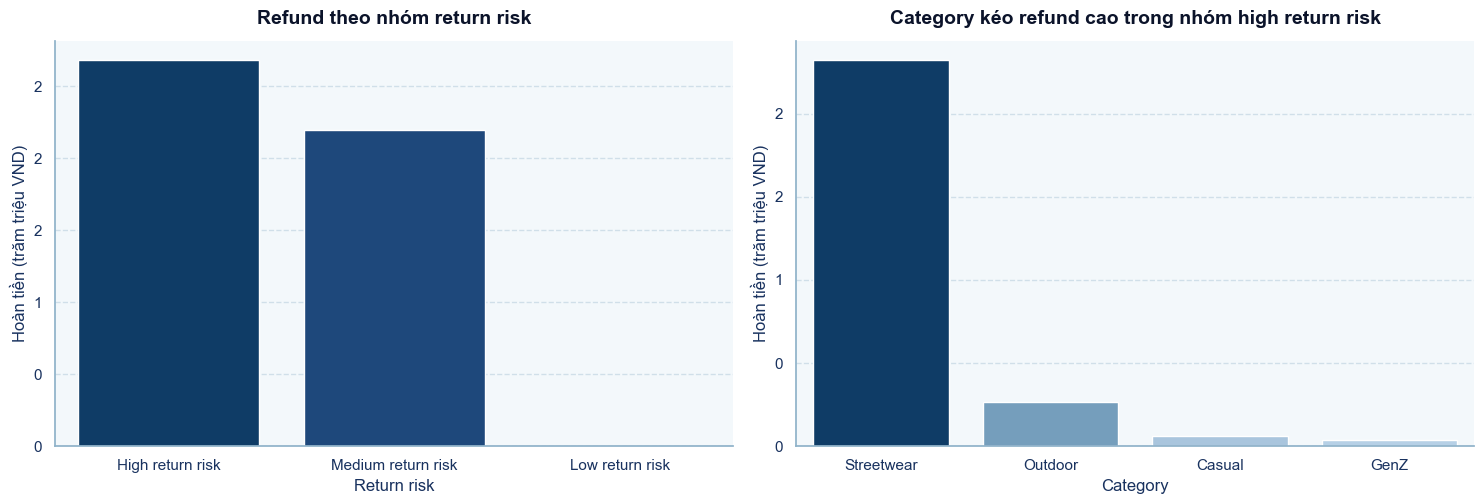

,category,net_revenue,gross_profit,refund_amount,refund_rate
3,Streetwear,9.8,-1.2,2.3,23.73%
2,Outdoor,1.9,-0.0,0.3,13.65%
0,Casual,0.4,-0.0,0.1,16.54%
1,GenZ,0.3,0.0,0.0,12.16%


,size,refund_amount
3,XL,0.9
0,L,0.6
2,S,0.6
1,M,0.6


In [382]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
plot_df = return_risk_summary.copy()
plot_df["return_risk_segment"] = plot_df["return_risk_segment"].astype(str)

sns.barplot(
    data=plot_df,
    x="return_risk_segment",
    y="refund_amount",
    palette=gradient_palette(plot_df["refund_amount"]),
    ax=axes[0],
)
clean_axis(
    axes[0],
    xlabel="Return risk",
    ylabel="Hoàn tiền (trăm triệu VND)",
    title="Refund theo nhóm return risk",
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].tick_params(axis="x")

sns.barplot(
    data=high_return_category_summary.head(6),
    x="category",
    y="refund_amount",
    palette=gradient_palette(high_return_category_summary.head(6)["refund_amount"]),
    ax=axes[1],
)
clean_axis(
    axes[1],
    xlabel="Category",
    ylabel="Hoàn tiền (trăm triệu VND)",
    title="Category kéo refund cao trong nhóm high return risk",
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[1].tick_params(axis="x")

plt.tight_layout()
plt.show()

display(
    high_return_category_summary.assign(
        net_revenue=lambda df: df["net_revenue"].map(format_hundred_millions),
        gross_profit=lambda df: df["gross_profit"].map(format_hundred_millions),
        refund_amount=lambda df: df["refund_amount"].map(format_hundred_millions),
        refund_rate=lambda df: df["refund_rate"].map(format_pct),
    )
)

display(
    high_return_size_summary.assign(
        refund_amount=lambda df: df["refund_amount"].map(format_hundred_millions)
    ).head(10)
)


**Insight - return là một nguyên nhân trực tiếp làm mỏng customer value**

- Nhóm `High return risk` chỉ gồm **7,969 khách hàng**, nhưng tạo refund tới **2.7 trăm triệu VND** và gross profit âm **1.2 trăm triệu VND**, với margin **-10.00%**. 
- Refund rate của nhóm này lên tới **21.67%**, cao hơn rất nhiều so với các nhóm còn lại.

- Điểm đáng chú ý là nhóm high return risk có tỷ trọng Streetwear rất cao. Khi drill-down theo category, **Streetwear là nguồn refund lớn nhất**, với **2.3 trăm triệu VND refund**, refund rate **23.73%** và gross profit âm **1.2 trăm triệu VND**. 
- Điều này khớp với Lớp 1: Streetwear không chỉ kéo margin âm ở cấp tháng, mà còn tạo rủi ro ở cấp khách hàng.

- Ở cấp size, **XL** là size có refund cao nhất. 
- Đây là tín hiệu đáng để kiểm tra sâu hơn về sizing, mô tả sản phẩm, kỳ vọng khách hàng hoặc fit guide.

-> Vì vậy, return không nên được xem là lỗi vận hành riêng lẻ. Với Streetwear, return đang là một phần của bài toán lợi nhuận và cần được đưa vào chiến lược giảm refund ở Lớp 3.

#### 4. RFM Analysis

RFM giúp trả lời nhóm khách nào có giá trị thật hiện còn active hay đã bắt đầu rời khỏi nhịp mua hàng?


In [383]:
def score_by_quantile(series: pd.Series, bins: int = 5, reverse: bool = False) -> pd.Series:
    ranked_pct = series.fillna(0).rank(method="average", pct=True)
    scores = np.ceil(ranked_pct * bins).astype(int).clip(1, bins)
    if reverse:
        scores = bins + 1 - scores
    return pd.Series(scores, index=series.index)


customer_fact["R_score"] = score_by_quantile(customer_fact["recency_days"], bins=5, reverse=True)
customer_fact["F_score"] = score_by_quantile(customer_fact["frequency"], bins=5)
customer_fact["M_score"] = score_by_quantile(customer_fact["monetary"], bins=5)
customer_fact["rfm_score"] = (
    customer_fact["R_score"].astype(str)
    + customer_fact["F_score"].astype(str)
    + customer_fact["M_score"].astype(str)
)


def assign_rfm_segment(row: pd.Series) -> str:
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Loyal Customers"
    if row["R_score"] >= 4 and row["M_score"] >= 3:
        return "Potential Loyalists"
    if row["R_score"] == 5 and row["F_score"] <= 2:
        return "New Customers"
    if row["R_score"] <= 2 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "At Risk"
    if row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Hibernating"
    return "Low Value"


rfm_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "At Risk",
    "Hibernating",
    "Low Value",
]
customer_fact["rfm_segment"] = customer_fact.apply(assign_rfm_segment, axis=1)

rfm_summary = (
    customer_fact.groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_margin=("gross_margin_after_refund", "mean"),
    )
)
rfm_summary["profit_margin_weighted"] = (
    rfm_summary["gross_profit_after_refund"]
    / rfm_summary["net_revenue_after_refund"].replace(0, np.nan)
)
rfm_summary["rfm_segment"] = pd.Categorical(
    rfm_summary["rfm_segment"],
    categories=rfm_order,
    ordered=True,
)
rfm_summary = rfm_summary.sort_values("rfm_segment").reset_index(drop=True)

display(
    rfm_summary.assign(
        customer_count=lambda df: df["customer_count"].map(format_number),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        avg_recency_days=lambda df: df["avg_recency_days"].round(1),
        avg_frequency=lambda df: df["avg_frequency"].round(2),
        avg_monetary=lambda df: df["avg_monetary"].map(format_hundred_millions),
        avg_margin=lambda df: df["avg_margin"].map(format_pct),
        profit_margin_weighted=lambda df: df["profit_margin_weighted"].map(format_pct),
    )
)


,rfm_segment,customer_count,net_revenue_after_refund,gross_profit_after_refund,avg_recency_days,avg_frequency,avg_monetary,avg_margin,profit_margin_weighted
0,Champions,"22,112",82.3,5.3,300.5,14.48,0.0,6.02%,6.43%
1,Loyal Customers,"15,812",26.0,1.6,846.3,6.68,0.0,5.50%,6.31%
2,Potential Loyalists,"1,423",1.3,0.1,375.2,1.73,0.0,5.51%,6.42%
3,New Customers,"1,361",0.3,0.0,158.0,1.43,0.0,1.49%,2.53%
4,At Risk,"7,261",9.9,0.7,1956.1,5.29,0.0,6.45%,6.86%
5,Hibernating,"24,697",7.4,0.5,2560.4,1.30,0.0,-10.97%,6.67%
6,Low Value,"13,069",4.8,0.2,1125.2,2.28,0.0,1.37%,3.85%


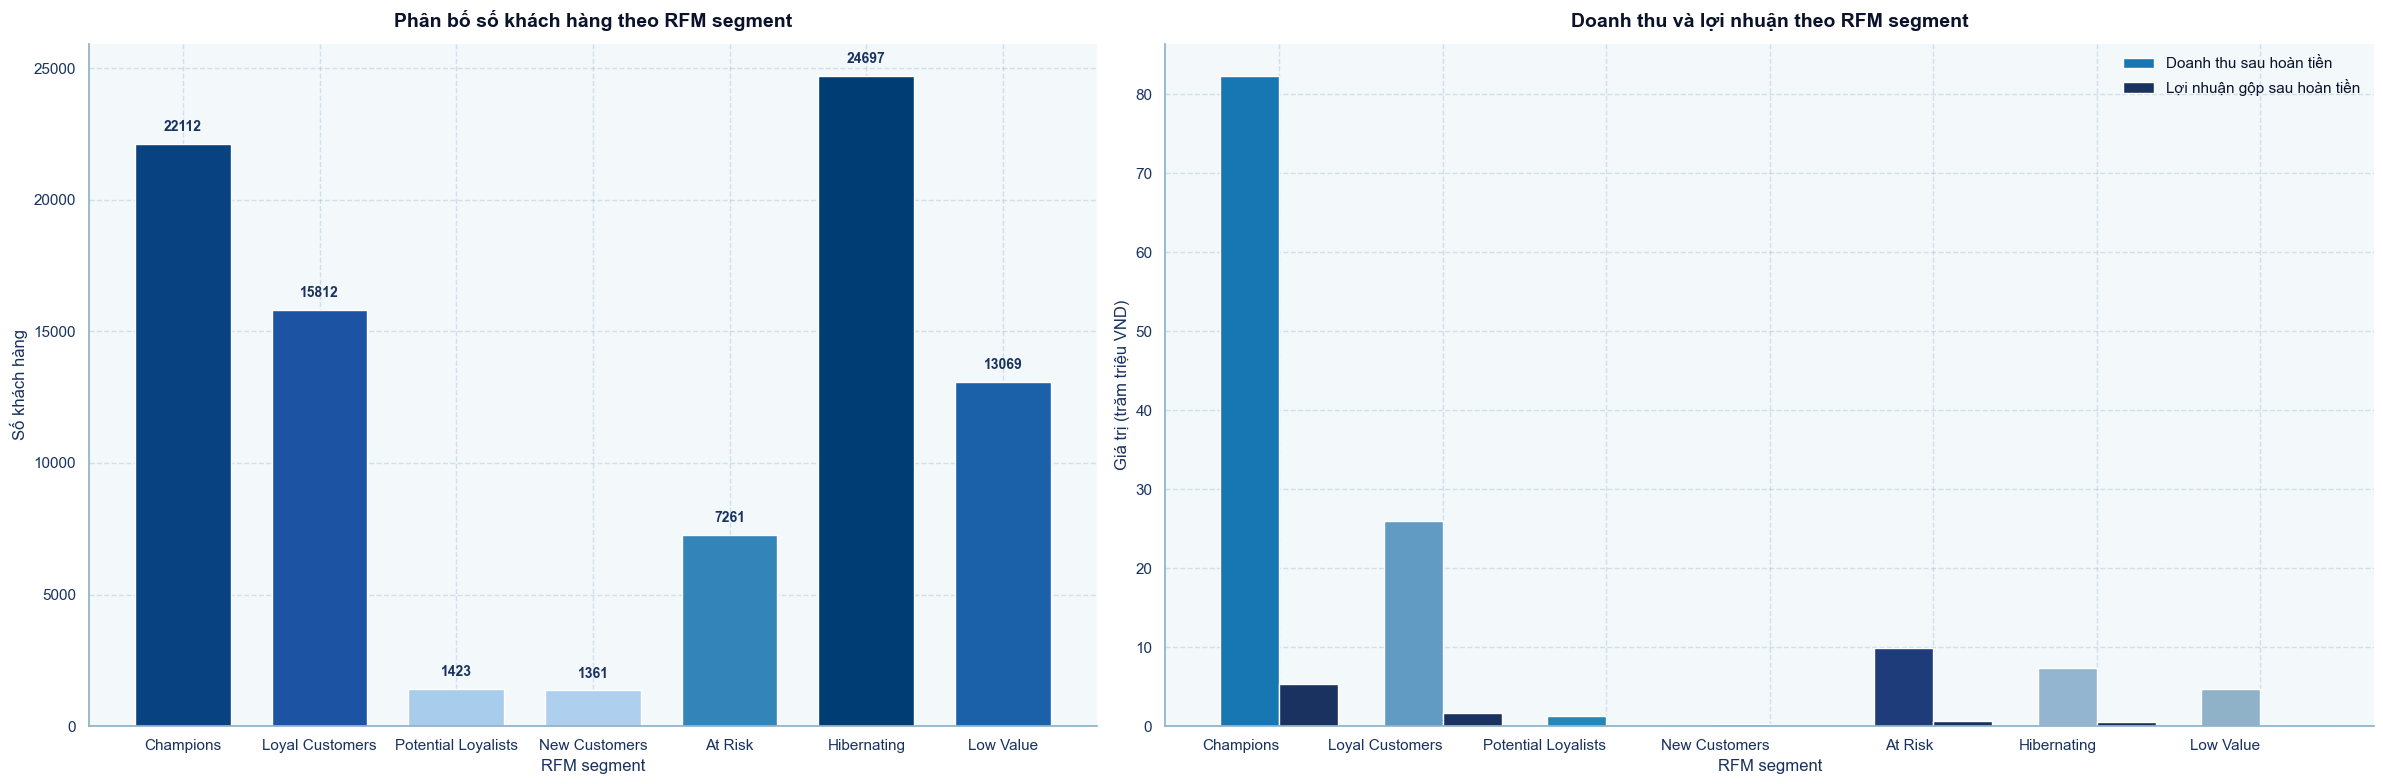

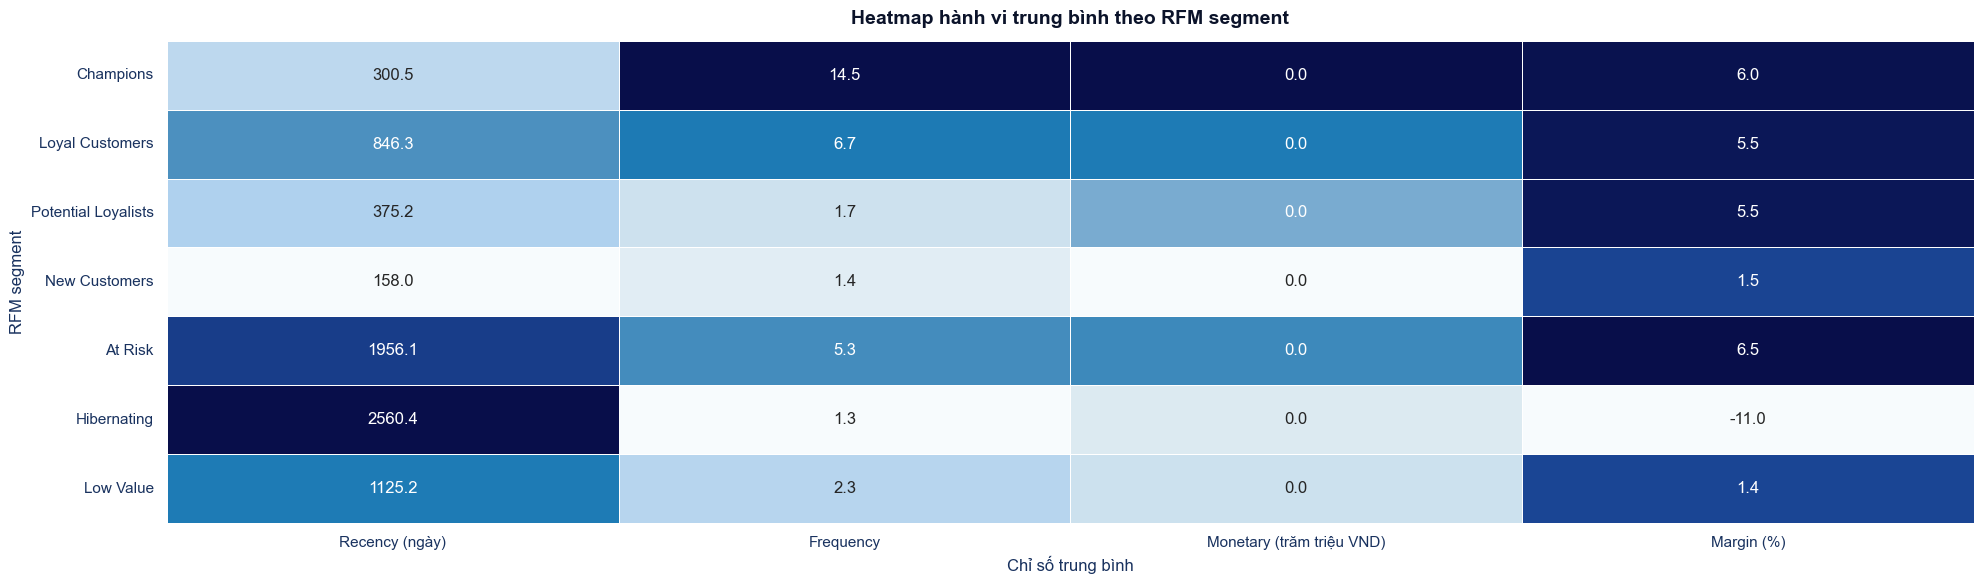

In [384]:
rfm_plot = rfm_summary.copy()
rfm_plot["rfm_segment"] = rfm_plot["rfm_segment"].astype(str)
rfm_count_colors = gradient_palette(rfm_plot["customer_count"])
rfm_revenue_colors = gradient_palette(rfm_plot["net_revenue_after_refund"])
rfm_x = np.arange(len(rfm_plot))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(24, 8), gridspec_kw={"width_ratios": [1, 1.2]})
axes[0].bar(rfm_plot["rfm_segment"], rfm_plot["customer_count"], color=rfm_count_colors, width=0.7)
clean_axis(
    axes[0],
    xlabel="RFM segment",
    ylabel="Số khách hàng",
    title="Phân bố số khách hàng theo RFM segment",
)
axes[0].tick_params(axis="x")
add_bar_labels(axes[0], fmt="{:.0f}")

axes[1].bar(
    rfm_x - bar_width / 2,
    rfm_plot["net_revenue_after_refund"],
    width=bar_width,
    color=rfm_colors,
    label="Doanh thu sau hoàn tiền",
)
axes[1].bar(
    rfm_x + bar_width / 2,
    rfm_plot["gross_profit_after_refund"],
    width=bar_width,
    color=PALETTE["dark_gray"],
    label="Lợi nhuận gộp sau hoàn tiền",
)
clean_axis(
    axes[1],
    xlabel="RFM segment",
    ylabel="Giá trị (trăm triệu VND)",
    title="Doanh thu và lợi nhuận theo RFM segment",
)
axes[1].set_xticks(rfm_x)
axes[1].set_xticklabels(rfm_plot["rfm_segment"], ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

rfm_heatmap = (
    customer_fact.groupby("rfm_segment")
    .agg(
        recency_days=("recency_days", "mean"),
        frequency=("frequency", "mean"),
        monetary=("monetary", "mean"),
        gross_margin_after_refund=("gross_margin_after_refund", "mean"),
    )
    .reindex(rfm_order)
)

rfm_heatmap_display = rfm_heatmap.assign(
    monetary=rfm_heatmap["monetary"] / 1e8,
    gross_margin_after_refund=rfm_heatmap["gross_margin_after_refund"] * 100,
)
rfm_heatmap_color = rfm_heatmap_display.apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
    if not np.isclose(col.max(), col.min())
    else 0.5,
    axis=0,
)

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(
    rfm_heatmap_color,
    annot=rfm_heatmap_display,
    fmt=".1f",
    cmap=MONO_CMAP,
    norm=mcolors.PowerNorm(gamma=0.60, vmin=0, vmax=1),
    linewidths=0.65,
    linecolor=PALETTE["white"],
    cbar=False,
    ax=ax,
)
clean_axis(
    ax,
    xlabel="Chỉ số trung bình",
    ylabel="RFM segment",
    title="Heatmap hành vi trung bình theo RFM segment",
)
ax.set_xticklabels([
    "Recency (ngày)",
    "Frequency",
    "Monetary (trăm triệu VND)",
    "Margin (%)",
])
plt.tight_layout()
plt.show()


**Insight - RFM giúp chọn đúng nhóm cần giữ chân và kéo lại**

- RFM cho thấy `Champions` là nhóm quan trọng nhất về giá trị hiện tại: **22,112 khách hàng** tạo **82.3 trăm triệu VND doanh thu** và **5.3 trăm triệu VND gross profit**. 
- Đây là nhóm có frequency cao nhất, trung bình **14.48 đơn/khách**, và recency thấp hơn nhiều nhóm khác, cho thấy họ vẫn còn tương đối gần với nhịp mua hàng.

- Tuy nhiên, không phải nhóm lâu chưa mua nào cũng nên win-back. `Hibernating` là nhóm lớn nhất với **24,697 khách hàng**, nhưng recency rất cao, trung bình **2,560 ngày**, và giá trị đóng góp thấp hơn nhiều. Nếu win-back đại trà vào nhóm này, chi phí marketing có thể bị lãng phí.

- Nhóm đáng chú ý hơn là `At Risk`: chỉ **7,261 khách hàng**, nhưng từng tạo **9.9 trăm triệu VND doanh thu** và **0.7 trăm triệu VND gross profit**, với frequency trung bình **5.29 đơn/khách**. 
- Đây là nhóm đã từng có hành vi mua thật, có giá trị lịch sử, nhưng đang rời xa doanh nghiệp.

-> Vì vậy, chiến lược retention không nên chia đơn giản thành “khách cũ” và “khách mới”. Nhóm cần ưu tiên là `Champions` để giữ chân, và `At Risk` có profit tốt để win-back trước khi họ trượt sang `Hibernating`.

#### 5. Retention / Cohort

Nếu RFM cho biết trạng thái hiện tại của customer base, thì cohort retention cho biết tốc độ khách quay lại và rời nhịp mua theo thời gian.




In [385]:
cohort_orders = customer_orders[["customer_id", "order_id", "order_date"]].copy()
cohort_orders["order_month"] = cohort_orders["order_date"].dt.to_period("M")

cohort = cohort_orders.groupby("customer_id")["order_month"].min().reset_index()
cohort.columns = ["customer_id", "cohort_month"]
cohort_orders = cohort_orders.merge(cohort, on="customer_id", how="left")
cohort_orders["cohort_index"] = (
    (cohort_orders["order_month"].dt.year - cohort_orders["cohort_month"].dt.year) * 12
    + (cohort_orders["order_month"].dt.month - cohort_orders["cohort_month"].dt.month)
    + 1
)

cohort_data = (
    cohort_orders.groupby(["cohort_month", "cohort_index"])["customer_id"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_id")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

customer_repeat_summary = customer_order_level_fact.groupby("customer_id", as_index=False).agg(
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
    order_count=("order_id", "nunique"),
)
customer_repeat_summary["is_repeat"] = customer_repeat_summary["order_count"] > 1
customer_repeat_summary["days_since_last_order"] = (
    customer_orders["order_date"].max() - customer_repeat_summary["last_order"]
).dt.days

order_rank = customer_order_level_fact.sort_values(["customer_id", "order_date", "order_id"]).copy()
order_rank["order_rank"] = order_rank.groupby("customer_id").cumcount() + 1
first_second_gap = (
    order_rank.loc[order_rank["order_rank"] <= 2, ["customer_id", "order_date", "order_rank"]]
    .pivot(index="customer_id", columns="order_rank", values="order_date")
    .rename(columns={1: "first_order_date", 2: "second_order_date"})
    .reset_index()
)
first_second_gap["days_to_second_order"] = (
    first_second_gap["second_order_date"] - first_second_gap["first_order_date"]
).dt.days

retention_summary = pd.DataFrame(
    {
        "metric": [
            "Repeat Purchase Rate",
            "One-time Buyer Rate",
            "Median Days Since Last Order",
            "Median Days To Second Order",
        ],
        "value": [
            customer_repeat_summary["is_repeat"].mean(),
            1 - customer_repeat_summary["is_repeat"].mean(),
            customer_repeat_summary["days_since_last_order"].median(),
            first_second_gap["days_to_second_order"].median(),
        ],
    }
)

display(retention_summary)


,metric,value
0,Repeat Purchase Rate,0.733773
1,One-time Buyer Rate,0.266227
2,Median Days Since Last Order,1111.000000
3,Median Days To Second Order,322.000000


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\3110710281.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


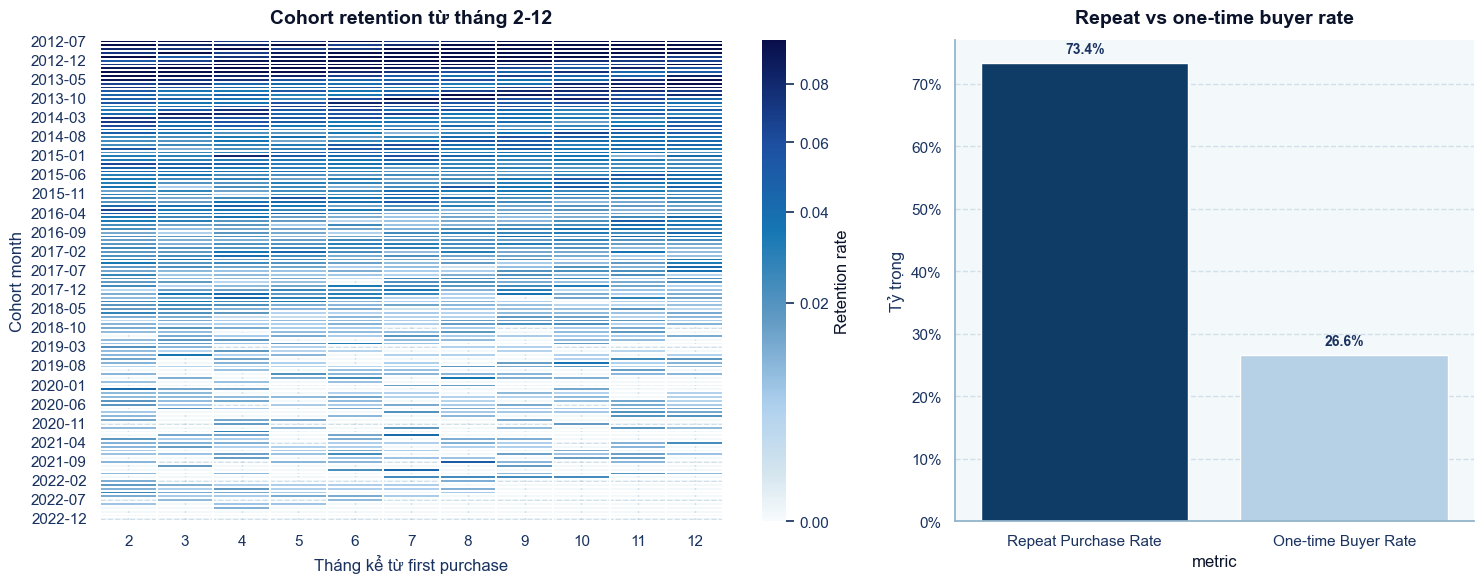

Median days to second order: 322.0


In [386]:
retention_plot = retention.iloc[:, 1:12]  

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.2, 0.8]})

retention_vmax = np.nanpercentile(retention_plot.values, 95)
sns.heatmap(
    retention_plot,
    cmap=MONO_CMAP,
    norm=mcolors.PowerNorm(gamma=0.50, vmin=0, vmax=retention_vmax),
    linewidths=0.35,
    linecolor=PALETTE["white"],
    ax=axes[0],
    cbar_kws={"label": "Retention rate"},
)

clean_axis(
    axes[0],
    xlabel="Tháng kể từ first purchase",
    ylabel="Cohort month",
    title="Cohort retention từ tháng 2-12",
)

repeat_plot = retention_summary.copy()
repeat_plot = repeat_plot.loc[
    repeat_plot["metric"].isin(["Repeat Purchase Rate", "One-time Buyer Rate"])
]

sns.barplot(
    data=repeat_plot,
    x="metric",
    y="value",
    palette=gradient_palette(repeat_plot["value"]),
    ax=axes[1],
)

clean_axis(
    axes[1],
    xlabel="",
    ylabel="Tỷ trọng",
    title="Repeat vs one-time buyer rate",
)

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
add_bar_labels(axes[1], fmt="{:.1%}")
axes[1].tick_params(axis="x")

plt.tight_layout()
plt.show()

print("Median days to second order:", first_second_gap["days_to_second_order"].median())

**Insight - repeat cao nhưng chu kỳ quay lại khá dài**

- Repeat purchase rate đạt **73.4%**, nghĩa là phần lớn khách hàng có quay lại sau lần mua đầu tiên. Đây là tín hiệu tích cực, cho thấy doanh nghiệp có nền tảng customer base đủ tốt để khai thác retention thay vì chỉ phụ thuộc vào khách mới.

- Tuy nhiên, median days to second order là **322 ngày**, cho thấy chu kỳ quay lại khá dài. Khách có mua lại, nhưng không quay lại nhanh. 
- Nếu doanh nghiệp chờ đến khi khách rơi vào nhóm `At Risk` hoặc `Hibernating` mới kích hoạt lại thì có thể đã quá muộn.

-> Vì vậy, insight chính không chỉ là “repeat rate cao”, mà là cần thiết kế win-back theo đúng thời điểm. Một mốc hợp lý là kích hoạt lại trước khi khách vượt quá chu kỳ mua lại trung vị, thay vì để họ im lặng quá lâu rồi mới chạy campaign.

#### 6. Customer-centric enrichments

Sau khi đã có backbone về value, discount, return và retention, phần cuối của Lớp 2 bổ sung các lát cắt để làm giàu insight: acquisition channel, first purchase category và khách mới so với khách quay lại.


,acquisition_channel,customers,repeat_rate,net_revenue_after_refund,gross_profit_after_refund,profit_per_customer,gross_margin
5,social_media,"17,101",73.93%,26.6,1.8,"10,321",6.64%
3,paid_search,"17,099",73.36%,26.2,1.7,"9,907",6.46%
0,direct,"6,949",73.38%,10.6,0.7,"9,626",6.33%
1,email_campaign,"10,329",72.37%,15.8,1.0,"9,624",6.30%
2,organic_search,"25,634",73.49%,39.7,2.5,"9,579",6.19%
4,referral,"8,623",73.20%,13.1,0.8,"9,262",6.09%


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\2342690456.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


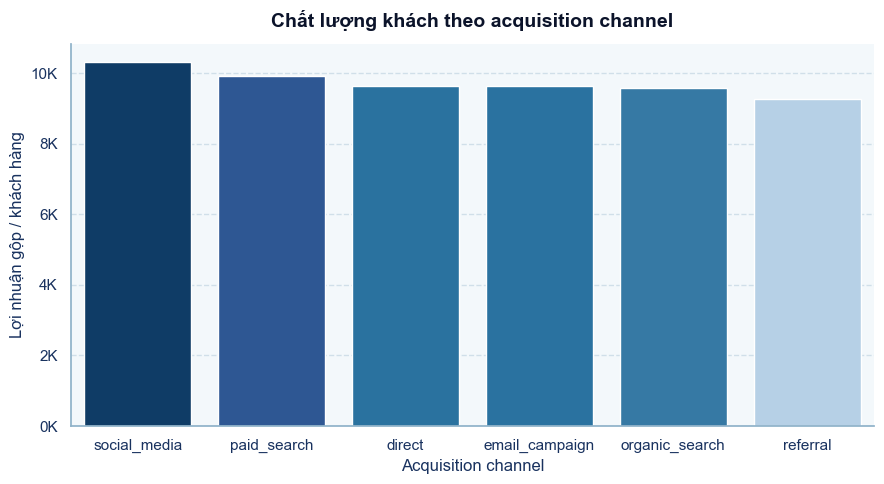

In [387]:
channel_summary = (
    customer_fact.groupby("acquisition_channel", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        repeat_rate=("frequency", lambda s: (s > 1).mean()),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
    )
)
channel_summary["profit_per_customer"] = (
    channel_summary["gross_profit_after_refund"]
    / channel_summary["customers"].replace(0, np.nan)
)
channel_summary["gross_margin"] = (
    channel_summary["gross_profit_after_refund"]
    / channel_summary["net_revenue_after_refund"].replace(0, np.nan)
)
channel_summary = channel_summary.sort_values("profit_per_customer", ascending=False)

display(
    channel_summary.assign(
        customers=lambda df: df["customers"].map(format_number),
        repeat_rate=lambda df: df["repeat_rate"].map(format_pct),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        profit_per_customer=lambda df: df["profit_per_customer"].map(format_currency),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
    )
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=channel_summary,
    x="acquisition_channel",
    y="profit_per_customer",
    palette=gradient_palette(channel_summary["profit_per_customer"]),
    ax=ax,
)
clean_axis(
    ax,
    xlabel="Acquisition channel",
    ylabel="Lợi nhuận gộp / khách hàng",
    title="Chất lượng khách theo acquisition channel",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))
ax.tick_params(axis="x")
plt.tight_layout()
plt.show()


**Insight - acquisition channel khác nhau không quá mạnh về margin, nhưng social media đang nhỉnh hơn về profit per customer**

- Ở cấp acquisition channel, các kênh có repeat rate khá gần nhau, quanh mức **72-74%**. Điều này cho thấy khác biệt lớn không nằm ở việc kênh nào kéo khách quay lại nhiều hơn, mà nằm ở chất lượng lợi nhuận trên mỗi khách.

- `social_media` đang có profit per customer cao nhất, khoảng **10,321 VND/khách**, đồng thời gross margin cũng nhỉnh hơn các kênh còn lại. 
- `paid_search` đứng sau với khoảng **9,907 VND/khách**. Trong khi đó. 
- `referral` thấp nhất về profit per customer.

Tuy nhiên, khoảng cách giữa các kênh không quá lớn, nên không nên kết luận vội rằng một kênh vượt trội hoàn toàn. Kênh acquisition nên được dùng như lát cắt hỗ trợ, còn quyết định marketing vẫn cần kết hợp với customer value, discount dependency và retention.

,first_category,customers,repeat_rate,net_revenue_after_refund,gross_profit_after_refund,avg_orders,profit_per_customer
2,Outdoor,"29,470",76.15%,43.7,2.6,6.67,"8,899"
3,Streetwear,"49,649",72.40%,80.4,5.3,6.02,"10,643"
1,GenZ,"4,211",71.67%,5.1,0.3,5.46,"7,507"
0,Casual,"2,405",62.49%,2.7,0.2,4.96,"6,384"


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\3082732491.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


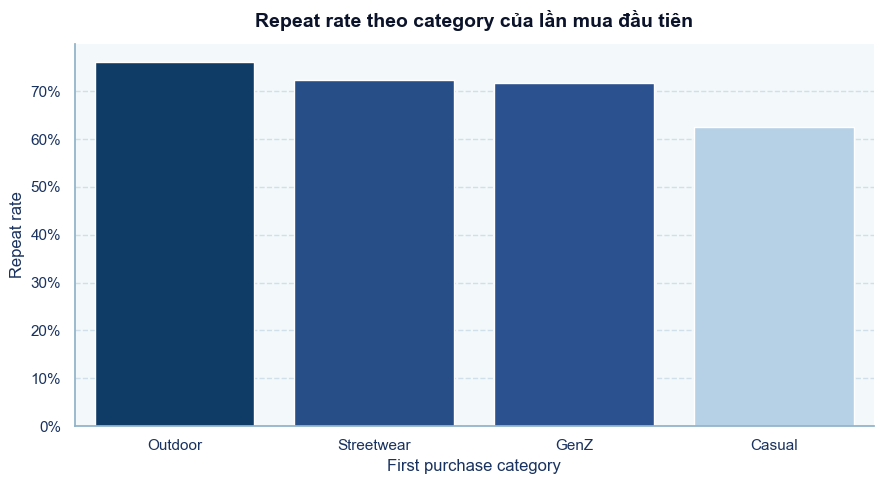

In [388]:
first_order_lookup = (
    customer_order_level_fact.sort_values(["customer_id", "order_date", "order_id"])
    .drop_duplicates("customer_id")[["customer_id", "order_id"]]
)

first_order_items = (
    customer_item_fact.merge(first_order_lookup, on=["customer_id", "order_id"], how="inner")
)
first_category = (
    first_order_items.groupby(["customer_id", "category"], as_index=False)["line_revenue"]
    .sum()
    .sort_values(["customer_id", "line_revenue"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"category": "first_category"})
)

customer_fact = customer_fact.drop(columns=["first_category"], errors="ignore").merge(
    first_category[["customer_id", "first_category"]],
    on="customer_id",
    how="left",
)

first_category_summary = (
    customer_fact.groupby("first_category", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        repeat_rate=("frequency", lambda s: (s > 1).mean()),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        avg_orders=("order_count", "mean"),
    )
)
first_category_summary["profit_per_customer"] = (
    first_category_summary["gross_profit_after_refund"]
    / first_category_summary["customers"].replace(0, np.nan)
)
first_category_summary = first_category_summary.sort_values("repeat_rate", ascending=False)

display(
    first_category_summary.assign(
        customers=lambda df: df["customers"].map(format_number),
        repeat_rate=lambda df: df["repeat_rate"].map(format_pct),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        avg_orders=lambda df: df["avg_orders"].round(2),
        profit_per_customer=lambda df: df["profit_per_customer"].map(format_currency),
    )
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=first_category_summary,
    x="first_category",
    y="repeat_rate",
    palette=gradient_palette(first_category_summary["repeat_rate"]),
    ax=ax,
)
clean_axis(
    ax,
    xlabel="First purchase category",
    ylabel="Repeat rate",
    title="Repeat rate theo category của lần mua đầu tiên",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
ax.tick_params(axis="x")
plt.tight_layout()
plt.show()


**Insight - first purchase category ảnh hưởng đến khả năng quay lại**

- First purchase category cho thấy trải nghiệm mua đầu tiên có liên quan đến repeat behavior. 
- `Outdoor` có repeat rate cao nhất, đạt **76.15%**, cho thấy đây có thể là nhóm sản phẩm mở đầu tốt để tạo thói quen mua lại.

- `Streetwear` có quy mô lớn nhất và profit per customer cao nhất, khoảng **10,643 VND/khách**, nhưng cần đọc cùng với rủi ro đã thấy ở Lớp 1 và phần Return Risk: Streetwear tạo nhiều doanh thu, nhưng cũng là category liên quan mạnh đến margin âm và refund.

- `Casual` có repeat rate thấp nhất, chỉ **62.49%**, cho thấy nhóm khách bắt đầu bằng Casual có khả năng quay lại yếu hơn. Đây có thể không phải category tốt nhất để làm entry point nếu mục tiêu là xây dựng repeat customer.

-> Vì vậy, first purchase category không chỉ là thông tin mô tả. Nó có thể dùng để thiết kế onboarding, cross-sell và ưu đãi lần mua thứ hai theo từng nhóm sản phẩm.

,customer_stage,revenue,gross_profit,customers,revenue_share,profit_share
0,Khách mới,20.6,2.5,"85,735",16.00%,20.13%
1,Khách quay lại,108.0,10.0,"62,349",84.00%,79.87%


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1047711860.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


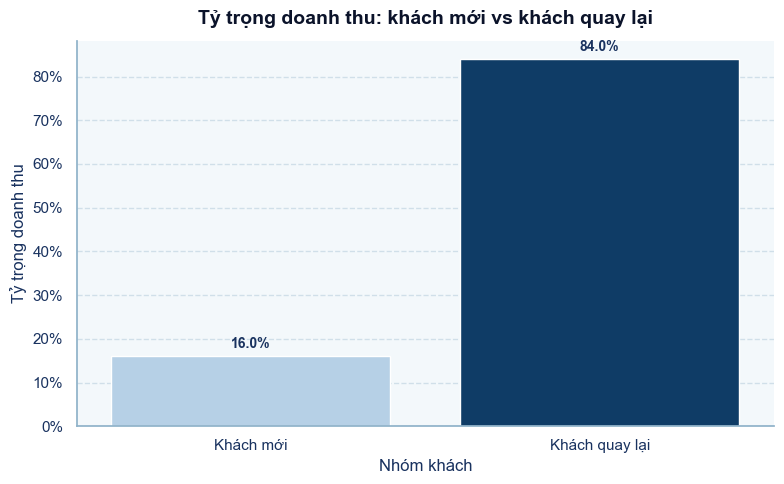

In [389]:
first_order_date_lookup = customer_order_level_fact.groupby("customer_id", as_index=False).agg(
    first_order_date=("order_date", "min")
)
new_returning_orders = customer_order_level_fact.merge(
    first_order_date_lookup,
    on="customer_id",
    how="left",
)
new_returning_orders["order_month"] = new_returning_orders["order_date"].dt.to_period("M").dt.to_timestamp()
new_returning_orders["first_order_month"] = new_returning_orders["first_order_date"].dt.to_period("M").dt.to_timestamp()
new_returning_orders["customer_stage"] = np.where(
    new_returning_orders["order_month"].eq(new_returning_orders["first_order_month"]),
    "Khách mới",
    "Khách quay lại",
)

new_vs_returning_summary = (
    new_returning_orders.groupby("customer_stage", as_index=False)
    .agg(
        revenue=("net_revenue_success", "sum"),
        gross_profit=("gross_profit_success", "sum"),
        customers=("customer_id", "nunique"),
    )
)
new_vs_returning_summary["revenue_share"] = (
    new_vs_returning_summary["revenue"]
    / new_vs_returning_summary["revenue"].sum()
)
new_vs_returning_summary["profit_share"] = (
    new_vs_returning_summary["gross_profit"]
    / new_vs_returning_summary["gross_profit"].sum()
)

display(
    new_vs_returning_summary.assign(
        revenue=lambda df: df["revenue"].map(format_hundred_millions),
        gross_profit=lambda df: df["gross_profit"].map(format_hundred_millions),
        customers=lambda df: df["customers"].map(format_number),
        revenue_share=lambda df: df["revenue_share"].map(format_pct),
        profit_share=lambda df: df["profit_share"].map(format_pct),
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=new_vs_returning_summary,
    x="customer_stage",
    y="revenue_share",
    palette=gradient_palette(new_vs_returning_summary["revenue_share"]),
    ax=ax,
)
clean_axis(
    ax,
    xlabel="Nhóm khách",
    ylabel="Tỷ trọng doanh thu",
    title="Tỷ trọng doanh thu: khách mới vs khách quay lại",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
add_bar_labels(ax, fmt="{:.1%}")
plt.tight_layout()
plt.show()


**Insight - tăng trưởng đang phụ thuộc lớn vào khách quay lại**

- Khách quay lại tạo **84.0% doanh thu** và gần **79.9% gross profit**, trong khi khách mới chỉ đóng góp **16.0% doanh thu**. Điều này cho thấy phần lớn giá trị kinh doanh đến từ customer base hiện có, không phải từ khách mới.

- Đây là một tín hiệu quan trọng cho chiến lược marketing: doanh nghiệp không nên chỉ tập trung acquisition. Nếu retention giảm hoặc nhóm khách quay lại bị kéo vào discount-heavy / return-heavy behavior, chất lượng lợi nhuận sẽ bị ảnh hưởng rất nhanh.

-> Vì vậy, Lớp 3 nên ưu tiên các chiến lược giữ chân, kích hoạt lại và tăng chất lượng đơn hàng từ khách hiện có trước khi mở rộng mạnh acquisition.

#### 7. Region & Web Traffic Drill-down

Sau các lát cắt customer-centric, phần này bổ sung hai nguồn tín hiệu còn thiếu:

- **Region:** vùng nào tạo doanh thu, gross profit, margin, refund và repeat tốt nhất? Đây là lát cắt quan trọng để ưu tiên market, fulfillment và regional campaign.
- **Web traffic:** traffic source nào tạo volume, engagement và có liên hệ với doanh thu/order trend? Đây là cầu nối giữa acquisition ở đầu funnel và chất lượng khách hàng ở downstream.

Cách đọc chính trong case này không nên chỉ là traffic nhiều hay region nhiều đơn, mà là **traffic/region nào chuyển hóa thành revenue có margin tốt, ít refund và có repeat**.


,region,customers,orders,net_revenue_after_refund,gross_profit_after_refund,refund_amount,repeat_rate,avg_orders,avg_discount_rate,gross_margin,refund_rate,profit_per_customer
0,East,"42,650","241,669",61.4,3.8,2.2,75.56%,5.666331,4.92%,6.24%,3.66%,"8,979"
1,Central,"28,954","151,264",39.6,2.4,1.4,68.06%,5.224287,4.94%,6.14%,3.57%,"8,403"
2,West,"14,131","137,545",30.9,2.1,1.2,77.70%,9.733565,4.95%,6.83%,3.92%,"14,957"


C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1652370108.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reust\AppData\Local\Temp\ipykernel_65204\1652370108.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


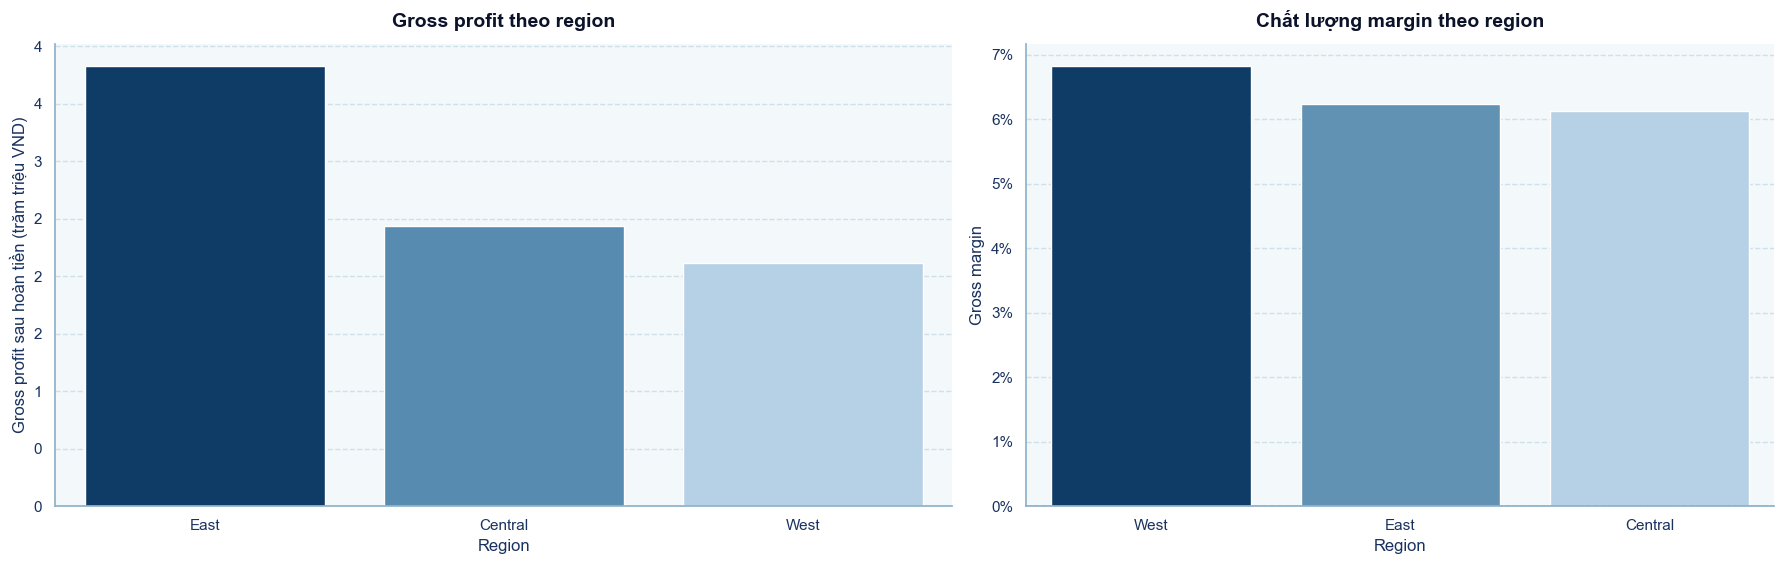

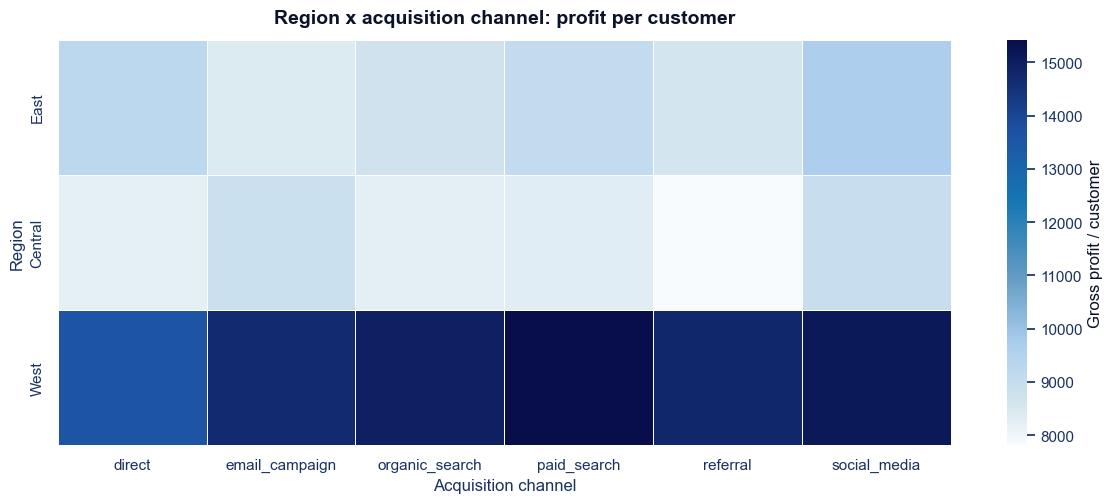

Region tạo gross profit cao nhất: East | gross profit: 3.8 trăm triệu VND | margin: 6.24%
Region có margin tốt nhất: West | margin: 6.83% | profit/customer: 14,957


In [390]:
customer_geo_fact = (
    customer_fact.merge(
        customers[["customer_id", "zip", "city", "acquisition_channel"]],
        on=["customer_id", "acquisition_channel"],
        how="left",
    )
    .merge(
        geography[["zip", "region", "district"]].drop_duplicates("zip"),
        on="zip",
        how="left",
    )
)
customer_geo_fact["region"] = customer_geo_fact["region"].fillna("Unknown")
customer_geo_fact["district"] = customer_geo_fact["district"].fillna("Unknown")

region_summary = (
    customer_geo_fact.groupby("region", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_count", "sum"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
        refund_amount=("refund_amount", "sum"),
        repeat_rate=("frequency", lambda s: (s > 1).mean()),
        avg_orders=("order_count", "mean"),
        avg_discount_rate=("discount_rate", "mean"),
    )
)
region_summary["gross_margin"] = (
    region_summary["gross_profit_after_refund"]
    / region_summary["net_revenue_after_refund"].replace(0, np.nan)
)
region_summary["refund_rate"] = (
    region_summary["refund_amount"]
    / region_summary["net_revenue_after_refund"].replace(0, np.nan)
)
region_summary["profit_per_customer"] = (
    region_summary["gross_profit_after_refund"]
    / region_summary["customers"].replace(0, np.nan)
)
region_summary = region_summary.sort_values("gross_profit_after_refund", ascending=False).reset_index(drop=True)

display(
    region_summary.assign(
        customers=lambda df: df["customers"].map(format_number),
        orders=lambda df: df["orders"].map(format_number),
        net_revenue_after_refund=lambda df: df["net_revenue_after_refund"].map(format_hundred_millions),
        gross_profit_after_refund=lambda df: df["gross_profit_after_refund"].map(format_hundred_millions),
        refund_amount=lambda df: df["refund_amount"].map(format_hundred_millions),
        repeat_rate=lambda df: df["repeat_rate"].map(format_pct),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
        refund_rate=lambda df: df["refund_rate"].map(format_pct),
        profit_per_customer=lambda df: df["profit_per_customer"].map(format_currency),
        avg_discount_rate=lambda df: df["avg_discount_rate"].map(format_pct),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5.8), gridspec_kw={"width_ratios": [1.2, 1]})
sns.barplot(
    data=region_summary,
    x="region",
    y="gross_profit_after_refund",
    palette=gradient_palette(region_summary["gross_profit_after_refund"]),
    ax=axes[0],
)
clean_axis(
    axes[0],
    xlabel="Region",
    ylabel="Gross profit sau hoàn tiền (trăm triệu VND)",
    title="Gross profit theo region",
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(axis_tram_trieu))
axes[0].tick_params(axis="x", rotation=0)

sns.barplot(
    data=region_summary.sort_values("gross_margin", ascending=False),
    x="region",
    y="gross_margin",
    palette=gradient_palette(region_summary.sort_values("gross_margin", ascending=False)["gross_margin"]),
    ax=axes[1],
)
clean_axis(
    axes[1],
    xlabel="Region",
    ylabel="Gross margin",
    title="Chất lượng margin theo region",
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
axes[1].axhline(0, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

region_channel = (
    customer_geo_fact.groupby(["region", "acquisition_channel"], as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        net_revenue_after_refund=("net_revenue_after_refund", "sum"),
        gross_profit_after_refund=("gross_profit_after_refund", "sum"),
    )
)
region_channel["profit_per_customer"] = (
    region_channel["gross_profit_after_refund"]
    / region_channel["customers"].replace(0, np.nan)
)
region_channel_pivot = region_channel.pivot(
    index="region",
    columns="acquisition_channel",
    values="profit_per_customer",
).reindex(region_summary["region"])

fig, ax = plt.subplots(figsize=(12, 5.2))
sns.heatmap(
    region_channel_pivot,
    cmap=MONO_CMAP,
    robust=True,
    linewidths=0.45,
    linecolor=PALETTE["white"],
    ax=ax,
    cbar_kws={"label": "Gross profit / customer"},
)
clean_axis(
    ax,
    xlabel="Acquisition channel",
    ylabel="Region",
    title="Region x acquisition channel: profit per customer",
)
plt.tight_layout()
plt.show()

best_region = region_summary.iloc[0]
best_margin_region = region_summary.sort_values("gross_margin", ascending=False).iloc[0]
print(
    "Region tạo gross profit cao nhất:",
    best_region["region"],
    "| gross profit:", format_hundred_millions(best_region["gross_profit_after_refund"]),
    "trăm triệu VND | margin:", format_pct(best_region["gross_margin"]),
)
print(
    "Region có margin tốt nhất:",
    best_margin_region["region"],
    "| margin:", format_pct(best_margin_region["gross_margin"]),
    "| profit/customer:", format_currency(best_margin_region["profit_per_customer"]),
)


**Insight - West nhỏ hơn về quy mô nhưng tốt hơn về chất lượng lợi nhuận**

- Ba chart này cho thấy một nghịch lý quan trọng ở cấp region. `East` là vùng đóng góp **gross profit tuyệt đối cao nhất**, nghĩa là xét theo tổng tiền giữ lại thì East vẫn là thị trường lớn nhất. Tuy nhiên, khi chuyển sang góc nhìn hiệu suất, `West` lại có **gross margin cao nhất**, gần 7%.

- Điều này cho thấy `West` không phải vùng lớn nhất về tổng quy mô, nhưng mỗi đồng doanh thu ở West đang giữ lại được nhiều lợi nhuận hơn. Nói cách khác, West là vùng **nhỏ nhưng có chất lượng lợi nhuận tốt hơn**.

- Heatmap `Region x acquisition channel` đào sâu thêm điều này ở cấp tổ hợp vùng-kênh. Hàng `West` đậm hơn rõ rệt ở hầu hết acquisition channel, đặc biệt các kênh digital như `email_campaign`, `organic_search`, `paid_search`, `referral` và `social_media`. Điều đó có nghĩa là khách hàng ở West tạo **gross profit per customer** cao hơn nhiều so với East và Central, thường vượt mức 15,000 VND/khách ở các kênh tốt.

- Ngược lại, `East` có gross profit tổng cao nhất nhưng profit per customer và margin không nổi bật bằng West. Đây có thể là dấu hiệu East đang thắng nhờ volume lớn, nhưng chất lượng unit economics bị kéo xuống bởi discount, refund, fulfillment cost proxy hoặc mix khách/kênh chưa tối ưu.

- chiến lược: không nên chỉ scale East vì East đang lớn nhất. Nếu doanh nghiệp có thể tăng thêm lượng khách ở West thông qua các kênh digital đang có profit/customer cao, tổng gross profit có thể tăng tốt hơn vì mỗi khách mới ở West đang mang lại giá trị cao hơn. Với East, ưu tiên nên là tối ưu margin và refund/discount; với Central, cần xem lại channel mix vì nhiều ô trong heatmap còn khá nhạt.


,traffic_source,sessions,session_share,bounce_rate,avg_session_duration_sec,pages_per_session,customers,customers_per_10k_sessions,repeat_rate,profit_per_customer,gross_margin
0,organic_search,"27,196,976",29.74%,0.45%,211.1,4.32,"25,634",9.43,73.49%,"9,579",6.19%
1,paid_search,"19,598,271",21.43%,0.45%,208.3,4.34,"17,099",8.72,73.36%,"9,907",6.46%
2,social_media,"15,816,226",17.29%,0.45%,211.0,4.30,"17,101",10.81,73.93%,"10,321",6.64%
3,email_campaign,"12,792,670",13.99%,0.44%,212.5,4.34,"10,329",8.07,72.37%,"9,624",6.30%
4,referral,"9,476,845",10.36%,0.45%,205.9,4.40,"8,623",9.10,73.20%,"9,262",6.09%
5,direct,"6,571,549",7.19%,0.45%,206.1,4.38,"6,949",10.57,73.38%,"9,626",6.33%


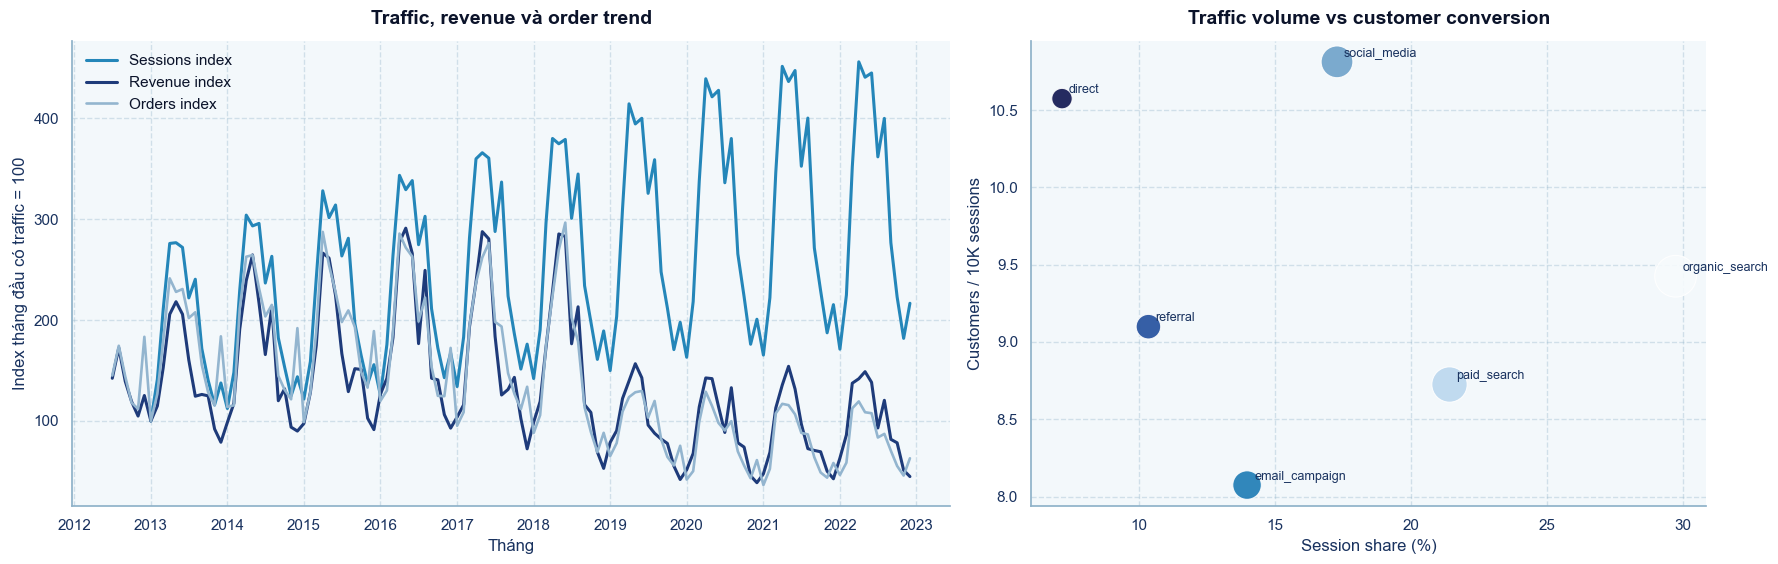

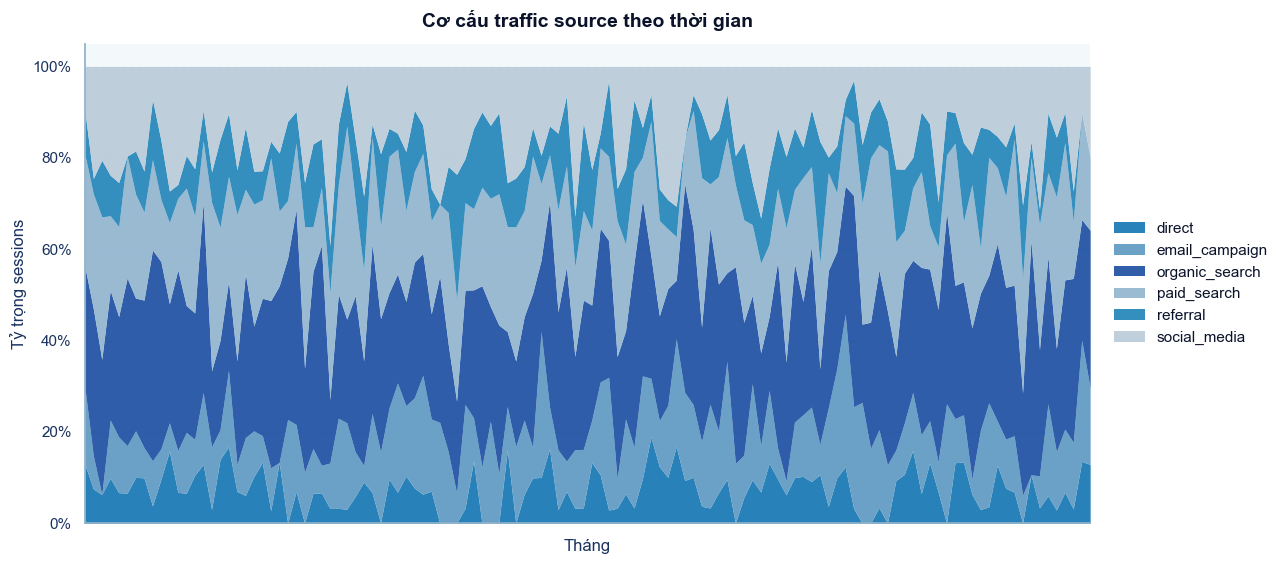

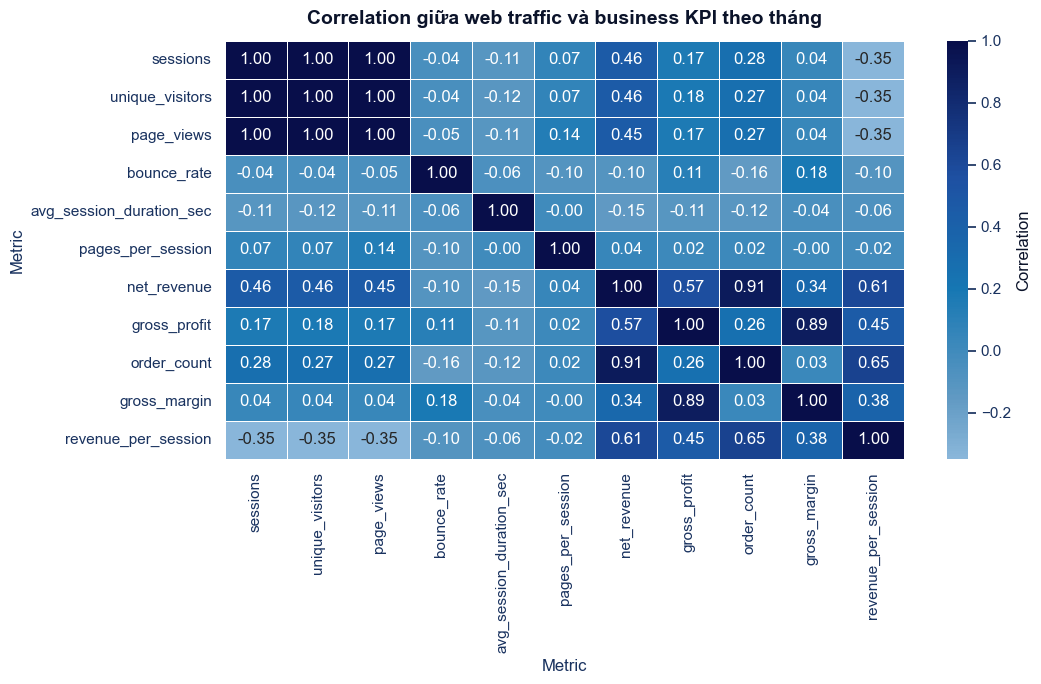

Traffic source có volume lớn nhất: organic_search | session share: 29.74% | profit/customer: 9,579
Traffic source có profit/customer tốt nhất: social_media | profit/customer: 10,321 | repeat rate: 73.93%


In [391]:
web_traffic_enriched = web_traffic.copy()
web_traffic_enriched["date"] = pd.to_datetime(web_traffic_enriched["date"])
web_traffic_enriched["year_month"] = web_traffic_enriched["date"].dt.to_period("M").dt.to_timestamp()
web_traffic_enriched["weighted_bounce"] = (
    web_traffic_enriched["bounce_rate"] * web_traffic_enriched["sessions"]
)
web_traffic_enriched["weighted_duration"] = (
    web_traffic_enriched["avg_session_duration_sec"] * web_traffic_enriched["sessions"]
)

monthly_traffic = (
    web_traffic_enriched.groupby("year_month", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        weighted_bounce=("weighted_bounce", "sum"),
        weighted_duration=("weighted_duration", "sum"),
    )
)
monthly_traffic["bounce_rate"] = monthly_traffic["weighted_bounce"] / monthly_traffic["sessions"].replace(0, np.nan)
monthly_traffic["avg_session_duration_sec"] = monthly_traffic["weighted_duration"] / monthly_traffic["sessions"].replace(0, np.nan)
monthly_traffic["pages_per_session"] = monthly_traffic["page_views"] / monthly_traffic["sessions"].replace(0, np.nan)

traffic_business = monthly_business.merge(
    monthly_traffic[["year_month", "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec", "pages_per_session"]],
    on="year_month",
    how="left",
)
traffic_business["revenue_per_session"] = traffic_business["net_revenue"] / traffic_business["sessions"].replace(0, np.nan)
traffic_baseline = traffic_business.loc[traffic_business["sessions"].notna()].iloc[0]
traffic_business["sessions_index"] = traffic_business["sessions"] / traffic_baseline["sessions"] * 100
traffic_business["revenue_index"] = traffic_business["net_revenue"] / traffic_baseline["net_revenue"] * 100
traffic_business["orders_index"] = traffic_business["order_count"] / traffic_baseline["order_count"] * 100

source_traffic = (
    web_traffic_enriched.groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        weighted_bounce=("weighted_bounce", "sum"),
        weighted_duration=("weighted_duration", "sum"),
    )
)
source_traffic["session_share"] = source_traffic["sessions"] / source_traffic["sessions"].sum()
source_traffic["bounce_rate"] = source_traffic["weighted_bounce"] / source_traffic["sessions"].replace(0, np.nan)
source_traffic["avg_session_duration_sec"] = source_traffic["weighted_duration"] / source_traffic["sessions"].replace(0, np.nan)
source_traffic["pages_per_session"] = source_traffic["page_views"] / source_traffic["sessions"].replace(0, np.nan)
source_traffic = source_traffic.sort_values("sessions", ascending=False).reset_index(drop=True)

traffic_channel_quality = source_traffic.merge(
    channel_summary.rename(columns={"acquisition_channel": "traffic_source"}),
    on="traffic_source",
    how="left",
)
traffic_channel_quality["customers_per_10k_sessions"] = (
    traffic_channel_quality["customers"] / traffic_channel_quality["sessions"].replace(0, np.nan) * 10000
)

display(
    traffic_channel_quality[[
        "traffic_source",
        "sessions",
        "session_share",
        "bounce_rate",
        "avg_session_duration_sec",
        "pages_per_session",
        "customers",
        "customers_per_10k_sessions",
        "repeat_rate",
        "profit_per_customer",
        "gross_margin",
    ]].assign(
        sessions=lambda df: df["sessions"].map(format_number),
        session_share=lambda df: df["session_share"].map(format_pct),
        bounce_rate=lambda df: df["bounce_rate"].map(format_pct),
        avg_session_duration_sec=lambda df: df["avg_session_duration_sec"].round(1),
        pages_per_session=lambda df: df["pages_per_session"].round(2),
        customers=lambda df: df["customers"].map(format_number),
        customers_per_10k_sessions=lambda df: df["customers_per_10k_sessions"].round(2),
        repeat_rate=lambda df: df["repeat_rate"].map(format_pct),
        profit_per_customer=lambda df: df["profit_per_customer"].map(format_currency),
        gross_margin=lambda df: df["gross_margin"].map(format_pct),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5.8), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].plot(
    traffic_business["year_month"],
    traffic_business["sessions_index"],
    color=BLUE_SHADES[5],
    linewidth=2.2,
    label="Sessions index",
)
axes[0].plot(
    traffic_business["year_month"],
    traffic_business["revenue_index"],
    color=BLUE_SHADES[8],
    linewidth=2.2,
    label="Revenue index",
)
axes[0].plot(
    traffic_business["year_month"],
    traffic_business["orders_index"],
    color=BLUE_SHADES[3],
    linewidth=1.9,
    label="Orders index",
)
clean_axis(
    axes[0],
    xlabel="Tháng",
    ylabel="Index tháng đầu có traffic = 100",
    title="Traffic, revenue và order trend",
)
axes[0].xaxis.set_major_locator(mdates.YearLocator(1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend(frameon=False)

scatter_df = traffic_channel_quality.copy()
scatter_sizes = np.clip(scatter_df["sessions"] / scatter_df["sessions"].max() * 900, 180, 900)
axes[1].scatter(
    scatter_df["session_share"] * 100,
    scatter_df["customers_per_10k_sessions"],
    s=scatter_sizes,
    c=range(len(scatter_df)),
    cmap=MONO_CMAP,
    alpha=0.88,
    edgecolor=PALETTE["white"],
    linewidth=0.8,
)
for _, row in scatter_df.iterrows():
    axes[1].annotate(
        row["traffic_source"],
        (row["session_share"] * 100, row["customers_per_10k_sessions"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
        color=PALETTE["dark_gray"],
    )
clean_axis(
    axes[1],
    xlabel="Session share (%)",
    ylabel="Customers / 10K sessions",
    title="Traffic volume vs customer conversion",
)
plt.tight_layout()
plt.show()

source_monthly = (
    web_traffic_enriched.groupby(["year_month", "traffic_source"], as_index=False)["sessions"].sum()
)
source_mix = source_monthly.pivot(index="year_month", columns="traffic_source", values="sessions").fillna(0)
source_mix_share = source_mix.div(source_mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 5.8))
source_mix_share.plot.area(
    ax=ax,
    color=MONO_SEQUENCE[: len(source_mix_share.columns)],
    linewidth=0,
    alpha=0.92,
)
clean_axis(
    ax,
    xlabel="Tháng",
    ylabel="Tỷ trọng sessions",
    title="Cơ cấu traffic source theo thời gian",
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0%}"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

traffic_corr = traffic_business[[
    "sessions",
    "unique_visitors",
    "page_views",
    "bounce_rate",
    "avg_session_duration_sec",
    "pages_per_session",
    "net_revenue",
    "gross_profit",
    "order_count",
    "gross_margin",
    "revenue_per_session",
]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    traffic_corr,
    cmap=MONO_CMAP,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.45,
    linecolor=PALETTE["white"],
    ax=ax,
    cbar_kws={"label": "Correlation"},
)
clean_axis(
    ax,
    xlabel="Metric",
    ylabel="Metric",
    title="Correlation giữa web traffic và business KPI theo tháng",
)
plt.tight_layout()
plt.show()

best_source = traffic_channel_quality.sort_values("profit_per_customer", ascending=False).iloc[0]
volume_source = traffic_channel_quality.sort_values("sessions", ascending=False).iloc[0]
print(
    "Traffic source có volume lớn nhất:",
    volume_source["traffic_source"],
    "| session share:", format_pct(volume_source["session_share"]),
    "| profit/customer:", format_currency(volume_source["profit_per_customer"]),
)
print(
    "Traffic source có profit/customer tốt nhất:",
    best_source["traffic_source"],
    "| profit/customer:", format_currency(best_source["profit_per_customer"]),
    "| repeat rate:", format_pct(best_source["repeat_rate"]),
)


**Insight - traffic nhiều chưa chắc chuyển đổi tốt**

- Chart `Traffic, revenue và order trend` dùng index để so sánh ba đường trên cùng một thang đo. Nếu sessions tăng nhanh hơn revenue hoặc orders, điều đó cho thấy tăng traffic chưa chắc chuyển hóa tương ứng thành doanh thu/đơn hàng.

- Scatter `Traffic volume vs customer conversion` với trục X thể hiện tỷ trọng traffic của từng source, trục Y thể hiện số khách hàng tạo ra trên mỗi 10,000 sessions, còn kích thước bubble thể hiện tổng sessions. Vì vậy, chart này đọc được cả **volume** và **conversion efficiency**.

- Source nằm càng sang phải là source kéo nhiều traffic hơn. Source nằm càng cao là source chuyển traffic thành customer tốt hơn. Nếu một source nằm bên phải nhưng thấp, đó là kênh có volume lớn nhưng conversion yếu; nếu nằm cao dù không quá lớn, đó là kênh đáng tối ưu hoặc scale có kiểm soát.

- Điểm quan trọng là web traffic nên được đọc như đầu funnel, còn acquisition/customer metrics là downstream quality. Vì vậy không nên dùng lại profit/customer theo channel ở đây; thay vào đó nên hỏi: source nào kéo traffic, source nào chuyển thành customer, và source nào sau đó tạo khách có repeat/margin tốt.


## Tổng kết Lớp 2 - Customer insight

Lớp 2 cho thấy doanh nghiệp không thiếu khách hàng quay lại, nhưng giá trị khách hàng không đồng đều. Vấn đề không còn là “ai mua nhiều nhất”, mà là **ai tạo ra doanh thu có lợi nhuận, ai cần được giữ chân, và ai đang làm mỏng margin**.

Có năm nhóm vấn đề chính cần chuyển sang Lớp 3:

1. **Giữ chân nhóm khách hàng chất lượng cao**  
   Nhóm high revenue - high margin và Champions là tệp cần ưu tiên bảo vệ, vì đây là nhóm vừa tạo doanh thu, vừa giữ lại lợi nhuận tốt.

2. **Kéo lại khách từng có giá trị nhưng đang rời xa**  
   Không nên win-back đại trà. Nhóm At Risk có lịch sử mua và tạo profit tốt nên được ưu tiên hơn nhóm Hibernating quá lâu chưa quay lại.

3. **Kiểm soát nhóm phụ thuộc discount**  
   Discount có thể kéo volume nhưng không đảm bảo lợi nhuận. Cần chuyển từ giảm giá đại trà sang ưu đãi có điều kiện, cá nhân hóa hoặc loyalty-based.

4. **Giảm rủi ro return, đặc biệt ở Streetwear và size rủi ro**  
   Return/refund không chỉ là vấn đề hậu bán hàng, mà là một nguyên nhân trực tiếp làm giảm customer value và kéo margin xuống.

Vì vậy, Lớp 3 sẽ chuyển từ insight sang hành động: thiết kế chiến lược giữ chân, win-back, kiểm soát discount và giảm return risk theo từng nhóm khách hàng cụ thể.

### Lớp 3 - Action Playbook theo phân khúc

Lớp 3 không mở thêm một nhánh phân tích mới, mà chuyển các kết luận của Lớp 1-2 thành các hướng hành động có thể triển khai.

Năm vấn đề cần được xử lý là:

- giữ chân nhóm khách đang tạo gross profit tốt,
- kéo lại nhóm từng có giá trị nhưng đang rời xa,
- giảm phụ thuộc vào discount ở nhóm làm mỏng margin,
- giảm return/refund ở Streetwear và các size rủi ro.

Vì vậy, mỗi play bên dưới sẽ được trình bày theo cùng một logic: target group, business problem, action logic, KPI và cách nối sang kiểm chứng ở Lớp 4.

#### 1. Inner Circle - Giữ chân nhóm khách hàng giá trị cao

**Target group**
- `High Revenue - High Margin`
- `Champions` và nhóm mua lặp lại có return thấp

**Business problem**
- Đây là nhóm tạo doanh thu và gross profit tốt nhất.
- Nếu giữ nhóm này bằng discount sâu, doanh nghiệp có thể tự làm mỏng margin của chính tệp khách tốt.

**Action logic**
- Dùng loyalty-based benefit thay cho broad discount.
- Ưu tiên early access trước peak season, freeship, quà nhỏ, bundle margin tốt và gợi ý sản phẩm cá nhân hóa.
- Chọn khách vào nhóm dựa trên gross profit, tần suất mua và mức độ ít return.

#### 2. Come Back With Style - Kéo lại khách At Risk có giá trị

**Target group**
- `At Risk` có gross profit dương
- Ưu tiên khách từng mua lặp lại hoặc từng có AOV tốt

**Business problem**
- Đây không phải nhóm khách kém giá trị, mà là nhóm từng mua tốt nhưng đang rời khỏi nhịp mua.
- Nếu kéo lại đúng nhóm này, doanh nghiệp có thể tăng doanh thu mà không phải mở rộng acquisition đại trà.

**Action logic**
- Không win-back toàn bộ khách im lặng, mà lọc nhóm `At Risk` có lịch sử profit dương.
- Cá nhân hóa theo category đã mua, mức độ profit lịch sử và rủi ro return.
- Ưu tiên voucher có điều kiện, freeship hoặc điểm thành viên thay vì giảm phần trăm sâu.
- Không đẩy lại đúng sản phẩm hoặc size đã từng gây return cao.

#### 3. Smart Deal, Not Big Sale - Kiểm soát nhóm phụ thuộc discount

**Target group**
- `High discount dependency`
- `High Revenue - Low Margin`

**Business problem**
- Nhóm này vẫn tạo doanh thu lớn nhưng gần như không giữ được lợi nhuận.
- Nếu tiếp tục broad promotion, doanh nghiệp có thể tăng volume nhưng không tăng gross profit.

**Action logic**
- Giảm phụ thuộc vào giảm giá phần trăm trên toàn danh mục.
- Chuyển sang threshold offer, bundle, loyalty point hoặc freeship có điều kiện để tăng AOV và giữ margin.
- Không giảm sâu các category hoặc SKU đang có margin âm, đặc biệt khi liên quan đến Streetwear.
- Đánh giá campaign theo gross profit và promo order share, không chỉ theo doanh thu.


#### 4. Find Your Fit - Giảm return cho Streetwear và size rủi ro

**Target group**
- Khách mua Streetwear
- Nhóm có return risk cao hoặc từng refund cao
- Các size và SKU có tỷ lệ return nổi bật

**Business problem**
- Streetwear là category kéo margin âm mạnh nhất trong các tháng rủi ro.
- Refund tập trung vào một số size và sản phẩm nhất định, nên không nên xử lý như một vấn đề chung cho toàn danh mục.

**Action logic**
- Giảm return bằng cách giảm sai kỳ vọng trước mua: size guide rõ hơn, fit label, ảnh mẫu mặc và review về form dáng.
- Gắn cảnh báo ở size hoặc SKU có lịch sử return cao.
- Với khách từng return Streetwear, ưu tiên gợi ý sản phẩm ít rủi ro hơn hoặc nhắc kiểm tra size trước khi đặt.


#### 5. Second Look - Kéo khách mới sang lần mua thứ hai

**Target group**
- Khách mới và one-time buyers
- Ưu tiên theo first purchase category

**Business problem**
- Phần lớn giá trị hiện đến từ khách quay lại, nên đơn đầu tiên chỉ là bước mở đầu chứ chưa phải giá trị kinh tế đầy đủ.
- Repeat rate cao nhưng median days to second order khá dài, nên cần can thiệp sớm hơn để rút ngắn chu kỳ quay lại.

**Action logic**
- Thiết kế post-purchase journey theo category đầu tiên khách đã mua.
- Dùng nội dung hướng dẫn chọn size, gợi ý phối hợp sản phẩm và ưu đãi nhẹ cho lần mua thứ hai.
- Nếu first purchase là Outdoor, ưu tiên cross-sell sớm hơn vì repeat tốt.
- Nếu first purchase là Streetwear, gắn thêm fit guide để vừa hỗ trợ repeat vừa giảm return.


### Tóm tắt Lớp 3

| Vấn đề từ Lớp 1-2 | Chương trình đề xuất | Làm cụ thể |
|---|---|---|
| Khách tốt cần được giữ chân | Inner Circle | Loyalty-based benefit, early access, freeship, bundle margin tốt |
| Khách từng có giá trị đang rời xa | Come Back With Style | Win-back theo lịch sử mua, voucher có điều kiện, tránh broad discount |
| Discount làm mỏng margin | Smart Deal, Not Big Sale | Threshold offer, bundle, loyalty point, đo theo gross profit |
| Streetwear refund cao | Find Your Fit | Size guide, fit label, cảnh báo size/SKU rủi ro, giảm sai kỳ vọng |
| Khách mới cần mua lần hai | Second Look | Post-purchase journey, cross-sell theo first category, ưu đãi nhẹ cho đơn hai |

### Lớp 4 - Impact Simulation

Lớp 4 không nhằm dự báo chính xác kết quả campaign, vì notebook không có A/B test, CAC, chi phí triển khai hoặc dữ liệu uplift thực tế. Thay vào đó, phần này mô phỏng tác động kinh doanh nếu các chương trình ở Lớp 3 tạo ra cải thiện ở một số mức giả định.

Mỗi kịch bản sẽ đi theo cùng một logic:

1. Xác định nhóm target từ Lớp 2.
2. Lấy baseline hiện tại: số khách, revenue/customer, gross profit/customer, discount hoặc refund.
3. Đặt giả định cải thiện thấp, trung bình và cao.
4. Tính incremental revenue hoặc incremental gross profit.
5. So sánh các kịch bản để ưu tiên hành động.

Cần lưu ý:

- Đây là scenario simulation, không phải bằng chứng nhân quả.
- Kết quả nên được hiểu là business case ban đầu, không phải cam kết kết quả chắc chắn.
- Một số công thức dùng xấp xỉ đơn giản, nên có thể phóng đại hoặc đánh giá thấp impact thực tế.
- Các mô phỏng chưa trừ đầy đủ CAC, chi phí vận hành, chi phí quà tặng hoặc chi phí xử lý return nếu dữ liệu chưa có.

**Lớp 4 sẽ kiểm chứng 5 câu hỏi impact:**

1. **Nếu giữ thêm high-value customers, gross profit tăng bao nhiêu?**  
   Lưu ý: kịch bản này dùng profit per customer hiện tại làm baseline, nên kết quả phản ánh giá trị được giữ lại thêm, không phải dự báo hành vi mua mới.

2. **Nếu win-back nhóm At Risk có profit tốt, revenue/profit tăng bao nhiêu?**  
   Lưu ý: nên dùng AOV hoặc profit của một lần mua quay lại, thay vì full lifetime value lịch sử, để tránh phóng đại impact.

3. **Nếu giảm discount ở nhóm discount-heavy, margin cải thiện bao nhiêu?**  
   Lưu ý: kịch bản này có tính đến khả năng revenue giảm một phần khi giảm discount, nhưng chưa mô hình hóa đầy đủ độ nhạy của nhu cầu với khuyến mãi.

4. **Nếu giảm refund ở Streetwear, doanh nghiệp giữ lại thêm bao nhiêu profit?**  
   Lưu ý: incremental profit được xem xấp xỉ refund saving, chưa trừ thêm handling cost, reverse logistics hoặc markdown khi bán lại hàng hoàn.

5. **Nếu tăng second purchase của khách mới, revenue/profit tăng bao nhiêu?**  
   Lưu ý: median time to second order hiện khá dài, nên các mốc can thiệp sớm là giả thuyết vận hành cần kiểm chứng thêm, không phải pattern chắc chắn đã được xác nhận hoàn toàn từ dữ liệu.

In [392]:
scenario_labels = ["Low", "Base", "High"]


def format_count(value):
    if pd.isna(value):
        return "N/A"
    if abs(value - round(value)) < 1e-9:
        return f"{int(round(value)):,.0f}"
    return f"{value:,.1f}"


def make_scenario_table(rate_col, rates):
    return pd.DataFrame({"scenario": scenario_labels, rate_col: rates})


def display_scenario_table(df, money_cols=None, pct_cols=None, count_cols=None):
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    count_cols = count_cols or []

    display_df = df.copy()
    for col in money_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].map(format_hundred_millions)
    for col in pct_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].map(format_pct)
    for col in count_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].map(format_count)
    display(display_df)


#### 1. Mô phỏng giữ thêm high-value customers

Giả định chương trình `Inner Circle` giúp giữ lại thêm một phần nhóm `High Revenue - High Margin`. Impact được đo bằng gross profit giữ lại thêm trên mỗi khách hàng mục tiêu.


In [393]:
high_value = customer_fact.loc[
    customer_fact["customer_value_segment"].eq("High Revenue - High Margin")
].copy()

high_value_customers = high_value["customer_id"].nunique()
high_value_profit_per_customer = (
    high_value["gross_profit_after_refund"].sum() / high_value_customers
    if high_value_customers
    else np.nan
)

vip_baseline = pd.DataFrame(
    {
        "Baseline": [
            "Số khách hàng target",
            "Gross profit / khách hàng",
            "Gross profit toàn nhóm",
        ],
        "Giá trị": [
            format_number(high_value_customers),
            format_hundred_millions(high_value_profit_per_customer),
            format_hundred_millions(high_value["gross_profit_after_refund"].sum()),
        ],
    }
)
display(vip_baseline)

vip_impact = make_scenario_table("retention_uplift", [0.03, 0.05, 0.10])
vip_impact["retained_customers"] = (
    high_value_customers * vip_impact["retention_uplift"]
)
vip_impact["incremental_gross_profit"] = (
    vip_impact["retained_customers"] * high_value_profit_per_customer
)

display_scenario_table(
    vip_impact,
    money_cols=["incremental_gross_profit"],
    pct_cols=["retention_uplift"],
    count_cols=["retained_customers"],
)


,Baseline,Giá trị
0,Số khách hàng target,"21,570"
1,Gross profit / khách hàng,0.0
2,Gross profit toàn nhóm,8.6


,scenario,retention_uplift,retained_customers,incremental_gross_profit
0,Low,3.00%,647.1,0.3
1,Base,5.00%,"1,078.5",0.4
2,High,10.00%,"2,157",0.9


#### 2. Mô phỏng win-back nhóm At Risk có profit

Giả định chương trình `Come Back With Style` kéo lại được một phần nhóm `At Risk` có gross profit dương. Để tránh phóng đại impact, baseline dùng giá trị của một order quay lại như một proxy, không dùng full lifetime value lịch sử.


In [394]:
profitable_at_risk = customer_fact.loc[
    customer_fact["rfm_segment"].eq("At Risk")
    & customer_fact["gross_profit_after_refund"].gt(0)
].copy()

at_risk_customers = profitable_at_risk["customer_id"].nunique()
at_risk_order_revenue_proxy = (
    profitable_at_risk["net_revenue_after_refund"].sum()
    / profitable_at_risk["order_count"].sum()
    if profitable_at_risk["order_count"].sum()
    else np.nan
)
at_risk_margin_proxy = (
    profitable_at_risk["gross_profit_after_refund"].sum()
    / profitable_at_risk["net_revenue_after_refund"].sum()
    if profitable_at_risk["net_revenue_after_refund"].sum()
    else np.nan
)
at_risk_profit_per_reactivated_order = (
    at_risk_order_revenue_proxy * at_risk_margin_proxy
    if pd.notna(at_risk_order_revenue_proxy)
    else np.nan
)

winback_baseline = pd.DataFrame(
    {
        "Baseline": [
            "Số khách hàng At Risk có profit",
            "Revenue proxy / order quay lại",
            "Margin proxy của order quay lại",
            "Gross profit proxy / order quay lại",
        ],
        "Giá trị": [
            format_number(at_risk_customers),
            format_hundred_millions(at_risk_order_revenue_proxy),
            format_pct(at_risk_margin_proxy),
            format_hundred_millions(at_risk_profit_per_reactivated_order),
        ],
    }
)
display(winback_baseline)

winback_impact = make_scenario_table("winback_rate", [0.03, 0.05, 0.08])
winback_impact["reactivated_customers"] = (
    at_risk_customers * winback_impact["winback_rate"]
)
winback_impact["incremental_revenue"] = (
    winback_impact["reactivated_customers"] * at_risk_order_revenue_proxy
)
winback_impact["incremental_gross_profit"] = (
    winback_impact["reactivated_customers"]
    * at_risk_profit_per_reactivated_order
)

display_scenario_table(
    winback_impact,
    money_cols=["incremental_revenue", "incremental_gross_profit"],
    pct_cols=["winback_rate"],
    count_cols=["reactivated_customers"],
)


,Baseline,Giá trị
0,Số khách hàng At Risk có profit,"5,277"
1,Revenue proxy / order quay lại,0.0
2,Margin proxy của order quay lại,13.43%
3,Gross profit proxy / order quay lại,0.0


,scenario,winback_rate,reactivated_customers,incremental_revenue,incremental_gross_profit
0,Low,3.00%,158.3,0.0,0.0
1,Base,5.00%,263.9,0.1,0.0
2,High,8.00%,422.2,0.1,0.0


#### 3. Mô phỏng giảm discount ở nhóm discount-heavy

Giả định `Smart Deal, Not Big Sale` giúp giảm discount ở nhóm `High discount dependency`, nhưng doanh thu có thể giảm nhẹ ở các mức khác nhau. Impact được đọc ở dạng thay đổi profit ròng, không chỉ ở top-line.


In [395]:
discount_heavy = customer_fact.loc[
    customer_fact["discount_dependency_segment"].eq("High discount dependency")
].copy()

discount_heavy_revenue = discount_heavy["net_revenue_after_refund"].sum()
discount_heavy_discount = discount_heavy["discount_amount"].sum()
discount_heavy_profit = discount_heavy["gross_profit_after_refund"].sum()
discount_heavy_margin = (
    discount_heavy_profit / discount_heavy_revenue
    if discount_heavy_revenue
    else np.nan
)

discount_baseline = pd.DataFrame(
    {
        "Baseline": [
            "Revenue hiện tại của nhóm discount-heavy",
            "Discount amount hiện tại",
            "Gross profit hiện tại",
            "Gross margin hiện tại",
        ],
        "Giá trị": [
            format_hundred_millions(discount_heavy_revenue),
            format_hundred_millions(discount_heavy_discount),
            format_hundred_millions(discount_heavy_profit),
            format_pct(discount_heavy_margin),
        ],
    }
)
display(discount_baseline)

discount_impact = pd.DataFrame(
    {
        "scenario": scenario_labels,
        "discount_reduction_rate": [0.05, 0.10, 0.15],
        "revenue_loss_rate": [0.00, 0.03, 0.05],
    }
)
discount_impact["discount_saving"] = (
    discount_heavy_discount * discount_impact["discount_reduction_rate"]
)
discount_impact["profit_effect_from_revenue_drop"] = (
    discount_heavy_revenue
    * discount_impact["revenue_loss_rate"]
    * discount_heavy_margin
)
discount_impact["net_profit_impact"] = (
    discount_impact["discount_saving"]
    - discount_impact["profit_effect_from_revenue_drop"]
)

display_scenario_table(
    discount_impact,
    money_cols=[
        "discount_saving",
        "profit_effect_from_revenue_drop",
        "net_profit_impact",
    ],
    pct_cols=["discount_reduction_rate", "revenue_loss_rate"],
)


,Baseline,Giá trị
0,Revenue hiện tại của nhóm discount-heavy,48.0
1,Discount amount hiện tại,4.0
2,Gross profit hiện tại,-0.2
3,Gross margin hiện tại,-0.49%


,scenario,discount_reduction_rate,revenue_loss_rate,discount_saving,profit_effect_from_revenue_drop,net_profit_impact
0,Low,5.00%,0.00%,0.2,-0.0,0.2
1,Base,10.00%,3.00%,0.4,-0.0,0.4
2,High,15.00%,5.00%,0.6,-0.0,0.6


#### 4. Mô phỏng giảm refund ở Streetwear

Giả định `Find Your Fit` giúp giảm refund ở Streetwear. Impact được đọc như phần profit giữ lại thêm, với lưu ý đây là xấp xỉ ở cấp refund saving chứ chưa trừ đủ chi phí xử lý hậu cần.


In [396]:
streetwear_financial = financial_order_line_fact.loc[
    financial_order_line_fact["category"].eq("Streetwear")
].copy()

streetwear_revenue = streetwear_financial["line_revenue"].sum()
streetwear_refund = streetwear_financial["allocated_refund_amount"].sum()
streetwear_profit = streetwear_financial["line_gross_profit"].sum()
streetwear_refund_rate = (
    streetwear_refund / streetwear_financial["line_revenue_before_refund"].sum()
    if streetwear_financial["line_revenue_before_refund"].sum()
    else np.nan
)

streetwear_baseline = pd.DataFrame(
    {
        "Baseline": [
            "Net revenue Streetwear",
            "Refund amount Streetwear",
            "Gross profit Streetwear",
            "Refund rate Streetwear",
        ],
        "Giá trị": [
            format_hundred_millions(streetwear_revenue),
            format_hundred_millions(streetwear_refund),
            format_hundred_millions(streetwear_profit),
            format_pct(streetwear_refund_rate),
        ],
    }
)
display(streetwear_baseline)

streetwear_refund_impact = make_scenario_table(
    "refund_reduction_rate",
    [0.05, 0.10, 0.20],
)
streetwear_refund_impact["refund_saving"] = (
    streetwear_refund * streetwear_refund_impact["refund_reduction_rate"]
)
streetwear_refund_impact["incremental_gross_profit"] = (
    streetwear_refund_impact["refund_saving"]
)
streetwear_refund_impact["revised_streetwear_gross_profit"] = (
    streetwear_profit + streetwear_refund_impact["incremental_gross_profit"]
)

display_scenario_table(
    streetwear_refund_impact,
    money_cols=[
        "refund_saving",
        "incremental_gross_profit",
        "revised_streetwear_gross_profit",
    ],
    pct_cols=["refund_reduction_rate"],
)


,Baseline,Giá trị
0,Net revenue Streetwear,105.8
1,Refund amount Streetwear,4.1
2,Gross profit Streetwear,6.1
3,Refund rate Streetwear,3.70%


,scenario,refund_reduction_rate,refund_saving,incremental_gross_profit,revised_streetwear_gross_profit
0,Low,5.00%,0.2,0.2,6.3
1,Base,10.00%,0.4,0.4,6.5
2,High,20.00%,0.8,0.8,7.0


#### 5. Mô phỏng tăng second purchase của khách mới

Giả định `Second Look` giúp tăng thêm tỷ lệ chuyển từ đơn đầu sang đơn thứ hai. Baseline dùng one-time buyers hiện tại và giá trị trung bình của second order thực tế như một proxy cho đơn quay lại.


In [397]:
ranked_customer_orders = customer_order_level_fact.sort_values(
    ["customer_id", "order_date", "order_id"]
).copy()
ranked_customer_orders["order_rank"] = (
    ranked_customer_orders.groupby("customer_id").cumcount() + 1
)

second_order_fact = ranked_customer_orders.loc[
    ranked_customer_orders["order_rank"].eq(2)
].copy()
one_time_buyers = customer_fact.loc[customer_fact["frequency"].eq(1)].copy()

one_time_buyer_count = one_time_buyers["customer_id"].nunique()
second_purchase_rate_baseline = (customer_fact["frequency"] > 1).mean()
avg_second_order_revenue = second_order_fact["net_revenue_success"].mean()
avg_second_order_margin = (
    second_order_fact["gross_profit_success"].sum()
    / second_order_fact["net_revenue_success"].sum()
    if second_order_fact["net_revenue_success"].sum()
    else np.nan
)

second_purchase_baseline = pd.DataFrame(
    {
        "Baseline": [
            "Số one-time buyers hiện tại",
            "Repeat purchase rate hiện tại",
            "Revenue trung bình của second order",
            "Margin trung bình của second order",
            "Median days to second order",
        ],
        "Giá trị": [
            format_number(one_time_buyer_count),
            format_pct(second_purchase_rate_baseline),
            format_hundred_millions(avg_second_order_revenue),
            format_pct(avg_second_order_margin),
            format_number(first_second_gap["days_to_second_order"].median()),
        ],
    }
)
display(second_purchase_baseline)

second_purchase_impact = make_scenario_table(
    "second_purchase_uplift_point",
    [0.02, 0.05, 0.08],
)
second_purchase_impact["additional_second_buyers"] = (
    one_time_buyer_count * second_purchase_impact["second_purchase_uplift_point"]
)
second_purchase_impact["incremental_revenue"] = (
    second_purchase_impact["additional_second_buyers"] * avg_second_order_revenue
)
second_purchase_impact["incremental_gross_profit"] = (
    second_purchase_impact["incremental_revenue"] * avg_second_order_margin
)

display_scenario_table(
    second_purchase_impact,
    money_cols=["incremental_revenue", "incremental_gross_profit"],
    pct_cols=["second_purchase_uplift_point"],
    count_cols=["additional_second_buyers"],
)


,Baseline,Giá trị
0,Số one-time buyers hiện tại,"22,825"
1,Repeat purchase rate hiện tại,73.38%
2,Revenue trung bình của second order,0.0
3,Margin trung bình của second order,10.23%
4,Median days to second order,322


,scenario,second_purchase_uplift_point,additional_second_buyers,incremental_revenue,incremental_gross_profit
0,Low,2.00%,456.5,0.1,0.0
1,Base,5.00%,"1,141.2",0.3,0.0
2,High,8.00%,"1,826",0.4,0.0


#### So sánh kịch bản Base giữa 5 hướng hành động

Bảng dưới lấy kịch bản `Base` của từng play để so sánh nhanh impact profit ước tính. Đây không phải ranking cuối cùng, nhưng đủ để nhìn hướng nào có tiềm năng business case lớn hơn trước khi đi vào thử nghiệm thực tế.


In [398]:
layer4_base_case_summary = pd.DataFrame(
    {
        "play": [
            "Inner Circle",
            "Come Back With Style",
            "Smart Deal, Not Big Sale",
            "Find Your Fit",
            "Second Look",
        ],
        "target": [
            "High Revenue - High Margin",
            "At Risk có profit dương",
            "High discount dependency",
            "Streetwear",
            "One-time buyers",
        ],
        "base_scenario_rate": [
            vip_impact.loc[1, "retention_uplift"],
            winback_impact.loc[1, "winback_rate"],
            discount_impact.loc[1, "discount_reduction_rate"],
            streetwear_refund_impact.loc[1, "refund_reduction_rate"],
            second_purchase_impact.loc[1, "second_purchase_uplift_point"],
        ],
        "incremental_revenue_proxy": [
            np.nan,
            winback_impact.loc[1, "incremental_revenue"],
            np.nan,
            np.nan,
            second_purchase_impact.loc[1, "incremental_revenue"],
        ],
        "estimated_profit_impact": [
            vip_impact.loc[1, "incremental_gross_profit"],
            winback_impact.loc[1, "incremental_gross_profit"],
            discount_impact.loc[1, "net_profit_impact"],
            streetwear_refund_impact.loc[1, "incremental_gross_profit"],
            second_purchase_impact.loc[1, "incremental_gross_profit"],
        ],
    }
).sort_values("estimated_profit_impact", ascending=False)

display_scenario_table(
    layer4_base_case_summary,
    money_cols=["incremental_revenue_proxy", "estimated_profit_impact"],
    pct_cols=["base_scenario_rate"],
)


,play,target,base_scenario_rate,incremental_revenue_proxy,estimated_profit_impact
0,Inner Circle,High Revenue - High Margin,5.00%,N/A,0.4
3,Find Your Fit,Streetwear,10.00%,N/A,0.4
2,"Smart Deal, Not Big Sale",High discount dependency,10.00%,N/A,0.4
4,Second Look,One-time buyers,5.00%,0.3,0.0
1,Come Back With Style,At Risk có profit dương,5.00%,0.1,0.0


## Tổng hợp kết quả kiểm thử giả định ở Lớp 4

Lớp 4 cho thấy các hướng hành động không tạo impact giống nhau. Với kịch bản Base, ba chương trình có tác động gross profit mạnh nhất là **Inner Circle**, **Find Your Fit** và **Smart Deal, Not Big Sale** — đều đạt khoảng **0.4 trăm triệu VND** profit impact.

Điểm chung của ba hướng này là chúng không cố tạo thêm doanh thu bằng mọi giá, mà tập trung vào **giữ lại lợi nhuận tốt hơn**:

- **Inner Circle:** giữ thêm 5% nhóm `High Revenue - High Margin`, giúp bảo vệ nhóm khách tạo profit tốt nhất.
- **Find Your Fit:** giảm 10% refund ở Streetwear, giúp giữ lại phần doanh thu đang bị rò rỉ sau bán.
- **Smart Deal, Not Big Sale:** giảm 10% discount ở nhóm `High discount dependency`, dù giả định revenue giảm 3% vẫn cho impact profit dương.

Ngược lại, **Come Back With Style** và **Second Look** tạo thêm doanh thu nhưng impact profit ngắn hạn còn nhỏ hơn. Hai hướng này vẫn có giá trị, nhưng phù hợp hơn với mục tiêu tăng trưởng trung hạn: kéo lại khách từng có giá trị và tăng tỷ lệ khách mới mua lần hai.

Vì vậy, kết luận chính của Lớp 4 là: nếu doanh nghiệp muốn cải thiện profit nhanh, nên ưu tiên các hành động bảo vệ margin trước khi mở rộng tăng trưởng. Thứ tự ưu tiên đề xuất là:

1. **Inner Circle** - giữ chân nhóm khách high-value.
2. **Find Your Fit** - giảm refund ở Streetwear và size rủi ro.
3. **Smart Deal, Not Big Sale** - kiểm soát discount-heavy customers.
4. **Second Look** - tăng second purchase của khách mới.
5. **Come Back With Style** - win-back nhóm At Risk có profit.

Kết quả này không khẳng định campaign nào chắc chắn thành công, mà giúp chọn hướng đáng kiểm thử trước: **ưu tiên những chương trình có khả năng giữ lại gross profit rõ nhất trong điều kiện giả định hiện tại.**